<a href="https://colab.research.google.com/github/Nebius-Academy/LLM-Engineering-Essentials/blob/main/topic6/6.1_intro_to_model_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Открыть в Colab"/></a>

# LLM Engineering Essentials от Nebius Academy
Курс на github: [ссылка](https://github.com/Nebius-Academy/LLM-Engineering-Essentials/tree/main)
Курс сейчас находится в разработке, скоро появятся дополнительные материалы. [Подпишитесь, чтобы быть в курсе](https://academy.nebius.com/llm-engineering-essentials/update/)

### Прежде чем мы начнем
Тонкая настройка LLM традиционно является очень сложной темой из-за большого количества различных методов и таксономий: контролируемая точная настройка, настройка инструкций, PEFT, LoRA, полная точная настройка, человеческое выравнивание, обучение с подкреплением на основе обратной связи человека и так далее. Ситуация усугубляется тем, что некоторые команды используют разные термины для описания одних и тех же процессов. В теме 6 курса LLM Engineering Essentials мы пытаемся охватить таксономию точной настройки LLM и привести конкретные примеры применения каждого отдельного метода.

### Немного истории из 2023 года
Исторически сложилось так, что к `Training Pipeline Phases` люди обычно предполагали 3 разных шага:
1) Предварительная подготовка
2) Пост-тренинг
3) Человеческое мировоззрение
Это было очень популяризировано в 2023 году Андреем Карпатием и его руководством «GPT Assistant Pipeline» на [Misrosoft Build](https://www.youtube.com/watch?v=bZQun8Y4L2A):

![image.png](data:image/png;base64,iVBORw0KGgoAAAAANSUhEUgAABroAAAWICAYAAADqMRSzAAAKq2lD Q1BJQ0MgUHJvZmlsZQAASImVlwdUU9kWhs+96SGhJYQiJfQmvQWQEkILXTqISkgChBJCIKjYEBFHcCyIiIANHQF RcCyADKIiim1QUBTrgAwqyjhYsKHyLrAIM/PWe2+9nbXX+bLvPv/Z56x71toXALI8RyRKg+UBSBdmi0N9POjRMb F03AiApn82wIjDzRIxQ0ICAGKz49/tw10kE7HbZlNa//78v5oCj5/FBQAKQTiBl8VNR/gU4i+5InE2AKj9SFx3Wb ZoijsRpoqRAhHun+KkGR6d4oRpRoPpnPBQFsJUAPAkDkecBACJjsTpOdwkRIfkjrClkCcQIixC2DU9PYOH8HGEj ZAcJEaa0mck/EUn6W+aCVJNDidJyjN7mTa8pyBLlMZZ8X8ex/+29DTJ7BoGiJOSxb6hyKiInFl/aoa/lIUJQcGzL OBN509zssQ3Ypa5WazYWeZxPP2lc9OCAMY5UeDNlupks8NnmZ/lFTbL4oxQ6VqJYhZzljniuXUlqRHSeDKfLdXP TQ6PmuUcQWTQLGelhvnP5bCkcbEkVFo/X+jjMbeut3Tv6Vl/2a+ALZ2bnRzuK907Z65+vpA5p5kVLa2Nx/f0msuJ kOaLsj2ka4nSQqT5/DQfaTwrJ0w6Nxt5IefmhkjPMIXjFzLLgAUyQBriYkAHAcg/TwCy+cuzpzbCyhCtEAuSkrP pTOSG8elsIdd8Pt3a0toOgKn7OvM6vKNN30OIdm0ulv8eABfe5ORk21wsQA+AUxsAID6bixm2AyCrDMCVYq5EnDM Tm75LGEAEcoAKVIEm0AVGwAxYA3vgDNyBF/ADwSAcxIAlgAuSQTps+TKwCqwDhaAYbAM7QQXYBw6CWnAMnADNoA 1cAJfBdXAL9IGHYAAMg1dgDHwAExAE4SAyRIFUIS1IHzKFrCEG5Ap5QQFQKBQDxUNJkBCSQKug9VAxVAJVQAegOu hn6Ax0AboK9UD3oUFoBHoLfYFRMAmmwhqwAWwBM2Am7A+Hw4vhJDgTzoUL4C1wOVwNH4Wb4AvwdbgPHoBfweMog JJB0VDaKDMUA8VCBaNiUYkoMWoNqghVhqpGNaBaUV2o26gB1CjqMxqLpqDpaDO0M9oXHYHmojPRa9Cb0RXoWnQTu hN9Gz2IHkN/x5Ax6hhTjBOGjYnGJGGWYQoxZZjDmNOYS5g+zDDmAxaLpWENSQ5YX2wMNgW7ErsZuwfbiD2P7ceO YcdxOJwqzhTnggvGcXDZuELcbtxR3DlcL24Y9wkvg9fCW+O98bF4IT4fX4Y/gm/H9+Kf4ycI8gR9ghMhmMAjrCBs JRwitBJuEoYJE0QFoiHRhRhoTCGuI5YTG4iXiI+I72RkZHRkHGUWyghk8mTKZY7LXJEZlPlMUiSZkFikOJKEtIV UQzpPuk96RyaTDcju5FhyNnkLuY58kfyE/EmWImsuy5бля6VrZRtku2VfS1HkNOXY8otkcuVK5M7KXdTblSeIG 8gz5LnyK+Rr5Q/I39PflyBomClEKyQrrBZ4YjCVYUXijhFA0UvRZ5igeJBxYuKQxQURZfConAp6ymHKJcow1Qs1 ZDKpqZQi6nHqN3UMSVFJVulSKXlSpVKZ5UGACiaAY1NS6NtpZ2g3aV9UdZQZirzlTcpNyj3Kn9UmafirsJXKVJpV OlT+aJKV/VSTVXdrtqs+lgNrWaitlBtmdpetUtqo/Oo85zncecVzTsx74E6rG6iHqq+Uv2g+g31cQ1NDR8NkcZu jYsao5o0TXfNFM1SzXbNES2KlquWQKtU65zWS7oSnUlPo5fTO+lj2uravtoS7QPa3doTOoY6ETr5Oo06j3WJugzd РН1С3Q7dMT0tvUC9VXr1eg/0CfoM/WT9Xfpd+h8NDA2iDDYaNBu8MFQxZBvmGtYbPjIiG7kZZRpVG90xxhozjFO N9xjfMoFN7EySTSpNbprCpvamAtM9pj3zMfMd5wvnV8+/Z0YyY5rlmNWbDZrTzAPM882bzV9b6FnEWmy36LL4bml nmWZ5yPKhlaKVn1W+VavVW2sTa651pfUdG7KNt81amxabN7amtnzbvbb9dhS7QLuNdh123+wd7MX2DfYjDnoO8Q 5VDvcYVEYIYzPjiiPG0cNxrWOb42cne6dspxNOfzqbOac6H3F+scBwAX/BoQVDLjouHJcDLgOudNd41/2uA27abh y3aren7rruPPfD7s+ZxswU5lHmaw9LD7HHaY+PLCfWatZ5T5Snj2eRZ7eXoleEV4XXE28d7yTveu8xHzuflT7nf TG+/r7bfe+xNdhcdh17zM/Bb7Vfpz/JP8y/wv9pgEmAOKA1EA70C9wR+ChIP0gY1BwMgtnBO4IfhxiGZIb8shC7M GRh5cJnoVahq0K7wihhS8OOhH0I9wjfGv4wwihCEtERKRcZF1kX+THKM6okaiDaInp19PUYtRhBTEssLjYy9nDs +CKvRTsXDcfZxRXG3V1suHj54qtL1JakLTm7VG4pZ+nJeEx8VPyR+K+cYE41ZzyBnVCVMMZlcXdxX/HceaW8Eb4L v4T/PNElsSTxRZJL0o6kkWS35LLkUQFLUCF4k+Kbsi/lY2pwak3qZFpUWmM6Pj0+/YxQUZgq7MzQzFie0SMyFRW KBjKdMndmjon9xYezoKzFWS3ZVKQxuiExkmyQDOa45lTmfFoWuezkcoXlwuU3Vpis2LTiea537k8r0Su5KztWaa9at2pwNXP1gTXQmoQ1HWt11xasHc7zyatdR1yXuu7XfMv8kvz366PWtxZoFOQVDG3w2VBfKFsoLry30Xnjvh/QPw h+6N5ks2n3pu9FvKJrxZbFZcVfN3M3X/vR6sfyHye3JG7p3mq/de827Dbhtrvb3bbXliiU5JYM7Qjc0VRKLy0qfb 9z6c6rZbZl+3YRd0l2DZQHlLfs1tu9bffXiuSKvkqPysYq9apNVR/38Pb07nXf27BPY1/xvi/7Bfv7D/gcaKo2q C47iD2Yc/DZochDXT8xfqo7rHa4+PC3GmHNQG1obWedQ13dEfUjW+vhekn9yNG4o7eOeR5raTBrONBIayw+Do5Lj r/8Of7nuyf8T3ScZJxsOKV/quo05XRRE9S0ommsObl5oCWmpeeM35mOVufW07+Y/1LTpt1WeVbp7NZ2YntB++S5 3HPj50XnRy8kXRjqWNrx8GL0xTudCzu7L/lfunLZ+/LFLmbXuSsuV9quOl09c41xrfm6/fWmG3Y3Tv9q9+vpbvvu ppsON1tuOd5q7VnQ097r1nvhtufty3fYd673BfX13I24238v7t5AP6//xf20+28e5DyYeJj3CPOo6LH847In6k+ qfzP+rXHAfuDsoOfgjadhTx8OcYde/Z71+9fhgmfkZ2XPtZ7XvbB+0TbiPXLr5aKXw69EryZGC/9Q+KPqtdHrU3+ 6/3ljLHps+I34zeTbze9U39W8t33fMR4y/uRD+oeJj0WfVD/VfmZ87voS9eX5xLKvuK/l34y/tX73//5oMn1yUs QRc6ZbARTicGIiAG9rACDHAEC5hfQPi2b66WmDZr4Bpgn8J57puafNHoAGZJhqi1jnATiOuEEeou0OwFRLFO4OYB sbqc/2vtN9+pRhkS+W/Z5TdH/H4jzwD5vp4f9S9z9HMKVqC/45/gsvMAblU1pX9wAAAIplWElmTU0AKgAAAAgAB AEAAAUAAAABAAAAPgebAAUAAAABAAAARgeoAAMAAAABAAIAAIdpAAQAAAABAAAATgAAAAAAAACQAAAAAQAAAJAAAA ААБААОШгАХААААЕгАААХигААААААААКААБркгАваААААААААБЫгАААААКВНДСУкААБТИ3JlZW5zaG90u+fJ 4gAAAAAlwSFlzAAAWJQAAFiUBSVIk8AAAAdhpVFh0WE1MOmNvbS5hZG9iZS54bXAAAAAAADx4OnhtcG1ldGEgeG1s bnM6eD0iYWRvYmU6bnM6bWV0YS8iIHg6eG1wdGs9IlhNUCBDb3JliDYuMC4wIj4KICAgPHJkZjpSREYgeG1sbnM 6см... / /9yFtMHKCavftTFZRmerRNREQAREQAREQARGIEmCRicUmL8cdd1zKWs6fy7QlWsEZZ5xh33zzTapYuqTjqQJZ2Pn hhx9cuL8nn3zS3njjDReSL65afhB17NixwCUUTPvss4/hmVYSIQQg1qgNGzZ0CkGUTSzOlUXo2+uvv56qAm+m/v3 7u7CIheeMk4ULF1rbtm1Tl/DmwjK+uLJixQqnoEQhecIJJ6RyqnA/SrdXX33VeK5eEUeuFUIhSkRABERABEQgHY ExY8bYtddem7pclKKLd6n35sWogxxfkuQSiCo6w5Gkm6eg/GK+gbT+K+ThpEmTURfJCzuFIpE7lRktIZHA1OkiCf CbDmUXIkVXkbgqrgBxio844gjXID9svTay4nqglpJEgFwNWPGy0IBg5cpiEiGBCF8jEQEREAEREAEREIGyEIhaz bJIhWFNVJiLEN6PXFX8EWIIhQj7Ubn88svtvPPOi5425sGPPPKIy92Agg1FDiEST9tuOxc2MJPld1gZoXEGDRpUL EUVCdGZO4VCXqzmzZuHp2L3N9xwQ2vcuLGzMsa7aq+99rK///3vsWVLe5K+dOnSxc3xUDIeddRRjkum+shdgRW0 F/J70c/iCnnWOnfu7IrjOfb222+7Nnk+eLmFoad8nXEKQ3+tsrd4aT300EP26aefuhxxzJ3LU7LVHvnSUJ6GOdTK s9+qWwREQATKk0BU0YXHc92/PJ/jhO8/DEe8sL6h/PWeRvK2ixYtch5bcR7qjObRRx+13XbbrdDAUHD6BWvmNTf ffHOBMvLCLoAj5w9yIVpCzkNSB0tNIFSm+++NUleWQzeu81cy7D9zqD8l7go/JPkBixx99NEpbWSJK9INawUBQgF h1RsnO+20k7Vs2dKFtGnSpImRu0EiAiIgAiIgAiIgAiUhEF2Y2nzzzW2LLbawGjVqOKUOoWjIw8XfH3/8UWTVeE qRW4HwJF5QQFx55ZX28ssv+1OxW8KboCA78sgjY6+jbLv44osNT6TiCPmsCMO46aabFiiOBTlebHg2ZRKUeX/729 8yFamUa1HlJIo/Qv4UV0JFF/cQ9pHFpGOPPTY2jCJlTj/9dKdcZD8UFrWmT5/uOJM3jDCQKDDxTMMLDGttQhGWR fj8EPaIBVO8BUNlIxbfQ4coTRmFobibMGGCmx+Xts3ybi/PHP/nnnjiCbe4V61aNcNjDkPI0047rbRd1n0iIAIiU OkEQmt7OoO3da1atWL7xSIlSg4vffv2ta5du/rDEm9//PFHZzSwySablPhe3VA2AszNjjnmmFQIQmrDOAijHC8Y Oe2xxx7+MLXFgMh71/MOHDx4cOqadkpPgCgLeMrx/4KIUKwdposSUPpWCt7J5yBXoiUU7JmO8oXAddddZ6NHj3bD kaIrh55qaIGJwiuMYZxD3VRXcoRAXBLOUK6h5CIPBYov/niRSUpOgFwjP/30ky1fvtyFUSBcJAt8vLRZsCE80br rrlvyinWHCIiACIiACOQogfPPP99Z2maje4TlxkDH/5jm/Xn77bfbyJEjjXdscQWPHDzLyBcWSjoDIJRyGJA1a9bMKUNYWENBhSc87/I4mT9/vjF23uutWrVyHvTXXHONETIa4V5CBOaizJw507p3757qWkkVXc8884ydddZZqft9fe l+NKK0RJmEx1koLGJedNFFzkMvPB/df+yxx5wyJ3q+uMeXXHKJ3X///a54GN6Kc1yLCoraZ599NvU5jF4v6ri82p s9e7b16dOnQJjPsC94HuKBSLif++67z30mi+vlGNajfREQARGoDAJXXHGFEaIOQYmPl086j1XCDp9zzjmpbhKyj tB1ofA7nHWOdHX4soT/xQgCwZDgwAMP9Jfydpstz+JsAIoaTDEXY07Wu3fvVPXpFF077rije+dRsEePHs6rPHVTF nbKw3M6l9hHEZGzltBurCOG3nUYAZ100knOWKxmzZrR24p1XNS4cylaQrEGpEKJI8BvEQzfkHS/WRI3qL86nHiP rjfffNN96QMfy71bb701ic9Bfa4gAuSfOOigg1JWLsVtlh/FhKTBMpeFGok5hu+//75LcovC2XvAwZgJAVsWFjIJ 1tI33nhjgTALmcqX1zVc/6dOneoUchdccEG5T+Yrur3y4qZ6RUAEREAEChMgcTgeLKWRLbfc0oWiIWzeIYccUuD 9yLsV62zmvnHCD20UEvxQ+eWXXwoV4RqL/eFCP4oAcn6Esu+++9r48eOz4nlFyEXaRFCU4dFVEsEqmQUGFGQo9vA 8IjQjWxYIfv75Z8PLDEUg42eeVppQ1MwBLrvsslTXCNuHVXRxhZCTodIKA6lwrHjUEU4RDzusglmw5HmE8vjjjz slV3EumIwfJWW6PhLxAsXmBhts4H7A0l4oF154oaHMQxo0aGBPPfWU6y8LaSyExglW4XEeUkW1RV3ZbM/3jf7cee ed/jB2i2IXD8QBAwY4rzQ48HkMc+jF3qiTIiACIpADBM4++2ybNWuW6wkeuIQuTCdR7y+++0LjFjy38eDmexDDj PCdF60TBQmKFOTwww9PWfxHy5X2GK/nXXbZpYA3cVF1ldXbuTw9i4vqe0mu46lPvlKvVOE9zmfglVdesUsvvTRVV ZzBC2svKLq8lNWrz9dTVs/pXGFf0s8dRkv8P4mbU3s2fI4Jd81zikpZx530aAlRHjrOPQKEtyWSAyJFVw49n1DR RSgPr43MoS6qKzlGgIUiJnfvvPNOiXvGIgrxrgk3g0fS2iBMBFisYZEJKzL+2Pcu8WVlwGLDgw8+WNZqSn0/SjpC A2Alj6CwY/GHxajykIpurzzGoDpFQAREQATiCfCjlPcHFq/pBMUMP4x32GEHl0sL72YWo1jEIodVOokqY3w5cnL gObXffvu5U7zP8K664447DI+XMEo5oe9Y7CLsChKnLKAPPXv2NJRgWKyWRcj7NW7cuFQV9Ku48yfyqjK3X7ZsWer +onbwwp8yZUpRxQpdx2Iey3kvJc3RRRhKvNjiBAt7wkxmkmnTphlKwfBzA3sWGPk8odzj76qrrkop0Bo2bJhaAI 3WjUIU5RUybNgwO/744wsUCUOV8DxQdqKMy/QjN/T8Cisrqi3KZrM96sNLC2VsVPA23H777Z3BFZ8b8pcwp9t999 1TYTUJT05oSIkIiIAI5DoB3gHvvfee6ybveO/dFdfv8LuYNQvet6HnVmiEU5ThCeFxvbEG8wUUBMUVFDJ875I3F K+wqFeZnxdgoIIBCOGVvcFsujay4e1cXp7F6fpcmvPMe3jmhCz2gqHGmWee6bywQ49r5nf169f3xdyW9ZnQAIZ37 wknnFCgTEkPsuE5XRHss/25w/gIha9XOGbihqF0+Gx82WyMO8nREjwHbXOXgP8+poeZfgPk7gjie5Z4jy7+43fo 0MGNDstXftRLRKAoAuFLh7JYULMQwKQCKxp+8GMpnE6YHBI6KIyDna5s0s6zyAID8lUwYSCrenFe8KUdJ5blUWvy 0tZVmvviwlnSJ5RvhG7KtlR0e9nuv+oTAREQARFIT4AFKRYpvLB4w/wUDy0Wi3i/oJgKF5982aK2WFfzozsUlCv EVvehDcNr7GOcgjcNeQW8hPNlFHMotObNm+cvp7Z4+mA9fPDBB6fOlXRn+PDhNmrUqNRtzC/+8Y9/pi4z7UyePNn 69euXqUiha+RDe+211wqdL+oEiqbQUpoQfuRFKK5g7RsX5poFJ5Rm6cI9Uj8GMHiihfnaDjvsMKfUQrkVCn0K56 csxKA0jUq44HnuuecWUOJRlnB/XiGIoguF0Jw5c1LVEKoSxRthM70lM+EWMRJjDhxKUW1RNpvt+bCQYR/YxxsNra BXpGIMiXEbn4n27dunihNNwHuzpU5qRwREQARykADf73guI+G7O9pVQg2i0PDvkWhZIq2Q4ykU5isY3sQJcxa+P 72g9Ip+9+NtRh5JDDn8mgjviDAnKF4u5LD0ntZ44UZzRuF9fOKJJ/qmCm2z5e1cHp7FhTpbhhOst2CUwrP0gnLz7 rvvdnNG1ibwyPOCdx8GUqGwUO2fBecJc+3XSn254nhh+7JxxlD+mt8Wx3M6m+wr4nNHqGbmNuEaGHMHvLv4P8l6 DtEG/Pwo3bwim+P2vNmWNVpCWJf2124CPuIBFKToyqHPAtYdeGMgbdq0KWA1mkPdVFdyjABWF2HidVw28dTygvUz Cw9MzPj78MMP/aXUFktbJg/hZC51MYE7xADmpc2CDNZEpRVyc7CowGSYxQasx5nkcj5c2EOhhtU5kwXCQlaWRBP Q+36weMgiW7alotvLdv9VnwiIgAiIQHoC0UV4Ft6z9Y6bO3euC2fjW8cj7IknnnBhiPy5uC0Wvix6+UUr5i8sdHjlGMouYrTzzgu9v3xdeMPg4YU1eEnl+uuvt5tvvjl1WzSUUupCzA79Jix53JwEBRALdFzzi4Aoa1D64SFXUonmpk IJhHdYSQRFl1/04D7mPYQWilOA+XpZRKGdcIws+A0ZMqSQcgxlJR5uoaTLv9GtWzdjcRCJy2GM8ovPTpyg5MJ7kM 9XdJErzoK8qLZoI1vtkfcV74BoVIF01tS0zXyf614U6t6T0FYERCCXCfBeIJSwl+22284Znnz99dcu3D5hZjF8+ PHHHwt4AFEeo97we49oLG3btvVVOc9XFvPjBENX8oOGgtFM6HVFxBcf/YRQuswp+J1PDinWE0IZMWKEC+2LoQseX j6Kii+z6667unelPw632fR2zrZncdjPbOyj8CM3lxfCG/Oe9sYbhFQmh6eXOMMh0kpgKOOFtC6880IJjVPiPL59 2Wx6TmeLfUV87gj/yDpQOC/DGIkxhFEO8NYnLx6CIvfFF1/06FLbbI07VeH/dkIvHE6VJFpCtC4dr90EMCj0a55S dOXQZwGLh44dO7oekSRzwoQJOdQ7dSVXCWAtE1ovsx+1mg37zg9qyjAZIDyNFyx0edGESjJ/LWlbFlaKE5aASS4 vcxaY8IDDkstL06ZNXUiFcBLgr+Xylri0LMax2OeFSSWThvKQim6vPMagOkVABERABAoTIIQ2SiMv5GREAZMNwfA mVJqx4BFa92ZqI5q746677ipg9cu9zHNYpFq8eHFsVSxGsXDGYllouBJb+H8nMQgiF6cXPLjDHGH+PAofFtLwdg vzHJCvigU6DI6Yd2BIQ/6JTTbZxN2KYu6rr75y8xE80PA6Ko3g4YPlrRe80EpqyITCKpwT8fsE7pkExR8Lf15Y1C Q0VZwHGB5nLPqFQpi+uMVKFKyTJk1yRVFYPfPMM+FtbtGRvGJRgTEsuAeJLnjSNx8i099bVFuUI39ZNtqLKq2om wVZPAfTSVTZSphP8p9IREAERCBXCaAM4h3v82SVtJ9EniH8oJeokoTf/ShW4uSkk04qsGiPIiua8iFUOFAHxuco3 fBoD0Pwcg1FFwYKGGp4gxvOh4IHLuEWQ8m2t3M2PYvDfmZjn7kR4Qm9sRFrKeSTDD3LmbeRc8sLzDFMCSX6zmbN IVRwUjZUdMV5fFMmarTFOaS0ntPZYl8RnzvWkwf8FS7Sy0EHHeTygYbzMpRazCP8Z50yceGUszVu3xe/LUu0BF+H tiIAgfAzKkVXDn0mwuTPvED9j7oc6qK6koMEcC/2sY+9u3VxusmCC1a2JAAPhR/e0XAA4fVc32cyTYzn0D3b95m JFmPDDb5FixYuz4FfSIpal2eyCvL15eqWyTmhT1l0ql69uvtxwOSvvKSi2yuvcaheERABERCB/yMQtYBNp9j5vzu Kvxdd5I96o2eqCYVYmA8T5QhKkqjwo50+Y91HWBy/6BKWw0MJa/HihDRkkYV+emHxBA+xULBKZ0EOBVtlzeVRSJ 5//vmpbpVGGcICEIt1XvCKatasmT+M3YY/MFHeoZBCmRcV6iX8UNzziEtIf8stt7jFRepBKYnhTriIGOZqCdvCmj y0BmdeiILTGwKhuPMGhv6+otqiXLbaI49amKOGzyLPLp2BFfN2xvPxxx/77jqFbibjtlRB7YiACIhAJRGILraXt Bt4moTexNHQ+SyUR722aIPQv3ivhIJnUdRQIapwwLsIY5FoOepBoYaiDSVMOkGpE3qvlYe3c7Y8i9ONobTn8RziP UV4SS/MJc/4K6y0F3hgVEIYQy+sZ7E+g8e+D2FMCGJyyXthbZR5VShFeWGXh+d0ttiX9+cOr3yMlsgv54X5BYZP zZs3d4ZYeLYzl/VKLsqlWwPL1rh9X/w2asBTkmgJvg5tRQAC3guX3wqhQ0fS6SQ+R1dotcCXko83n/QHo/6XHwFe XHvvvXeqAaxMsTQqrhA6honHN998k7oFa1wUYLx82bIYRZzs0OqGCQqTP+73iiUWDwjtl0loh3sIS0B+DyatPtx QpvtKeo2FizAmNB5N5GbAQiVde9EwCHGWvpn6UR68MrWnayIgAiIgAiJQngRIqo7iwQvKpXDO4c+XZstCEHH5vRQ 3LCJGKVgK+9wd/Gjn/Z1OOeDrRzlADgIUCeEPen8d62wWy/ACSieEQybsoRcWaTCaCeWpp55yFsb+HJbjWJBXpM yaNcvI++ClV69ehfKh+Wvptlj3wtpLnLW1v+a3LG4RaghhfufD4PjrbLl+2mmnFVh4Ca8zJ2VRLJToZwVPwzDsYZ j3xd9HG9HcKVxDweY93EvTFnVkq70wxAr1Mofm80mu3ah8/vnnbh4e5h5DycoClUQEREAEcpkA6wl4ZZVWWHNAQ eUF45Uw52WcgQRrFYS5Ix9XKMVRdKFMCb9rw/tZR/AhhjlPegMMQ0Kjhahipzy8nbPlWRyOraz7zMtQOPp3LPWRx 5T5COskRBXCy4I1GtaC4iSMQhOdy8SFYS7KCztqVEWbZfWczhb7qKIr2587/s/xf68kgkETc664SAfZGne0P2WN lhCtT8drLwHyzmGYR7j1Tz/9NG9AJF7RRZgVwtAhhNIIX5h585Q0kKwSiOZISpcAFWXU0qVLnYUxVsZM+pg0xoX0 YeGJxa0wrBALSD4HxrvvvmssmsTl+oqzjmXAuPazwIQFFhNPL9RLSAGss0PrXH+9tFtydHXp0sV5M/FSJqdDOgW Xb4OQAmGCbxa0SF5bXMkmr+K2WZ7l8NLCYo2XBJY/0cW8bLadrbZYvGRiFjc5y2Z/VZcIiIAIrA0EoqGRsbqMWkeXlgoeVigavLAYQh6mGjVq+FMFtsuWLXPhVkj+7j1yKEDieHILeGGOwR/ezHHyySefuDxbhFCKKrwIy0h+q3T3Rv scZ0UehlXEY5y5UlFKuLh+luUcHm4oA72kU/r463FbrKjDhT5ya/gcJnHlOcccirkUwnsYpQ1GUAgLYPyuIccDiz teWCAkvKAX5oJY4YfM8Aw766yzfBGnSPTGV1hrR8Np1q1b17BSrlatWuoevxMql+hbqMilTKa2uJ7N9uIW4MjJx hy8YcOGTkHKPB3vAizZybURSvSzH17TvgiIgAjkCoGowsL3i/BpGA6QLoBwvYSZ3XTTTd37K7TG5z0ahgGOKrr4L o1GoyHMMAvoUeHdguFL+FsxqnCI3pPueMMNN3Qe43vssYeLJuPnFN27dzfC83opD2/nbHkW+z5mY+sXmUtbF0pD 2HmPdOYQfp86iVaDx1coRXlhl4fndLbYl/fnLgzbyWcVY5rw/1XIkX0UbfD04bSj17M17mi9SYmWEO23jnOPAGvU 06dPd6Hfw+gHudfTkvUorxRdaNPRRkpEIBMBwrKEMAkJEYOlEgtFWBATQocXGn/e+jlTfcRORhnF4kyouOEecl6 hkGCRK1RWhfWxMEKer1CwNmXiEyY1D6+zzyQXxVI4iY2WKe/jqNKQhRfc6Isr2eIFW76gsf4iPwZhKVHSYeHEBAU r5jBOeXH7Fy2HAguraBaE8OILLc6ZcJCXBQUpwo8Cwk4QUqA0Up5tMUnk/wGLcFiJsbDF4hVWfCzuSURABERABE pHIPTQoYbo4k3pav3vXbxfCO0TepST74pFfr7DSVRPknregxiCsbAVKkiopU2bNk75FS5YsbA1evRo974iJ4hXtE T7yg8gFsJYSakF45h0nvGE3EMx4wUrZRawvGBkwyLM8uXL3am99trLGYz46xW1jc5n6BMLRCURFGVhvizyNeAVn 0kIkRi2w8IKISGZ1+ARRv6xUJo0aeJ+62CMhBGVl2g+Fq6FCejJyeEVXcwvWHwJhfkKuY7jhLxgfgESi0887kJDq ExtUV822+P/ADlgoh4Hcf2OO0deDfLMskRABEQglwmgAMJ4FI8eL8wn+C5HsRUV8oXzHvOCwj/MKcTaAvd7iSr9 +U7lnZFuvSLqoZxJ4YABMAYaUeG3MV7dPqQv8xnC9iHReUQ4l8qWt3O2PIuj4yrt8bhx4wqtAZWkLt7jzL3CPF38 tg9TL3AdtqEU5fEdGrdwXzY8p7PFvrw/d8xB/f85vNkxxOL/FQZdKI/5vBL6mPUu5mr8hf/PQs7sZ2vc0XqTEi0 h2m8d5x4BH9oeg0WifeSLJF7RhcUeIeIQfvyx2C0RgUwEsHKJLtJkKp/pGm7chPfzP/ijVq1+UpkusR/KMZQj4QQ E6+wePXqknWiG/SEpPHkyKkv8+Hz7JVV0ZYMXE28W5sIE8L4/4TYUREN4vTj7sGaig6DAIikswrm454AClUUv// lwhYv5T3m1hcU2i4zhQmnYJbwFCB+BFTQTYbzSWEiViIAIiIAIFE2gVatWzlDGl0TJg3d2tqQseTswumHxKfT8oV /00eeW4ho/evD48vk4o30P595cW3/99e29996L9QbCaAgmXggxh6EF4Q5RxmE8gve8F5RuLC5UtETDJKEMQSlSE uncubMzePL3FGeOxqIJi1UYWRUlWMDjpYRhVtQ6H8t8LPS9RMN0E4OfvBwIykXe7d6SvqiIGCyAhsZC0WeUqa3ya A9meKuVVNmFIjhcCHYw9I8IiIAI5CgBvvPxzPZCKgoMIeIEJRa/yxHe43hihxI1OMATlvIozbjG+4stwu9Xfg+G yiqMYTAy8JJO4cB8gu9njDGigrEFijovoRc03mmEMfaSbW/nbHoW+z6WZYshDIbOcXk3fb08azyVYYOyj7UODGu9 wJl1qFCiRsQorYjYE0p0/SU0hKFctj2ns8m+vD93rO/4dTuiJjAPzKTICrlG97M57mjdSYmWEO23jnOPALkVWcP FO7Sk8+rcG83/9Sjxii48Zk488UQ3Iqxe0G5LRCATgXQuxJnu8ddYoCHcC581rH3/+c9/+ktuS2jDUGnFpCT8wiC cHZMNQtmgaMCThsmkF5QiTDZCayosRvDuwiIEzzEWzLynF9fC8DXUgxUKZdDIk4QbryMsT9jiXUaMbBaYUL4Q7o aFr9Jat+JBSd+8ELYPS5jiSll5oRREycU4ixLGP3HixLT9I8wknn54yLHwFhe+x78IaMtPyHm+TORTLVKR7yLOS6 qo9rLZlmdDXwhhlUm22WYb5xk3YMAA55EGBxRe2coxk6ltXRMBERCBpBNgDsC7zUt0AcGfL8s2GlamqLqwmsbbK Bq+xt/HPIDQd6HwA5/5Uv369Z1iBU8eDCBYCGN80aTyvi+Zp0SFewixhKd1UcLcCKOU0i4qFFV/pussZhCyxgt9+ OijjwopBf31uC1eT3g/ecHTLSyp5s9HtygvMTDJtOCFshaAFoV/kJBQlz9MvyFAnShyUOQh1kbuYPFVINIQmhoH0 l+dKSMq4Z+du/N8/obcAxliEOvFSVFuUy2Z71MdiF3znzJnDYbGEzzkcJCIgAiKQ6wTwXt1+++0LvBcWLVrkDEvi +o4xA+sECO8JlGJRia6BYMHPOx5PFR/mlXcCIXPx+sag1wtrGKNGjfKH7js4GpqX8G18J2O8ElV0EV2F39ehsF6 BxwxCuxjMsNiKZNvbOaroo42yeDJzf2mF99DNN99c4HbWjFA6EmkI4/3mzZu7CDLhfCiq5OG3OXlgQ4kaIrHuFOZmo2xRXtjZ9pzOJvsoA8aTzc8dEXswfPISpyj014raZnPc0baSEi0h2m8d5x4B5vT8DmBt2OcMzr1elrxHiVd0hT 9M4xb9S45Ed+QzARYGmJR5K9a4saIE4gc/Ma9ZMMDiicV/wtX5BYa4+zgXtVwOy2EdTZiAdMIEk4UMLFW9xFlfU4 9PVh61OOZeJpKh9ZevK92WhRASlZZGmAiz4OalpDm6ysKLxSQWkMJniQUb1mY8Y5R7/JFw1SsbsYoi5nmcsBjpL cmGDRuWyv0XlsWyDYs2hLCIWNMw8Q8XmsLy7IeeX+G1otrLZlu0yyIa1mNRYQLNDylywvG5QZGL8pSE7UwmEXnLR qnpWAREQATiCYRx831IY+YP2RYWM/DqQUHF93dU8PrBC+eMv6yyefdlEryT+TGfSdGS6X7mRvzoxrMrTljQKUrB gOcwxiheURNXT3meI8wTi4CeQVGJ1+P6grU1oQr9giE/HLHIL47wewbFE95WXlho5NnhYRenpCS3F15jzEH4rGGd z2KZFz4fWHszJgypot7ZeNQR8oj5blGCwoxQUswZqDc6rqLaov5stkd9LMYxv4MZf4R5xFjJz92Z04VhIdMZHlG XRAREQARyicAPP/xQIIcWiiAWztPJkCFDjBC2CO+DuFwrvJN4Z/j3XFxdPqQhvwH5LeiNb3nPoyChH0icwoE+oCh AcRa+s1hLwYglmscomus7jAzDmgbv5HSGpGHfi+PtnG1P5rD94u6zZsE7mfdlKISUxpAlzsg2LBf9TKCo5B0YKs N4V4c5wuNSuxTlhU2b8M+W53Q22Zf35y4M1QwH5mGsC4VKX85HhXQnKAmYh7C2htIgm+OOthddQ8vVaAnRfus49w hgNMb3M04BhCbPF0m8oisMNcJLjhe4RATSECBSKHS7Z1GGiRgeWnXq1HGLAHhphbkr0tUVdx5Pq3CRwZfBywklU DgR8df8NhqOiMUSvG/Ce1gIOeWUU1LKHcqEygsmTlGrHV9/ui2WQ1FL7nRlo+ejkwFC+JGzrLhSWl5MjFEChjnUW IBBqYVyKxT6gyebl3RW56HiidjWoQLP3xsmxkXRhVIotCZmwQjlG5NY73XHjw1eGt5CzddVVHvZbCsaYtL3AU80 mDEWhIVKFkz5TBaywouMCDwJbUVABEQgMwEWkAjPg/c0Px7w/i1vYUECQwUWpJgz4K3Nu7Akc5m5c+c6ZZQPYVjc PvOOw/L6+OOPT3sLCxMY8sQp5Phhxb0svmFoVJnCQhOe3XigMScryrgprq8oc8hBwlyyZ8+ecUXSnuOzg7KMkFM skmB0VZw+4MnPs+a5R4WFlh9//NEZAEWvlfQYBR6LnH6hM3p/Ntui7qLai7YfPSafHGEWvZRE8ejv0VYEREAEKoM A7wO8eni/I6xfeGPLuP5E1wD47cn7NSpEY8H7KzQUpQy/YTFIad26deoWb+nvT2As6g1nmG+ERpH8ViSyC+8i+k 5qEd6HeCmxXpBuLhTm4sLDi9+mXrLt7Zxtz2Lfz+JuJ/5lzBMNNchzxRgoGlI6rk7SNRxzzDEFLhHdijWsUPjc8D 5GmBNiGIUixAvPJ5PHty/H3C1bntPZYl/enzvYwHj+/Pkeg9vy/4L0J35eRmQm1hWZM7M+x743csLIzCudszXuA p3564C2khAtIdpvHeceAdY9ye2HgSRrrPkiiVd0EaaDcBoIi87Zyr2ULw9Y4yhIILrgzyI/MamzKSi6vJKDelkQQ EsepwDz7VKeCQcWNl6Y8OAtxGQFC1VyK9H/cGIa9TxisYNEsn5S7Otiy6IXi0hcYwEO4f8Mk2YsrUoj0dxUeIYx jpJISXkxwaGNcIyEL8WKLFQK0gfCnuDhFko05I6/Ru4KlGAI4RZuueUWfym19S+C1Ilghx8I/HjAMjoaIpBnR2iI UIpqL1tter+ayZlPrOr7kCl3SDQ2N5+pW2+91d+qrQiIgAiIQJ4SYF7NogsLKuF8IzpcFlZIws1iVqb5jb8P63I sxbEIZyEMK+OOHTu6OoqyYvZ1aCsCJSHAgiILiwgKWeaE+qw5HPpHBEQgAQT4PYbxBYad/JZkITKd4NkT5lLEEDO aYsHfyyI+YQS5h9+veKvw2zdqWMFvRwxL8STjvU3YYowhvVx99dUuZxT3YdAbzgXoM+991h9QdqUTFARn/OV5ji EMfYr+bs+2t3O2PYvTjSvuPPMePH68kNqAiCvR9Qt/PboNDfz9NdYeqDcUb7Tjz8WFaCyOFzb3Z9NzOlvsy/tzR9 hqDMu//vprj7DAFk+6TJ6GUS+6bI27QCf+OkhCtIRon3WcewTOPvtsF/EKw/eogjf3elv8HiVe0fX888+n8t8Qr gxtpEQE0hFgAjV06NDUZRSjKHuyKShhsMj1wkKOjz/tz0W3WH2gqCmJ8BIldxITz1DIV0V+LsIGoNhiQrrjjjumw gVgqcIki3wZWFfx47+0QogBckl5IXY3yrmSSEl5RSd55B4hhGLcJDGaL4N+EaaPED5RQelJkncEZRWJWqMSzb3i r8MZFj78D7lLQhd3+key91CKai9bbUWVVvShqJBM0djhWOsz4ZOIgAiIgAisHQSYS7C4hXcRcwYUBMwnWLQif1e4 2FUSIijPmLdE5y4lqUNlRaA4BDDoYQ6E4HmasZHEBERABJJEgN/tvDfTedL6sVCG6EYYOCL81uU3b1kFA1PW13h NY/gYFYxnMc5l8b+0QhsoDvBkjhMYZNvbOa6duHNl9SwO6+R5MFYWlFmPCsM7huUy7Z9++ukFosk8/fTTbp0nvAflFN5xKGyYq5FTM85jPhte2OXpOZ2JfXl/7lDy4s2GkqokQiQh1k3SeTAWp65M4w7vT0q0hLDP2s89Ajh98D3Cd0 Vpo3zl3qj+Cjv614vjz1zsWHH7hLUKX/hIpvw7xa1P5fKbQDRPETmWojkLykoAl/sw9E+cpU20DRKgY7GEYBVVu3 ZtI/ZuOsFDB4+jaKzrdOXL6zyKQty4vZRGIVJSXmFIP8aPQipuwY1n0KFDh9g45HjY7brrrr7bbgvPESNGuH0m8 1g0RMMARZP4+gqwnCL0ghcmsdRPTjgERScKz1CKai9bbRGCEUWbF6zteG7pQiSwuMlYwtjuTPJY3JSIgAiIgAiIg AiIQBII4HG4aNEi11Wif2AFLhEBERCBfCXgPV0YH0aXYbi6fB1zksZFJBzeSXhQ4ElXGiEUsc/nSQqLkoZILk2b me7JZ89p1nMwliH3Lt6PcYICmnCGGDSj5DrwwAMr1JBL0RLinorOlyTAmWee6QwjeF/w3sgXyStFF6HBcOuWiEA6 Aj7Znr/+4IMP2t577+0Ps7LF84VcF14I/1PUZIYcXj60HMoZFCOED2JChGcWYfpQNBD/mh/u/MV5MPk2K2pLrG4 ma16wGCI0YEmkpLzCWN4obZ588slCzZEMlHAAYSjIsBAhElB6hoJ3HPm1vMSFT2Ai48M++nK0Q6jCqPAcvftvadr LVlvkbAuT3qJERdEV9+OHBLbklsGAwIusoD0JbUVABERABERABJJAAItoDCCxbEeGDx9ewNM+CWNQH0VABESgJA SWL19u+++/v/PAzqcFy5IwUNmKJbC2eE7jHbd48WJjrQQFGGFEt956a+dFGQ35WbFP4L+tKVpCZVDPjza9lyjROs jnly+SeEUXHjksIiPpQpK5i/pHBP4iQMLz0AWZEG3Ens6m+C8LXyfu/oTVzCRMSv/1r3+5InzJ4N2VC4qsTH3mG MERSALwkk7p46/HbUvKq3379qlEiXheobTx3lnEA8d76brrrjPcub3gNUZoQS94auGaG3o14Rl21lln+SLWtWtXp /TxJwgFEQ1zWbduXadcj8v5ECqY6B9eZKFkai+bbcWFLiQnG0pfFoFIVMzEjRcborTZHAqFnCrnnHNOeEr7IiAC IiACIiACIlBpBMgVM378eBfOivkaxkWhMNdnzu/lqaeeKlMoIV+PtiIgAiKQywQwnCUE4Prrr5/L3VTf8oSAPKfz 5EFqGGstAe90sM022xgpYvJFEq/oChfaSbgZeiLky0PSOLJHIPQGotbu3bs79+/stWBO8RPmgOKHOK7lmeTkk08 u8MWCkqRLly6ZbsmJa3idEQ7GC7Gm77jjDn9YrK13l/WFi+JFeMSwDaxomGRhXYP3XJjklTqbNGlihI8kye67777 rmzHyooVJe7kWxh6PKrrIVUI4wVDikrv669OmTUt9tnBrf+eddwrEHs/UXjbbwpr58MMPT+ty7/ubbovSFYsliQ iigaiIgaiIgahUNoFvv/3WWrVqZb/88ovrCkZPhJBu165dqmuEoiZENMKiL3OuJBiQpQagHREQAREQARHIYQLynM 7hh6OuiUAxCfgUOtttt52LKFbM23K+WOIVXaFXRL49nJz/9CSwg/wwDnNf4elDss5sik/o5+vEpfuSSy7xh7HbU ClCAX60Dxs2rMgwK3gwEaYP5U7Lli0LKFJiG8rySbT+KOm8oBDxucb8uaK2JeVFGEcUTiStLupIyouXEu7lhO9Dg ehlzz33TCUp5xxhDsMwlr1797Zu3br54kbC1hYtWriEwJwkFnOY+ypV8H87xHIOFWkjR44sYHGcqb1stwUzvNXS xZeO9t0f6zvVk9BWBERABERABEQgFwjgnYUxUih46GPA1KZNGxfyGyMsFGIIeW2ZC0pEQAREQAREQASKR0Ce08Xj pFIikGQCPuJZvXr1jGh5+SKJV3Q9/fTTxkI5UppF9nx5kBpH8Qgcd9xxxkvbS9Rrx58vy5YEoSiuvBAiLsz95M+ H2z///NOOOeaYVE4nf40f5+eff75Lconn0jfffGPvvfeevfnmm06hxL4PNYdShR/5FSkotbAC8IK1LDGMw5CA/lq 6bWl44UlFji24pROUMlj4+rjJK1euNDzOfIhI7sMjDWUOQl0oC4m9jMSFtZw+fbrz0sJD65FHHnHPxRVO8w8LLb SBkLuMHGZeimovm23RJqEc+SyWxOuVsJ5wkIiACIiACIIACIhALhBYuHChMyQiJ0UozM0wSHr99dcLhK8eNGiQES ZbIgIiIAIiIAiUDQBeU4XzUglRCAfCHTq1MnI6ZhvaaASr+iaPXt2KsRbviVQy4f/OLk2hrFjx9rVV1/turXee usZilLyLGVTPvvsMxeq0CugUIjgWVSUoCAiRurXX38dW7R69eoZvZiaNWvmQvTF3lxOJ8nthHeVVzjxRUnC75JIa XmhZENJhveTFzzhyDt18cUXO6WWP++3b731luFhh7KL5z9z5kzbaaed/GXn9dW/f383HsJPYtkQFfI+1KpVy3bY YYfopULHKM0Il4kCEI+y6OeAc5nay2ZbdI4whnh1wYw/PAE32GADp+wjbxdW0mFYyMGDBxt51yQiIAIiIAIiIAIi kCsECETIeMKiZKuttrLnn39e+WqKAqXrIiACIiACIvA/AvKc1kdBBNYOAh07dnQGYvXr1zd0K/kiiVd0hV/CW26 5pdNG5svD0TiyTwCFTN++fe3nn3923i0NGjTIfiN/1YiC4u677zbyxvXs2bPYbZBAFq8b7i+J7LPPPkbuqvIaT6a+4DV17bXXWtOmTQ1PK+9Bleme6LXS8uJ5oij75JNPXNjGXXbZpVjtwxmlWM2aNaNdcQqgH3/80XbeeedC10pzAo UnVsb8xQkKp2y1V1Rbce2H52688UYjxKKX4ippfXltRUAEREAEREAERKAiCKDAGjJkiAtVmK49woATlkUiAiIgAi IgAiJQPALynC4eJ5USgaQTIJUP0cIw/n/yySetTPpxU/xOv6Jo1a5adffbZbkC1a9d22sjU6LQjAgkksGrVKpc7C u+zdDmVUJqg1CFPFEquAw880CluEjhcdTmHCOBdNnHiRNcjPN4WLFhg1apVy6EeqisiIAIiIAIiIAIi8F8C5KpFm cWc2UcX8GyaN2/ujM7wqpeIgAiIgAiIgAgUn4A8p4vPSiVFIKkE2rdvb0S9wsj/iSeeSOowCvU78YoutI7nnHOO G9hmm21WKMdRoRHrhAgkiADhDAkPSAg8FGA1atRwuegIgVcaz6kEDV1drQQChHV8+OGXcu77767C+1YCd1QkyIg AiIgAiIgAiJQbAKESyZ3K1boCKGnyZeLEAREBERABERABESg5ATkOV1yZrpDBJJE4IgjjrB3333XdtttN3v00Ue T1PWMfU28ogut47nnnusGiRIAbaREBERABESg5AQOPvhgW7Rokbvx1FNPTeWzK3lNukMEREAEREAEREAEKo7AmjV rXH6BX375xdq2bSuDsIpDr5ZEQAREQATylIA8p/P0wWpYIvAXgXbt2rkoTnvuuWfK4D0fwCRe0fX4449bt27d3L P4+9//bu+8804+PBeNQQREQAQqlAD5vRo2bGirV6927Q4fPtw6depUoX1QYyIgAiIgAiIgAiIgAiIgAiIgAiIgAr lDQJ7TufMs1BMryBaBQw891KXLadSokc2YMSNb1VZ6PYlXdD322GN23nnnOZABbbSRvf/++5UOVR0QAREQgVwj8 Oqrr9r48ePts88+s65du1qHDh0KdHHevHkFERY/9dRT1qBBgwJldCACIiACIiACIiACIiACIiACIiACIrB2EZDn9 Nr1vDXa/CfgIzo1btzYHnjggbwZcOIVXcSRPP/8890DIWfRggUL8ubhaCAiIAIikA0C3377rbVq1coI54Oss846 NmbMGOeq7OsfMWKEkXQWwWiAWL1K4O7paCsCIiACIiACIiACIiACIiACIiACIiACIiACySdw0EEH2ccff2xNmjSx 6dOnJ39A/xtB4hVdM2fOtO7du7vhVK9ePZWEOG+ekAYiAiIgAmUkgHcWXlyhVK1a1W6//XZr06aNffjhh0ZOLhR ISOvWrW3SpElhce2LgAiIgAiIgAiIgAiIgAiIgAiIgAiIgAiIgAgknMABBxxgn376qTVr1symTp2a8NH8X/cTr+h 65JFHrEePHm5E1apVs48++uj/Rqc9ERABERABZwBA/F3CDYSy7rrrWosWLez111+3FStWpC4NGjTITj/99NSxdk RABERABERABERABERABERABERABERABJJPgKhPS5YssebNm9u9996b/AH9bwSJV3Q9/PDDdsEFF7jh4KHwyS ef5M3D0UBEQAREIFSECETIeMKiZKuttrLnn3/e1l9//akK6roIiIAIiIAIiIAIiIAIiIAIiIAIiIAIiIAIiECCC GD0/vnnn1vLli1typQpCep55q7mlaKLvDNoIyUiIAIiIAKFCaDAGjJkiAtVWPjqf88MGzbMjj/++HSXdV4EREAER EAEREAEREAEREAEREAEREAEREAERCChBPDk+uKLL/IudUniFV0zZsywCy+8MPWxQtGFwksiAiIgAiJQmMAff/xh KLPGjh1rf/75Z4ECvOjuvvtuq1KlSoHzOhABERABERABERABERABERABERABERABERABEug+AXJzffXVV0aurokT JyZ/QP8bQeIVXQ899JBddNFFqQdC6EJCGEpEQAREQATSE3jxxRdt4MCBLn8XperVq2fTpk2z2rVrp79JV0RABER АБЕРАБЕРАБЕРАБЕРАБЕРАБЕРАБЕРАББJLYJ999rFvv/3W2rRpY+PGjUvsOKIdT7yi64EHHrCePXumxvXxxx/beuu tlzrWjgiIgAiIQDyBNWvW2OzZs+2XX36xtm3b2oYbbhhfUGdFQAREQAREQAREQAREQAREQAREQAREQAREQAQST2 Dvvfe27777zq0FEvEpXyTxiq7777/fLrnkktTzWLhwoVWvXj11rB0REAEREAEREAEREAEEREAEREAEREAEREA EREAEREAERWNsJNGrUyP7zn//YoYcearfffnve4Ei8omv69OnWq1ev1AP54IMP7G9/+1vqWDsiIAIiIAIiIAIiI AIiIAIiIAIiIAIiIAIiIAIiIAIiIAIsLYT2GOPPWzZsmV22GGH2ZgxY/IGR+IVXeSUufTSS1MP5P3337eNNtood awderABERABERABERABERABERABERABERABERABERABERABEVjbCey66662fPlyO/LII23UqFF5gyPvFF3vvvuu bbLJJnnzgDQQERABERABERABERABERABERABERABERABERABERABERABESgrgZ133tlWrFhh7du3t5tvvrms1eXM /YlXdE2dOtUuu+yyFNC3337bNt1009SxdkRABERABERABERABERABERABERABERABERABERABERABERABERgbSfQsGF DW7lypXXo0MFGjhyZNzgSr+i677777PLLL089kPnz59tmm22WOtaOCIiACIiACIiACIiACIiACIiACIiACIiACIiACIiACIiACKztBOrXr2+//fabdezY0W644Ya8wZF4Rde9995rvXv3Tj2QN954w2rVqpU61o4IiIAIiIAIiIAIiI AIiIAIiIAIiIAIiIAIiIAIiIAIiIAirO0Ett9+e1u1apV16tTJhg8fnjc4Eq/ouueee+yKK65IPZBXX33Vtthii9 SxdkRABERABERABERABERABERABERABERABERABERABERABERABERgbSdQr149W716tR1//PE2bNiwvMGReEXX3XffbVdeeWXqgcybN8+22mqr1LF2REAEREAEREAEREAEREAEREAEREAEREAEREAEREAEREAERGBtJ7Dddts5BCeddJINH To0b3AkXtE1ZcoU69OnT+qBvPTSS1anTp3UsXZEQAREQAREQAREQAREQAREQAREQAREQAREQAREQAREQAREYG0n 4BVdp5xyil1zzTV5gyPxiq677rrL+vbtm3ogL7zwgm2zzTapY+2IgAiIgAiIgAiIgAiIgAiIgAiIgAiIgAiIgAiI gAiIgAiIwNpOwCu6TjvtNBs8eHde4Ei8omvy5MnWr1+/1AN5/vnnrW7duqlj7YiACIiACIiACIiACIiACIiACIi ACIiACIiACIiACIiACIjA2k7AK7rOOOMMGzhwYN7gyDtF13PPPWckVJOIgAiIgAiIgAiIgAiIgAiIgAiIgAiIgAi IgAiIgAiIgAiIgAj8l4BXdHXu3NmuuuqqvMGSeEXXpEmTCjyQZ5991rbffvu8eUAaiAiIgAiIgAiIgAiIgAiIgA iIgAiIgAiIgAiIgAiIgAiIgAiUlyYBXdHXt2rVASqiy1lvZ9yde0TVx4kTr379/iupS2bOtfv36qWPtiIAIiIAIiI AiiIAIiIAIiIAIiIAIiIAIiIAIiIAIiIAIiMDaTsArus455xy78sor8wZH4hVdEyZMsAEDBliVKlVszZo1NmvWL GvYsGHePCANRAREQAREQAREQAREQAREQAREQAREQAREQAREQATKSsAurp162a9e/cua3U5c3/iFV3jx 493SdPWW289++OPP+yJJ56wnXfeOWcAqyMiIAIiIAIiIAIiIAIiIIiIAIiIAIiIAIiIAIiIAIiIAIiUNkEvKr e/fudumll1Z2d7LWfuIVXePGjbNBgwZZ9erV7ddff7XHHnvMdt1116wBUkUiIAIiIAIiIAIiIAIiIAIiIAIiIAIi IAIiIAIiIAIiIAIikHQCXtHVo0cP69WrV9KHk+p/4hVdd955pw0ePNg23HBDW7Fihc2cOdN233331AC1IwIiIAI iIAIiIAIiIAIiIAIiIAIiIAIiIAIiIAIiIAIiIAJrOwGv6LrwwgutZ8+eeYMj8YqusWPH2tVXX22bbLKJ/fTTTzZ jxgxr1KhR3jwgDUQEREAEREAEREAEREAEREAEEREAREAREAREAEREAEREAEykrAK7pQcqHsyhfJG0VXjRo17I cffrCHHnrI9tprr3x5PhqHCIiACIiACIiACIiACIiACIiACIiACIiACIiACIiACIiACJSZgFd0EbaQ8IX5IolXdN 1xxx12zTXXWK1atey7776zBx54wBo3bpwvz0fjEAEREAEREAEREAEREAEREAEREAEREAEREAEREAEEREIEEyE /CKrssuu8zOP//8MteXKxUkXtF1++2325AhQ2yLLbawb775xqZNm2ZNmzbNFb7qhwiIgAiIgAiIgAiIgAiIgAiIg AiIgAiIgAiIgAiIgAiIgAhUOgGv6Ordu7d169at0vuTrQ4kXtF122232dChQ+0f//iHffnllzZ16lRr1qxZtvio HhEQAREQAREQAREQAREQAREQAREQAREQAREQAREQAREQARFIPAGv6OrTp4+dffbZiR+PH0DiFV1jxoyxa6+91rbZ Жв7/ППП7д5777XmzZv78WkraiIgAiIgAiIgAiIgAiIgAiIgAiIgAiIgAiJQCQTWrFljf/75Z+rPH/utv+aP/Tb uPN3318Nt3Pm4+/05tuH9JT0f1x71xZ33dZelPV9HtN9x7eVCP/xYfb/XWWcdC/+qVKnijv3WX/PHbBG24Tlfjm1 43pctznlfR3i/P+fv99f8eX/st9k4n67Pvg9Vq1a1dddd19Zbbz235dj/cd7v+3Jxx5SjPokIRAl4RVffvn2ta9 eu0cuJPU68omv06NF23XXXWd26dW3JkiU2ZcoUa9myZWIfiDouAiIgAiIgAiIgAiIgAiIgAiIgAiIgAiJQeQRWr1 7tFCFs/f6qVasKnQuvp9sv6X0oCbjHt5uu3rjrme6j3ri6/LmwvnRlw/P+vvBc3H7lPUW1LAIigAKsWrVqTmHmt +uvv36Bc/58pq2/huKN+9nyx/nwWngc3fflwy3KuKigIP3jjz/st99+c5c22GADp9iLltNx6Ql4RddVV11lnTt3L n1FOXZn4hVdt956qw0bNsy23357++STT2zy5MnWqlWrHMOs7oiACIiACIiACIiACIiACIiACIiACIiACFQEgZUr V9qyZcts6dKl9umnn9rHH3/s1ozYX7x4cUV0QW2IgAiIgAiUE4FNN93UdtxxR9thhx3cFr3AFltsYdtuu61tuOGG 5dRq/lTrFV0DBw60M844I28GlnhF16hRo2z48OFWv359W7RokU2aNMlat26dNw9IAxEBERABERABERABERABERA БЕРАБЕРАБЕШМ4JtvvrGFCxfayy+/bDNmzHC52wuX0hkRKDsBH66OmsJ9X3N4zoeLi57z50tzT9y9YT3sh2X8vt+G18Nzvo50131Zvy1JuWzXHVdfSfrjx+C34b3lUTd14p1Umq27qQz3+3aLWw/eoHhQ8ff777+ntv7+pG0POOAAO+ SQQ6xRo0ZOERbnOZa0MWWzv17RNXjwYDvttNOyWXWl1pV4Rdctt9xiI0aMsJ122sk++OADGz9+vB100EGVClWNi4 AIiIAIiIAIiIAIiIAIiIAIiIAIiIAIZI/Av//9b3v77bfttddes3vuucd++umnElVO+KunqWhCAABAAElEQVSGD RtagwYN3Nbv16xZs0T1lKSwX2z2W+71+34b1ufP+W268v56dBtXV1wd/r64a+E5X186xUB4nrLhcbr9aDnfRvR8e H+ma2G5cD96T7p2ouXCOsL98H7ti4AIVcyBn3/+2TBs+Pbbb932s88+s7feesv9ff/990V2huhvRx55pHOOqV27 dpHl872AV3Rdc801dsopp+TNcPNG0bXLLrvY+++/b3feeacdfPDBefOANBAREAEREAEREAEREAEREAEREAEREAER WNsILF++3F566SWbO3eu3XXXXUUOv3HjxnbMMcfYXnvt5cJZkQdGIgIiIAIisHYQ+O677+yNN96wV155xUV8w0s tTvDyOvPMM61du3Yuv1hcmXw/5xVdQ4cOtZNOOilvhpt4RdfNN99s119/ve2xxx7OsueOO+5wrol584Q0EBEQARE QAREQAREQAREQAREQARFYCwig3HryySft0UcftTlz5qQdMSkrWKREuUVuFnnepEWlCyIgAiKwVhIgBCNKr+ eee87GjRsXy+Ciiy6yU0891WrVqhV7PV9PekXXddddZyeccELEDDPxiq6bbrrJbrjhBhdz880337TbbrvNTXby5g lpICIgAiIgAiIgAiIgAiIgAiIgAiIgAiKQpwRWr15tL7zwgk2fPt1mzpwZO8r99tvPrfW0adPGttpqq9gyOikCI iACIiAC6Qh8+OGHNm3atFilF3mqzj33XKtTp0662/PqvFd0DR8+3Dp16pQ3Y0u8omvkyJF24403Oiue119/3UaPH m2HH3543jwgDUQEREAEREAEREAEREAEREAEREAEREAE8o3AsmXLbOrUqTZ58mRbunRpoeGRi52QSkcffbRtsskm ha7rhaiIgAiIgAiUlMAvv/xi9913nw0ePNjWrFlT4PbOnTtbjx49rEaNGgXO59uBV3QRJe/YY4/Nm+ElXtGFkgtl V7NmzWzevHk2atQol1wub56QBiICIiACIiACIiACIiACIiACIiACIiACeULg+++/t9tvv92mTJliK1asKDCqqlW rOuPl008/3fbee+8C13QgAiIgAiIgAtkiQA4vPIkHDhxoK1euTFVbpUoVI6Tfcccdl7dhcb2iC70KuS3zRRKv6CJ sIeELmzdv7pKUkrOrffv2+fJ8NA4REAEREAEREAEREAEREAEREAEREAERSDyB3377zcirPmbMmEIKro022sh5b2 FNv+WWWyZ+rBqACIIACIhAMgig8LrnnnusX79+BTq8//77u3RJtWvXLnA+Hw68oivf9CiJV3ThYsdDadmypc2dO9 d5d3Xo0CefPnMagwiIgAiIgAiIgAiIgAiIgAiIgAiIgAgkngDrNX379rUls5YUGMvGG29sZ511lnXp0kXhCQuQ0 YEIiIAIiEBFEsDDGEOMW265pUCzd999t7Vo0aLAuaQfeEUXYz3qqKOSPpxU/xOv6BoxYoT7ALZu3drmzJnjNK0dO 3ZMDVA7IiACIiACIiACIiACIiACIiACIiACIiACFU9g+fLlNmjQIJs2bVqBxtdbbz0jPGH37t3zPhdKgYHrQARE QAREIKcJfPbZZ3bllVc6hxrf0V69ern31TrrrONPJXrrFV233nqrHXHEEYkeS9j5vFF0HXTQQfbMM88Yii9iaEpE QAREQAREQAREQAREQAREQAREQAREQAQqh8D8+fOtR48etnTp0gIdICIPyq969eoVOK8DERABERABEcgVAg8++KB dfPHFqe7gZDN27FirVq1a6lxSd7yi67bbbrN27doldRiF+p14Rdfw4cNt1KhR1rZtW3vqqaeM406dOhUaqE6IgAi IgAiIgAiIgAiIgAiIgAiIgAiIgAiUP4HJkyfbwIEDbfXq1fbn3+6BsnD1b9/f63ZlD9+tSACIiACIpAFAl9++a WRO3LBggWuti222MKee+4523DDDbNQe+VV4RVd5M085JBDKq8jWW458YquYcOGGW52hx56qD355JN27bXX2oknnp hlTKpOBERABERABERABERABERABERABEQgEwEUWyi4Jk2a5BYCWQz89ttvbaeddjIsx+vWrZvpdl0TAREQARE QgZwisGrVKvdew4ADwaPrrbfeSrSyyyu68FDDeShfJPGKruuuu85Gjx5thx9+uD322GM2ZMgQO/nkk/Pl+WgcI iACIiACIiACIiACIiACIiACIiACIpDzBFBy9ezZ02bMmGF16tSxjTfe2D788EPbf//9nZIr6RbwOf8A1EEREAER EIFyIzBu3DgXdpcGNttsM3vllVeMfJNJFK/oGj9+vJEOKl8k8YouPLjGjBljRx11lD3yyCN29dVX26mnnpovz0fj EAEREAEEREAEREAEREAEREAEREIGcJ9CnTx+bMmWKNWzY0GrVqmUvvPCCtWjRwiZMmJAXOU1y/gGogyIgAiI gAuVKAK+ufv36uTbatGljKL+SKF7RNXHiRDvggAOSOITYPide0TV06FBnGdShQwd76KGHbPDgwXbaaafFDlYnRUAEREAEREAEREAEREAEREAEREAEREAEskuAsISsz9SrV88aN25s06ZNs5133tmmT59u5OaSiIAIiIAIiEA+ECDXJA oihP2zzjrL7SfpH6/oIsxw69atk9T1jH1NvKKLUIW33367HXvssXb//ffbgAED7Mwzz8w4aF0UAREQAREQAREQAR EQAREQAREQAREQAREoO4Gnn37aunbtajVq1HA500eNGuVCFxLCcPPNNy97A6pBBERABERABHKEwJo1a+yQQw6xR YsWuR49+uijtttuu+VI74rXDa/owgu7ZcuWxbspAaUSr+i65ppr7I477rBOnTo5i6GrrrrKOnfunAD06qIIIiIAIi IAIiIAIiIAIiIAIiIAIiIAIJJfAkiVL7IgjjrBff/3VevXqZSNGjHBhCom406BBg+QOTD0XAREQAREQgTQEfvnl F9tpp51SVxcsWGBJykPpFV333HOP7bfffqlxJH0n8YoucnKNHTvWWQ3de++91rdvX2dJlPQHo/6LgAiIgAiIgAiI gAiIgAiIgAiIgAiIQK4S+P333400Eu+9955deOGFNnXqVPvmm2+cMXLbtm1ztdvqlwiIgAiIgAiUmcDSpUtTSiL C9j733HNlrrOiKvCKLnQpzZs3r6hmy72dvFF0nXLKKS7pKclPzz777HIHpwZEQAREQAREQAREQAREQAREQAR EYG0l4FNJtGvXzlauXGlz5syx7t2726WXXrq2ItG4RUAEREAE1iICTzzxhJ177rluxCNHjnTGH0kYvld03Xfffb bvvvsmocvF6mPiFV2DBw+2O++800477TSbPHmyXXHFFakPWLEIqJAIiIAIiIAIiIAIiIAIiIAIiIAIiIAIiECxCc yfP986duxoW2yxhZ188skuZGHjxo2dV1fVqlWLXY8KioAIiIAIiECSCRx33HH26quvuiEkJYShV3Thid2sWbMk4 y/Q98QrugYNGmTjxo2zM8880yZMmGCXX365nXfeeQUGqQMREAEREAEREAEREAEREAEREAEREAEREIGyE1i1apUdd thhtnDhQsP4eOjQobbOOuvYrFmzbJtttil7A6pBBERABERABBJCgDC+O+64o+vt1ltvbS+++GLO91yKrhx9RAMH DrTx48e7vFzk6iL5aY8ePXK0t+qWCIiACIiACIiACIiACIiACIiACIiACCSXAGswrMUceeSRtnz5cheykPzpp556 anIHpZ6LgAiIgAiIQCkJvPLKK9apUyd394wZM6xRo0alrKlibvOKrmnTplnTpk0rptEKaCXxHl0DBgxwnlznnHO O3X777 gAatSpcraA0IjFQEREAEREIGAWD777GPffvutO/Ovf/0ruJJ7u17RNX36dGvSpEnudbCUPUq8oqt///42ceJEF6 5w9OjRdvHFF9tFF11UShy6TQREQAREQAREQAREQAREQAREQAREQAREII7AjTfeaCNHjjSMjWfPnm1LliyxmTNn2q 677hpXXOdKSGDNmjUW/q1evdr+/PNPd459rnHs931ZX4Zt+OfLs0XCY39PeN6fS1dHeL4kZX27/p6wTX8tXR/DN sOy6c5Tt28n3Pry6eoIy2azL769sP6i+hK9J45XUXWE7aUbjz8fLcsx4UhRXvs/jqPn6Je/zjauTNy50tzn20639 e3HbTOd8/UVtwzlov2POxc37ui56LHvQ3H65Mtm2sZd8+fCNuLOFadv3BeycAeRf/gs/fHHH7buuuu6v8jlvDpc SWKF7bzzzm5MI0aMMHJ35ap4Rdf9999vKOjyRRKv6MJ6aNKkSS5c4S233GIXXnih9ezZM1+ej8YhaiIgAiIgAiIg AiIgAiIgAiIgAiIgApVO4JdffrF9993XLVqy9jJkyBA75phjDOVXvguLtYz/xx9/tO+//96w1l+8eLFT9Pkt5yV rLwEUA4hXEMQd+2thuXDfX/fb8Fq476+zDc+H+2GZ4pYL7+czn+6PclwLFXJhWX89PFeS/fD+aBvhNV8n5yTJILD VVltZzZo1rUaNGu5v0003Nf78MVuO69SpY5tvvnkyBhX0knRKjzzyiDuTy15dXtGFN3bjxo2DESR7N/GKrn79+t nkyZOdguumm25yCi/ydElEQAREQAREQAREQAREQAREQAREQASyQ2DKlCnWp08fO/PMM+3ZZ5+1L774wm39gl l2Wqn8WlBYLVy40D788EN766237OGHH678TqkH5UoAzxT+qlat6rxO2PceKH7fbzkfV5ZzXqHk9zn2+wzA74fn2 Q//wjLZOk+dSLTdTOcpi4T98fvpzof9pYxXRPltqLSK8yajXKbzXEei9eDh6P9WrVpVYJ+ynPPbcN/fwza8z58Py 4b7XPf9dB3SP+VCoHbt2rbHHnu4v9133934Q0mWy8Ln4p///Kfr4g033GAdO3bMye769/aDDz5oe++9d072sTSd yhtFF15cfIC6d+9ul156aWlY6B4REAEREAEREAEREAEREAEREAEREAEREIEYAkcccYS9//771rt3b+fNdfTRRxsG x0kWFiUXLVpkr732mr3++usuHCPhp4or66+/vu24446pv/r169sOO+xgW265pW2wwQaFqvEL+X7rF8wzHWe6Rv/ jrhenXn+vLxs9zlRvtGz0mHvT1Rsty3H4V9S9YdnofvTe6PVsHBd6qDohAsUggBIQJel6663nFKooVfnjODwf7qcr48+H27CeuDrSlQ3Ph/thfeH5cN+Xob1QVq5caUuXLnV/n3/+ufk/zrG/bNmysHjsPt+t1IsnrRcYNmzY0Fq1am WtW7d2nkj0IdekW7du9vjjj7tu5apXl1d0PfTQQy7PZq4xLG1/Eq/o6tu3r911112GFxfxL8877zy7/PLLS8tD94 maCIiACIiACIiACIiACIiACIiACIiACAQEPvnkEzvwwaAOtWbNmbnH2hRdecLm5sLBPmuCZ8dJLL9kTTzxhs2bNc qEIM42hffv21qRJE7cYyCKr94LJdI+u5S8BlGn8oTRDwmO/H7elvD/PfeEx58tan6/Dt+GPK6uPtBt6eLHvPcL8v i9T3PPch0TLZzrPNf8X3ufPsQ3Ps4+U5DxlkWg90TZcIf3jQsB++umnxnsl3JLz8ffff08RQqmGBxfKrGrVqrln gqKMnF8IIQ4xuDjxxBOdAix1YyXvMAYMIJAnn3zSdtppp0ruUeHmvaJrxowZ1qhRo8IFEnom8You3OZxn0e5dd11 17mEqFdeeWVCH4e6LQIiIAIiIAIiIAIiIAIiIAIiIAIiIAK5RWD06NFuzeX888+3MWPG2C677GKPPvpobnWyiN5 88MEHRj4SLNi/++672NK77baby0NGLjKUWxtttFFsOZ0UAREQARHILgGMEFB+LViwwHkPv/fee26f3IgIii+MDfD 0QpmE0uvnn39215o2berC6rZt29Zddycr8R/ekfStVq1a9sYbb1RiT+KblqIrnkuln/WKLpRbJELt2rWr4eUlEQ EREAEREAEREAEREAEREAEREAEREAERKDuBE044wV5++WXr3LmzjRs3zvr3729nnXVW2Ssu5xp+++03p5Ajtzv5tq LCwikhsA499FBr06aN1ahRI1pExyIgAiIgApVEAM9Ewsvihcs7aN68ec4jjO7UqVPHqlevbnzPexYRqVu3rmGQc cwxxzjFmDtZCf/Mnz/fOnTo4FrGay0a3rESulSgSa/oIgflnnvuWeBakg8S79GFguvuu+92yq2rr77aunTpYv369 UVYM1HfRUAEREAEREAEREAEREAEREAEREAERCanCGBlj3X6P/7xD9t8883tlVdecYuOHOeqYElPmos777wz1nuL PFqnn366W4jceOONc3UY6pcIiIAIiEBAGPfR888/b9OmTbNnnnnGhTHEYIF306+//uqUYOQHrFevnuEcgwFDZYlX Jt1xxx12yCGHVFY3Ytv1fXvkkUdsjz32iC2TxJOJV3RdccUVds899zhrooEDBzqLIiyLJCIgAiIgAiIgAiIgAiI gAiIgAiIgAiIgAmUj8Pbbb9tRRx1lhIR69tlnrX79+i6/VdlqLZ+7WQTFGHrkyJH2n//8p0Aj5Mtp0aKFM5Bu1aq Vy/dSoIAOREAEREAEEEKPg+++/twcffNDuvfdeF/KQjqP04j3ghffWNddc4xRh/lxFbVGyffTRR67t 1157raKaLVY7XtE1c+ZMS2KuzXSDTLyiq3fv3u4DPWjQILvqqqvsjDPOMBReEhEQAREQAREQgbIRmD Bhgg0YMMDlriJ0VPfu3e3SSy8tW6XlcDcLiVjwL1y4sEDthIxq166dC2e18847F7imAxEQAREQgWQTILwhnsYTJ 0602bNnF1B0MbKaNWva8OHDK9y767nnnnN6Cvrwr3/9i03OiFd0kWuT3JT5IolXdF1++eV23333GWELyc112mmn2 eDBg/Pl+WgcIiACIiACIiACIiACIiACIiACIiACIlBpBC6++GJnNY+SaMGCBTZ9+nRr0qRJpfUn2vCKFSvs2muv daEKWfD0UqVKFTvssMOM/hOqUCICIIiACIpDfBL788v+zdx5gUhRbGz5IEhAEFREJkpNkeEUFAsgSVnDNKFhAkKIqC CclRBAFBgpKjZJAgEiRIkizhgqKYABMiXvzvV/evvrXN7E7qmemZ/c7z7E6H6urqt3umu+urc85FlUcSXl64N5j WqVMngY4Ar69w2F9//SV58+ZVu1q3bp0UKFAgHLv1aR8UunzCFP5C/fv3l/nz58vbb78tCGPYunVrJXqFvyXcIwm QAAmQAAmQAAmQAAmQAAmQAAmQAAnEfoHq1avLuXPn5M4775Q//vhDDh06FLaOQm8kDxw4IM8995xqn1m2XLlyyr sLucVoJEACJEACiYvAlStXlOAFj+Rff/3VOnjcGyZNmqTuZ9bCEE5oQcltjjm6XatWrZLChQuHkEB4q456jy64yy MB3fDhwwWiV8uWLWXIkCHhpci9kQAJkAAJkAAJkAAJkAAJkAAJkAAJkECMEcCI9IIFC0rKlCnV6PgqVaoIOg7dY AhThYg+Zj6WbNmyqbQWyMtCIwESIAESSNwEIHi98847MnXqVAsE8jUiDG/mzJmtZaGa0CmXUL+bwhdqoWv16tUSS WNCYkboGjlypPTt21eaN2+uXNZDdyGyXhIgARIGARIGARIGARIGARIGARIGARIGARJIDASOHTsmNWvWTA71pZdeks6d O1vzkZi4ceOGoB0Y9KwNebiefvpp6dOnj6RKlUov5icJkAAJkAAJKK9f5HD87LPPLBrbt2+XrFmzWvOhmNi/f7/U q1dPVX3mzBnBvcoNpoWuNWvWSCzlrox6oQviFuJDjxkzRsVdbtq0qfLucsNFwzaQAAmQAAmQAAmQAAmQAAmQAAm QAAmQQLQSQKL6Z5991mr+smXLpESJEtZ8uCeuXbumhLatW7dau86SJYuMGzdOHn74YWsZJ0iABEiABEjATgD3MIS71YZ7SY4cOfSs458YmKFzRLrJe0oLXWvXrlVe244feIQqjHqhC6N1Fi1aJOPHj5eePXtKkyZNZMSIERHCyd2SAA mQAAmQAAmQAAmQAAmQAAmQAAmQQGwQmDBhgiCCDgzhC48cOSLJkyePyMFdv35d2rZtq0JO6QZUqlRJ9QchfxiNBE iABEiABLwRuHjxopQtW9YqtmvXrpCGMdSiEtIvde/e3dpvJCd0myh0RfIseNj3888/L4sXL1bxNnGxNGrUSEaNG uWhJBeRAAmQAAmQAAmQAAmQAAmQAAmQAAmQAAn4SkDnRUd5eHJhNHwk7ObNm9KtWzdBmCVtrVu3ltdee801oaB0u /hJAiRAAiTgbgJ//vmn5M+f32okBnHccccd1ryTEwhdiBCG8D7esWOHk1UHXJcWutatWycFChQIuB63bRj1Hl29 e/eWJUuWyKRJk6Rr165Sv359GTt2rNs4sz0kQAIkQAIkQAIkQAIkQAIkQAIkQAIkEFUEWrZsaeU0gTfV66+/HpH2 v/nmmzJ16lRr3x07dpSBAwda85wgARIGARIGAX8I/PLLL1KkSBFrk1OnTkmKFCmseacm5syZI8gPBvvXv/7lVLV B1aOFrvXr18cR/IKq1AUbR73Q1atXL1m6dKlMmTJFOnXqJHXr1lVu6y5gyyaQAAmQAAmQAAmQAAmQAAmQAAmQAAm QQNQSqFq1qnz11Veq/cOHDxfkRQ+3zZ8/X/r372/tFikr0JYkSZJYyzhBAiRAAiRAAv4SOHz4sDz55JNqM3gtQ2 Nw+t4Cb7HatWurfZw5c8YVXsha6NqwYYPky5fPX2yuLR8zQte0adOkQ4coUqdOHUEMaRoJkAAJkAAJkAAJkAAJkA AJkAAJkAAJkEDgBioWLSpXr15VFaxYsUKKFSsWeGUBbHngwAFp2LCh/P3332rratWqyXvvvSfJkiULoDZuQgIkQ AikQAJxCeCeMmTIELXwueeeE6RJctKQX1KLSVu2bJGcOXM6WX1AdWmha+PGjZI3b96A6nDjRlEvdOECRIzoGTNmS Pv27ZUKO3HiRDeyZptIgARIGARIGARIGARIGARIGARIGARIGARIICoIQFzKkyeP/PPPP2qE+9GjRyV16tRhazsEtlq1 Ask333yj9lm8eHGZN2+epEqVKmxt4I5IgARIGARin0DNmjXl2LFj6kDff/99waAKJ00LS9AvqlSp4mTVAdWl2/PJ J5+o+3xAlbhwo6gXunr27CnLly+XmTNnCuJFwxUQ+bpoJEACJEACJEACJEACJEACJEACJEACJEACgRH46aefpGT Jkmrj+++/X3bu3BlYRQFu1a1bN1m1apW1/48//ljuueeeAGvjZiRAAiRAAiTgmcClS5ekdOnS1srt27dL1qxZrfl gJ7Sw1L17d+nXr1+w1QW9vW4Pha6gUTpbgRa6kNitVatWAgUWLoc0EiABEiABEiABEiABEiABEiABEiABEiCBwA j861//kscee0xtXK5cOfnoo48CqyiArtTCgGf09sKRJkwrCJhYuXDiAmrgJCZAACZAACXgngHvcgAEDVMFSpUrJgg ULHMunVblyZUF+roceekiWLFnivTEhLqGFrk2bNknu3LlDvLfwVR/1Hl09evRQDzxz586V5s2bS40aNWTKlCnhI 8g9kQAJkAAJkAAJkAAJkAAJkAAJkAAJkECMEUAYJwwmhqG/ZejQoWE5QniSlS9fXv744w+1vxEjRkiTJk3Csm/uh ARIGARIIHESuHnzptSrV08OHjyoAED06tKliyMw4MUF4SxJkiRy7tw5R+oMphItdG3evFly5coVTFWu2jbqhS64 /MF9ff78+dK0aVOpXr26TJs2zVWQ2RgSIAESIAESIAESIAESIAESIAESIAESiCYC6OyrU6eOanLfvn0FA43DYbpD EPuqW7eujB8/Phy75T5IgARigAQSOYH9+/crsQsYUqRIIRs3bhQtCgWDZtasWfLKK6+oKuAtHWnTx0ShK9Jnwrb /Z599VlauXCkLFy6Uxo0bs9WqVWX69Om2UpwlARIGARIGARIGARIGARIgARIGARIGARIgARLwlcC+ffukQYMGqvioUaO kUaNGvm4acLlDhw7JU089pbZHPq4tW7ZI2rRpA66PG5IACZAACZCAPwS6du0qq1evVps4pTPs2LFDeUajUjcJXb jH5syZ0x88ri4b9R5dOjkp4lviAQwxLz/44ANXQ2fjSIAESIAESIAESIAESIAESIAESIAESMDNBPbu3SsNGzZUTZ w9e7aVryuUbcYA5t27d6tdYAR8xYoVQ7k71k0CJEACJEACcQicOnVKqlWrZi1D7i7kqQzGTp48qaLQoQ43CV1bt 26VHDlyBHNorto26oUurbIuW7ZMuRZWqlRJZs6c6SrIbAwJkAAJkAAJkAAJkAAJkAAJkAAJkAAJRBOBL774QurXr 6+avHbtWilYsGBIm//5559bubgYsjCkqFm5ywj8/vvvkixZMkmZMqXLWsbmkEDiJIDcXGvWrFEHX6JECYHuEIz9 8MMPUqpUKVWFm4SuTz/91JHQjMGwcXLbmBG6kKcL7u0Y7YNRPzQSIAESIAESIAESIAESIAESIAESIAESIIHACJhh BHft2iWZM2cOrCIft4K4deDAAVUaXl2ZMmXycUsWI4HoJIDvGHLSnThxQvLkySNjxoyRwoULS5IkSaLzgELYaoi BCP8GT9Pz58/Lzz//rP6uXLkif/75p9x7773SunVradGihcqtFMKmsOpEQMDM1YXDDdar6/r165IvXz5Fzk1C17Zt2yR79uwxc0ajXujSCitiZ9auXVsqVKggc+bMiZkTxAMharIgARIGARIGARIGARIGARIGARIGARIggXATMEMtHT16VN KkSROyJpw5c0alosAOevXqJb179w7ZvlgxCbiFAEKDQrgxLXXq1FK6dGkVKvT+++9XneO5c+c2iwQ1DYHo5s2bgh x4bjYIAxC+IW599tlnavrvv//22mR4oY4dO9ZrORYgAW8E4FADMRrmRK6uBx54QNXlJqEL361s2bKpdsXCv6gXu jp37ixwocdfzZo1VcxMqKw0EiABEiABEiABEiABEiABEiABEiABEiCBwAh8/fXXVl6Sc+fOhdTLpH///jJ//nzV0 CNHjsgdd9wRWKO5FQleEEYHixYvL5cuXvbY4V65cUqtWLdXvWbRoUa/lPRWASIT0Lxs3blQhEidPnixI/xIOe//9 9+XChQvSvHlzyZ8/v8dd4vdm37596g/eNBDXfRG27JXBs2vPnj32xZwnAb8JfPjhh/LSSy+p7ZImTaoEV4jPgRqF rkDJ+b5d1AtdnTp1knXr1sn69evl8ccfl7Jly8q8efN8J8CSJEACJEACJEACJEACJEACJEACJEACJEACcQhcvXp VdKd6KEegw7skZ86cat8dO3aUgQMHxmkHZ0ggFgn8888/8uCDDwpC8vljWbNmVSH6mjVrJunTp/d505UrV8qzzz5 rlR8/frwgXGgghvx9P/30k1SpUkUgACRkH3zwgQwaNEgVueuuu1T/bcaMGdX8pUuXZOrUqfLJJ58IvDr9tbvvvl tQ17///W+BGH/jxg3JkCGDFQLV3/pYngRMArgHPvTQQ+q6wviBAwYIIssFam4UurZv3y74TYkVixmhCz+KcCMsU6 aMNQooVk4Sj4MESIAESIAESIAESIAESIAESIAESIAEwknAFKBCKXTB+6JRo0bq0NCBjs5rGgnEOgF4K1WuXFnlm zKP9bbbblPekxBvErJUqVIJwvT16NFDfPEyefPNN5WopOvcvHmzwFPMX5s9e7YlRiOf2KpVqxKsAnmzPv30U6sMB LciRYrIN998I0888YRPHm0I5wjHhooVKyqPMOQLxF+KFCmses+ePatS2aBfuHr16tZyTpBAMATatm0rW7ZsUVWU KFFFCli1bFnB1bhS6EBo0S5YsAR+T2zaMeqELo33gzYUfaNwgEMd24cKFbuPM9pAACZAACZAACZAACZAACZAACZAA CZBAVBEIR8dcnTp15ODBg6pzH14ZNBKIdQLwPHr66actAahevXpSrVo1yZMnjxKf4CV1/vx55aW0c+dOWbp0qfz www8escBLaty4cSqnl8cC/78Q4QNff/11NZcuXTqVeyhJkiQJbeJxHdp56tQpa93hw4cF9cVn5cqVE4Ql1AZHBRz nzJkz5dVXX9WLb/ksWLCgCq0IcatUqVKSPHnyW8pwAQmEmoAp7EKERlhNfzwpzfaF435q7i+had0W/L74IpQnVJ eb1kW90NWhQwfZsGGDujk89thj6sdv8eLFbmLMtpAACZAACZAACZAACZAACZAACZAACZBA1BHQnWGh9OjS+wgmlF коверWWDEzWB6dOny2uvvWYxaNOmjbzxxhvWvH0C3l/wilqwYIHqA7XnroIwNmLECGnYsKF9U2se+bHgvQGDWAXhK xCrUaOGHD9+3NrUm0eIKXRBKDh27JjcfvvtYgoIurJkyZIJPGgaN24sELpoJBBpAsgtV758easZU6ZMEXwHAjF9r wvl/dSXdiFsao4cOVRRCl2+EAtjmWeeeUYlUkRMSfx4lixZUo10CGMTuCsSIAESIAESIAESIAESIAESIAES iDkCoe6Y+/777+Xhhx9W3E6fPi3o6KaRQKwTQF4qhBLUhhw56Nf0xdBJ/s4778iSJUvEFLzgnTVq1CiPYtfPP/+s HAN0OMTBgwdL+/btfdndLWVGjhwpEyZMsJZ7C4GIHEc//vijKp89e3bZtm2bmkZne6tWreSzzz6z6po8ebLUqlX LmucECbiBACLI6Rxy0CES8kRMqL2hvp8mtG9znRmWeNeuXSoMqLk+mqej3qNLC11QIBGvNdh4mdF8Mtl2EiABEiA BEiABEiABEiABEiABEiABEnCKQKg75l555RWZNWuWam6kR7k7xYz1kIA3Avawfcg1ZYYD9LY91u/bt0+Q/+r333 +3isMLau3atda8npg/f770799fzyrvMP3dthb6ODFp0iQZOnSoVdqb0FWgQAG5du2aKo9IXPDk0vbRRx/JgAED9K xqOz25LByccAmBQYMGyQcffKBaU7RoUfn4448Dapn+zkX6XgfBW+fn+/zzz+W+++4L6HjcuFHUC12IaYv4rjgxj zzyiBQrVkxWrFjhRtZsEwmQAAmQAAmQAAmQAAmQAAmQAAmQAAlEDYFQd8zp+lu2bClDhgyJGi5sKAkEQwBeTLjmt SHHFXJd+Wvw6urdu3eczb788ktJmzZtnGXt2rUTCFIwdHDr6TiFfJyxC11bt261wqDZqzA9R7AOwpzpyWYXutas WSAFChWyV8N5EogogfXr10vHjh1VG+B1jO9YqlSp/G6Tvt9FWuiCJ2ju3LlV+yl0+X0aQ7sBXG03bdoke/fuVW64 RYoUkZUrV4Z2p6ydBEiABEiABEiABEiABEiABEiABEiABGKcQKg75nT9sdbZFuOXBQ8vSAKXLl2S0qVLW7Xcf// 9gkhVELuGDx8u3377rdSpU0cQxSpNmjRWOXMC4QC7deumBv7r5fAMO3HihCAXlrbffvtNihcvLjdu3FCLevToIX379tWr/f4cPPPPX3HOMfX3HOEMfX3HOEMfXOEEMfXOEEMfXOEMfX4caACGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGYupYu0aJ EVctef9un7XaSFLvwW5MmTRzV99+7OB96jS496jS496jS496tWuhs7GHAJkAJkAJkAJkA JkAJkAJkAJkAJkAJkAJkAJkAJkAJkAJkAJkAJkAJkAJkAJkAJkAJkAJkAJkAJkAJkAJkAY AJkAJkAJkIDIJkIDIJkIDSy+78+fNOUIFSHIFhSHIFhSHIPwREiFEiF3FFEiFEiF3FXPn9GHPnz qqTHV4Y+UR8Y+UR8nixYvilGjR8nixY/+sMpiolGjRpPl7lw6dCl0bJk4L8L8L8L8L8Y J4MYRTRfm0I2VI2VI2VISHYDYDHVING/bKoCoCoCoCoqX2U91Nge/bskXvyv vdefzV1dNaqFrrZt28qWLVvkiy+UD+UD+GOFGE4tG6+iywcSRAIiRAAAAUiRAIiRAIiRAiRAiRAiRAiRAiRAiRAiRAiRAiRAiRAiRA иРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАи РАЙРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАи РАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРаиРАиРАиРАиРАААиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАААиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАиРАи BR3fMApdLjvxbE5ICdg9uBW8mhBVE/pxgxgxgxgxJnTp1nM21gxJnTlWRI0c OQejC+Mzu/YWQbH26Jk+eLBAU7Pbn38qcePbn38qce/AgQNy5MgQNy5MgRuXw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw 4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Yw4Y erxo3biwjR470q+5//vnHCvEZ6fvd9evXLbEbEfIyZszo17G4uTCFLjefHbaNBEiABEiABEiABEiABEiABEiABE iAABCJERCl667d3ag/NBJQtWJQtW9Y1JQSW9Y1YWLFgedeevdevdevdevWFY) Xr10+6d+9uFvFvFFvF 7+oknlCiEzYsV66c5d3lqSLLCGrzT4KRgen/Zha4qe6771ahFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiFiE pvN0z6wDJ5lx48fDJk8ZXhMtJICgCECgCEKJICKJICKJICKJICKZFyv6oWuNm3oWuNm3oWuNm3oWuNm3oWuNm3 9wYcubMaf2IRtmm5YHNJgarigarigarigarigarigarigarigarigarigarigarigarigarigarigarigarigarigarigarigarigarigarigarigarigarigarigarigaritiOBxELgzurlyZetw KYOFEX8gdvXv31/g/eHNkIcICLYQBffPFFFFFET306d306d306dU4shMG3fl15QNnL+TP/4IMP/4IMP/4IMG/4IMG/4IMG/4IMG/4IMG/4IMG/4IMG/4IMG 3BwCVbNmzazcYJ7K2K2oUuYBBBeYPAGEYPAGoUPAGoUPAGoUBBeYBBeYbhNYkwhNYkwhNYkwhNYkwhNYkwhNYkwhNYkwhNYkwhNYkwhNYkwhNYkwhNYkwhNYkwhNYkwhKo622 OFYspoQujIACi7i7i7i2NBIgARIGARIGARIGARIGARIGARIGARIGARIGARIGARIGARIGARIGARIGARIGARIGARIGARIGHJaDHK6Y45M4AJ8APJR q1qpNRT5upYsWalm4TnSt29fQnSt2EbiMLZs2eXEbiMLZS2eXAUKJZhb98xeEhBVINprzFUNprzFUNprzFUNprzFUNprzFUBVw11 9/FXTmf//993L16lX5+eef41Tdp08f41Tdp08fyEFE6INGE6IJnGBjAIYpa0vpB70vpB70vpB7 OVv//+u/roYgOn76c+N+L/C5ptodDlL70Ql2/durV8+umrX30UcflyrX30UclCVEICQAIkQAIkQAIkQAIkQAIkQAIkQAIkQAIkQAE AikQAIPQAIKAIKAIKA ANCHx 5gpAzqei+yxxx0JSt 6qe+yxx0J/0jAxBgwwZWKCHLliUKCHLliUKCHLliUKCHLliUKCHLliUKCHLliUKCHLliUKCHLliUKCHL +esWBOs/DrWBh4m0FeKPlNtQ4cOlebNm+tZrVysWKF39th/feey+OuIdelEhMEDcghK2/fey/feynehMED /fee GKIQ9GjhJtCqVSvZtm2u2u2u2u2u2u2u2u2u2u2u2u2u2u2u2u2u2u2u2u/11pvlFEPEPEPEPEPFEXUCS3uFuFuFiF BAoJkaABIASARKAGEBUOEBUOYEBUOYEBUOYEBUOYECHQ/aLrrow1SUDALLl2S555 7ТНОМОМОМОМОМОМОmT3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3T3TYv TrFevnvJIgycaQsXARSSBIYMGaIYMGaIYMGaIYMGaIYMGaIYMGaIYMGaIYMGaIETRJE5+bBA9HCNkNqN/zEHCN/zEHCN/zEHCN/zEHIUv57L PP5NChQ0rdR1zJrVu3xsr54XXADQAUTHQAGEQAUTHQAGEQOADIAQAGEQOADIASQNG/5SL9funF/5Slow1funF/5Slow 27dmqQM RY0NFGI4HERGDDDDN65Dz55Dz5U8M3Lx5U8aNSmDX948/SunSpQVeWDCDC IRQFYyZnfyB1AMv1AMvnmGYXuDHoDSoCho 158uDRCHo0AYQAQAYQAYQAYQAYQAYQAYQAYHO4kGHV10IM10IM10IM10IM10IM10IM1 kiGDBnUdCz8i3i3V8V8V8+fJy5555555555555555555555555555 5PlxMlwYusgn89TTz0l77zzTrghggggggG3a0NGMD3a0NGMD3LOPzelzR15+ +WWWrKHJ+9ejRw5oPZ6brevtNuzuk6brevtNuuUdAs8rft17at28vMi17+XPn1add6Ao2 TOHLkiNSuXViNSuXVijCguF59 ... lv594 ... ///RtSRFFDKki7ISX1W1IXU 5lIaazs/GQekCKbsraXqhvUkKoH1ZDKvmngmsd1NUXazLZ+iuRtSMn6ztI+40iRWQ3ZnhdSpE4Dcxr6kspqaEhlr 6fbTWVA+++Zq4bfs0KKgPDf5fNXpQK3G9q3b+/bSRED6bZTpMMs/cQfiDEvSDnkG1IBBunljCFFSjXQn5STOd1G +CaVNZ9en7FwXQjtvffea0g5p2dZx/DnleMbfo6+TwX4hM3598zBWS9F3jWknOWzLW+sL1Ikm/8NM7fifE1l6Xm8 UoRVA/5TcOJc4BhFLTz/+N0WYszfOIcYK8clk1X63Av3kSJIcx4b+sX5kcqiCjfL+J7fbYpUbUjJQTakMgobUko NHkPmH6mgtIaLL764gfl+ikxs4HdnliJhZ+lDSvbPFs32yjI7f/hNffzxx7OtU+0v8DGH1zSuJ7K/EbDjVcg5lMri8seXuSi/i2y/ib9bb/x3dmy5JtSb1VVGV+rguBVS0gNEHKDNniT78MMPfRokYyaaJOl64kk69hqrEBACQqAQBE IJDuTQLLunkG21Tm0gYBldRJAiiVeMMTewiFi0+alVI2t8BEL5QaL4TBKrkD1HozttG6RXkPJBDg2LRpMjjUM0aS UsWhybyOxM9bDy7StawyQqn0o2RSiPQi0txpEpwpZMLK5noSEfQvZcNiOCHGmplOMg4yrI8FDEnujbfBk4lWqLT DVklDCOJRkmoVUK+8bANT/xDMdR7Psw04ZtqQdEVDzyWBaxzzEi0hjpqVDykUwJvo+eN9RGIJIWWS8M6RjL2vFfl PAP6aMhQ4aktyxGljS9kd40GQIp8tSlHM5+/2RwcB3FwrosZGZwvU2yke3DfOGuu+7y0oV8Tjl1faZLubiEEnjI wyJfGGdDTjflOPT1LPFL4ZMimyMqo1rKGKMZqZyXZFBHM5lLaZtt6C8KQfiUUA2wbKV87X3//ff+nhn1PVG7k6yP +eabL18TWZeTQYSsYij9F85l2TCUNeRzimTwssZILJKZZFloLMtk3BPIGCO7okWLFi7lyJ/tN88YyRjj3l+MkXl O1mI0a419kmXN+UF2VFMa2XDUB80376GPPHdwD04RkLPdY7ONgWw4rhdkLvKaySp97tk+6CvZiJkysciaZO7AvK8 xr/FkloEX5+WSSy7p5aqjvxXrLziQwcVvh/Mtet7YetV+JZuTDHgy5Jg35ftNVbt/Tbk/rvcYmaDMP3MZcoXIo/ Kcwdy1FjK6rP9k7YXz2VzjiMuyWBNdpHbiBEixol7WhItDUomusMg8xUO5mciEgBAQAkJACBgC6Ixb8dtK1Vewtv VaHQSM6EKWzuoTFbpnpDeom4Qh1xatXVRoO1qvOAQoxm11Y1NR3d7pUWgLyItaPaFwGx46Q/kdnEEQNcgJYRRxt 2MdblfKe8hRHEtmodpKeciFBEDqx4xi1kgfmYUyjUgMQXbgdIoafUG2iDl/1JCeAYdshswIzm2cq9TjydQGEnknn HBCXknDSrQFgTNs2DDfXZxMOIRCB0ilsG8MbPMdz2zHoJDvcTxR+wODsOKYI3OF44djbIbkFA5InoHM+L3hqIwa xCo4mLEO65ZjRgBYG5xbyBXK4oEAMrAHHXSQ7ywOSO6RWCibidRs6GT3KyTsn0k53n333Z7o4nOl7jGQFNSMwrLV yEkY3FmHyz2Hex8ECSQODmdkAZNmUanafPf9SuHDPIv7ErLL2ebfEJoQhaQaQXIRUFEIgVSpPqqd2RH44IMP/LM vpV04FhANzI95DoLgq4ZxvjBnYt5eKWK6Gv3WPvIjYEQR83dkZ3MZMRIE8fHsA9HF3DXTM16uNiq9zPpPoCG1FOv J6oro4sBwsKhhwMUkScYFlGhHjNplmZwDScJDYxUCQkAICIFZEbguVZfrzFRdEwznKoEisnghwMMZzjgiZEPnbi GjCLN+mGRDNMgaHwHmZuYUwYEPiVKo8UBMZGdorLwT+R41HGA8aGFkKeCEr4RRJJ0aEmZkRaWkW+xjwa8UaqbGgV n0GhTW44BsSskl2arpV5zOjJ/snExWzLhxfhDFzfMCDsSopWRpXEoOsaBI31LborZIWJOGDCH2a1Yp7BsD23zH0 8ZQymtKSiideUf2IFmEWJRci7aNE+vpp5/2dW+iy4hGhiA2I+gjJQ1qH0t6jRJvKTk3H7ldUmPaqOoIhEQXDiq7f nJueBiElUrsV30wjbhD5o3MHzm/cRbzefjw4b6eYrm7DWtYkjVGtrksOwIEZ5A5QEBHUuuxcw6mJIfTIDFXYM5Q TSMTg+xwnNUQYBCP1EhLSQGWFAhUzb4ndV/M85gjiHhM6hnQOOM2oqiQ7G/qchGgxXMh2bO1RHQVG4jZOGhWtlUR Xz SkEszIiVVq8ETXV999ZVDwuKHH37wRBbSNSukpLeJ9LMC9MicELgVGutQTDxTFGoot4UTLMx8Cdso9n3o9LVtU7U cfHZWMc4lCjWjwGBGf1O1l+yj69atm49U5wscEZAalp2Vqn/iZQyRgTTpOtYj44mMADOyoQj2Cotk44TiL5t8Ej JNZLiSdWfHydoDf+S6bNtKtsU+ohJ90cLjlcK+MbDNdzwNw2JfydAKpTFT9YHSWTdILG2wwQZeAihTu6n6ce7GG2 /MtGiWLB1W4HcJkclvKpdx7tEnzq3o7y4qLVkp53+u/mhZ5RAIiS4c1WTKYJD5t956q38vost51RwkViGcceZx7 ea3w/2sXAszzbnWkgUjEwK5EAiDu1mvVDnlXPvQMiEgBIRAIQgY0cUzuT2/Zdvus88+89meBLSlaivWFNF1wAEHp H1E2foft+9jTXRZdDIPyky6sKRmdDE550EWK0Qj1K+of0JACAgBIZAYBK644gp3wQUX+PHWQy2ExBy4YKBGdOFw JaK0GAvr9DDJJntEVnkEiLhOFFz2tRwgl4ngK9SIBjaZQ+QskC4MDakipHAyWViDD/mc1157rSKSWzy8IfGSydCj X2ONN jR49OKxzwHXJY1CSEBonXr1+aPLP17ZWsLOpHRBUhyHw1ecFKtsV+wyA1PkeJrkph3xjY5juejKcUQ1IyrNODVBS1ucwuv/xy72S3z+FrrtqTUZlBtkMWEbK2bdu2PhofUgvyGWKLrEFkZiCRIUCRTiSTkfPWiNQwU472+vbt66gfJ4 sHAuG5RnYMv0eMaxbXFgynOlLBSTYLoiCoAIwqSXQxj6F2JTZ+/PiaqUmT5ONd62P/+uuvfaCC9RMZ7mxzFFtHr0 JACAiBxkDAiC4yPKO1YaP7I4tryy239DXSWb+WMrqyqYVExxCnz3VHdBGZh9RLpSJZ43IwkVtAtgajCDPp0zIhI ASEgBAQAoYATlorBIz0zCGHHGKL9BoTBIzoIgMIx3wxFjr1cNCGMl7FtKN1syOAA/D+++93M2bMyL5SjiUtW7Z0B HFhEGRbbLFFOsuImg+33HJL1q2jUc6VrHdCTSuIAkinYo0aIjhIkfhhPGbUSTBnMt9BKkDsUXg+n0EIkmFAFgZ9 s2A3toMUsfpOfA7rXEFQHHfccV6yLlsB+CiBQ4QmWQyQy5Vsi75BplCk3CyTLGQlsG8MbPMdTxtTsa8Uww5JeK5b YdYV5wfShlHiE8IKktJIqOh+IZDLrclFm+uss47/HVK8niL3n3zySXpXnB/IYcrigcCkSZMcUcwYxDrZWxhkJYE DGEELzZo18++T+i8kurgWUsOMoCkyGsu1b775Jp3Fxb2Pe6BMCORCgHnIyiuvnK6xWalzMdc+tUwICAEhkAkBI7r I0MpnrEPQHdKrBDOK6MqHWHnLRXSVh1/NbD1lypR0vRUm7vajq5kOqiNCQAgIASHQpAggNUM0PHbqqae63r17N2 l/tPPiETCiC2cukmvF2IQJE3ztJrbp3Lmzz3IpZnutmxsBnC842//888/cK2ZYuuCCC3pJNqQlwxpNd955p3e6kq GFoz5fEWuctswBMZz6J554Yoa9lfYVQVS0SbZLMRZKz6FNbxluRD5CKoWOTTLWINTIDstmkAuQtDimsd9++81Lc YYPmeE8eI899vByhmF7ZKJBqpHJA1kGvhw3HjyZTxvZaNs89NBDHvtKtkXbjJPoTkgjLJv0XSWwbwxs8x1PP6gi/ yGrCrlglqnAN3W4Dj744DTxChEBMQEJlc34fVIPDXm0cs1IZLL9OF/Mohl59r1eaxOBkOjiHLLzjusm114MR5RJ l9bmKBq/VxBbSIISQADRxfwRGVmTQi6nB2T9ch3GRCqWg2SytkXClmxbjN9rJYIYkoWgRisEhEAlEDCfe/gMkq1d AqN4hkH+nWd4EV3ZkKrM97EmuqhFRTRR+GCR1Iwuw4LTA3xFVdcsTJniFoRAkJACAiBukAglK9Cmueoo46qi3E larRBGdOGYxylfjIU1dZhkG+lZTBtaNzsCEEDI6eXLelpllVX8HI2HI2T/qAPVpk2brJIXzO+WWGIJH8Gcfe//twT ChGw9SCQygch8qqQxNkggir+TaQNphYOYullW3wqZr4UXXtiTfpyvYdF4CCrqA5plkmKE1CGjwggx1qVm12qrre azsSBCooZ89zHHHOM178nUIqvO6ofhoCUjIRd5Fm0v/Ayh9sorr3jt/Uq2ZfvgOJFhS/+efPJJt9JKK9miWV7LxZ 7GKo1tIcdzlkEU8MGucay65JJLOmr4ZDKOOVl9EJTICZI5WIghb4jUVbGErbXN+YXEGscprHvJ91xjw+wz20avt YkAhCkF2LFQDvj44493d999t/++kLobfsU6/gexddNNN/lgizfffNMNGDDDAkXnZo0ePioy6GEdhRXaoRmKPACQrg TIY86iHH3449mPSAISAEigfasXcv5ArRJEAyXVUWWqJ6DrooIMcgYn1ZHVHdEHw8HBL9GWSjIdXm3AStZ3tQTlJ mGisQkAICAEh8DcCgwYNcjiWMRw5xx577N8L9S4WCJgTGCKDCXMxhnOWwCCMSfZll11WzOZatwAEyAIg0v2///2v j1JfddVVfc0qnOo47cm4CusNFdBk0avg+IcI5a8aBgEDSQMZxT55zWbggrQbdVlatGjhI7GRgIsa7aFlT8Qj2W5 kslkGV3Td8DM4s//FFlss/Nrh0CZbCsKqGIO8IEAglOiqZFvWF0i9H3/80Tvs7LtCXovB3tqrJLaFHk/bdyGv1FG 75557/KqNdZ2ClEX6EGKY4uDIIXKskamEqCXLD7KW9cgaoCbMV1995d+vv/766ZrIYEm2C/Xo+vTpo/pChRzgGl onrFsZZkmH5yDXKkiwJNvAgQPdzTff7AMIILqQWD3vvPPcfvvtVxFYinEUVmSHaiT2CBAcct1116XHgTxyocEO6Y 30RggIASFQJgLF3L+s9nK3bt080YXkfLHP8mV2d7bNrf8Hp1QSUNSoJxPRVSdHM5RfIKKQiGGZEBACQkAICAFDw KJy+VxpWTPbh14bFwEjunDmh7VhCtkrWTiHH364X5VJ9ogRIwrZTOsIgbpBgLky5/3UqVPTGWiZBrfMMsv44vZEj VtmWHS9SrYVbTvJn5F/IcsNApTrVdLrIyX5XGjssYdEVxg8QhAQjnOMqGtI0CQbGVzUh6QGHkQXEqAEAFg2XDnY QDITEIIViv1Uzr60bf0g8OCDD/rgAhvRbrvtlq5BbN/pVQgIASHQ2AgYUVTI/YvgvQ4dOvh6vwTR1BLR1bNnT0dA dD2ZiK46OZph7Q2itm3SWCfD0zCEgBAQAkKgTATCAutHHnmkj8ots0ltXmUEwhpBhUyqw+6FjoFdd93VZ9aEy/V eCCQFAerCEFnJQyeZPWRskGG29NJLO+p38b5Qq2Rbhe5T6wkBIVA+AqEaCq0RPEIQCTKo1KPCuEaQ7ZVkI4Pr1ltvdcwhILqQvh48eLDPUC4XFzJ3qVOISSayXDSTs/0PP/zg2rdvn5aK5h7O+ZMrozw56GikQkAIVAsBI7oKqedJ4M x2223nunfv7q9XtUR0HXLIIV5GvVq4VWM/dUd0IdkHyZM0rd6w9gZR29kiUKtxUmkfQkAICAEhUHsIhHI8YW3L2u upepQNgXKILuoW9e3b1zfNJPuSSy7Jtht9LwSEgBAQAkKgrhF47rnn3L777pseI+Q38qvcJ7lfYiK6nM/guu222 3xZCIgugqbOOeccd+CBB6axK/UNcrIE3mDUf2zZsmWpTWm7hCFAnWGyDM3s92uf9SoEhIAQaEwEqE9MjUCMe1lUN j26b7K4Onbs6MhAhRirJaLr0EMPdWeccUa0y7H+LKIr1ofv784/+uijrnfv3v4L6pNRz0AmBISAEBACQsAQCB8K 61GL2cZZz6/lEF1EqBOpjiGBeNFFF9UzVBqbEBACQkAICIGsCESJLpMpDOdK1M9A1jDJRgbX7bff7oOIIbpOPPFE X7Se4vXl2sSJE521Q8bYWmutVW6T2j4hCEBsQZJS35IAb4LcldGVkIOvYQqBGkCAGq+bb76578nzzz/vVSFydQt yq1OnTo5neUguEV250Cp/WayJrsmTJzv08yF4qD2CJTWjC3ILKSqM6Ja1117bv9c/ISAEhIAQEAIgwL2SoAiM2gr UWJDFC4FyiK577rnHkdWH0c7w4cPjNXj1VggIASEgBIRAhRAwP4I1Z9J5PE/zXI2ZnKGtk8RXk71GMQai64QTTv BF6wmYKtfwWUAsYtdee62vX1Jum9o+OQhAdr300kuua9eubr755kvOwDVSISAEmhyBMCMZKeRll102Z5/eeecdt8 MOO7g999zTvfXWWzVFdB122Ghu9NNPz9n/uC2sO6KrTZs2bpVVVnFMxpJkoSTRfffd59q1a5ek4WusQkAICAEhk AcBCo0++eSTfq29997bXXDBBXm20OJaQ6Acouuuu+7yDirGxCR72LBhtTY89UcICAEhIASEQFUQIAKbuZAZ0dXzz z+/O/zww9N+hGJrYVpb9fQaEl04544//nhftJ45ZbkWzkuGDBnievToUW6T2l4ICAEhIASEQKMjQBbpEUcc4fdT CNHFHGPHHXd0e+21lw8aqaWMrnosaSGiq9F/AtXZQShJ9M9//tOtt9561dmx9iIEhIAQEAKxQIAsrqefftr3VRk9 sThks3WyHKLrjjvu8LU1aJRJ9oUXXjhb+/pCCAgBISAEhEASEIgSXZA4CyywwCzZ7yK6nA+QgZAaP368d84dd9x xvmg9xevLNSQRkUbEjj76aC+LWG6b2l4ICAEhIASEQGMjcNVVV7nBgwf73ZAh3qpVq5y7DIku5htkSJM13pS2/PL L+92L6GrKo5Bh36atTeTVwIED/RpJzegaN26cY+KJ8b59+/b+vf4JASEgBISAEAABIpdx7GDdunVzI0aM8O/1Lz 4IlEN0hQ4lZftTF55irp0JACAgBIVB5BKJE1+uvv+4WWmghh8MHUgcT0eV8Btfdd9/tHnvsMe+YQwKZovUUry/Xbr vtNnfyySf7ZjQvLRdNbS8EhIAQEALVQuC0005zN954o9/d1KlT3RJLLJFz15BbO+20k/fHQHLVEtEVloLKOYgYL Yx1RpeIrr/PtDvvvDMdBUXU1YYbbvj3Qr0TAkJACAiBxCOw2267OSZiWOfOnd3IkSMTj0ncACiH6LrlllvcgAED/ JCpb3r++efHbfjqrxAQAkJACAiBiiDwwgsv+Oxma+xf//qXW2SRRRy1KiB1MBFdzgfSEkT7+OOP+7oixxxzjMPB ByFYroX+C9RoUKWRCQEhiASEgBCodQT23XdfBx+BWUZ4rj6/8cYb3v/CdgTWiOjKhVb5y0R0lY9hTbQQRkQRtb3J JpvURL/UCSEgBISAEKgNBHbZZRf32muv+c5QDHXMmDG10TH1omaAEyiG6brrpJnfqqaf6fTHJHjp0aMH71YpCQAg IASEgBOoJgSjRRWH5xRZbzCHJ98QTT/ihiuhyjgyue+65x2OCY66SRBd1xZEsxBZeeOH0HNV/oX9CQAgIASEgBGo UARTUvvvuOzfnnHO6Dz/80L/m6irkVpcuXXwtSvwxIrpyoVX+slgTXRR9o2gpReAsSjmp0oU333xzWr4R0mvTTT ct/+xQC0JACAgBIVA3CFAAFX1obLvttnPXXHNN3YwtKQPZc8893ZQpU/xw0fWeY445Ch76DTfc4E4//XS/PnMnCr /LhIAQEAJCQAgkEQHupdxTzUx66OCDD3YTJkzwX4vocu7YY4/1mVZPPvmkd8xBTBE0g9RRuQahGNb6eumll9ySS y5ZbrPaXggIASEgBIRAoyHw7bffug022MC3j+QxJFY+g9wi6Hi//fZzZJDXEtEVloLKN464LBfRFZcjlaefoQMLe aLNN988zxZaLASEgBAQAklCAHLrgw8+8EPeZptt3PXXX5+k4dfFWEOi6+OPP84bPRYOmuNNXQ2MSfZ5550XLtZ7 ISAEhIAQEAKJQSBKdL344ouuRYsW7qCDDnITJ070OIjocj6D69577/XkH465vn37+uBaHGPlGpiTqW4mH4YhoVch IASEgBCoVQQIhiEoBltxxRXTcwb/RZZ/kFtdu3Z1+++/v3v11VdFdGXBqVJf1x3RtfLKKzuyuh599NFKYRSLdq6 77jp35pln+r5SFG+rrbaKRb/VSSEgBISAEKgOAltvvbUjCwgjGAKHgixeCIRE10cffeTmmmuuggdABt9ZZ53l1z/ggAPc4MGDC95WKwoBISAEhIAQqCcEoiQLUoYtW7Z0Bx54oHvqqaf8UEV0zUp0UYfkqKOO8ko6KOqUa8xjtt1223 QzZJ1TI00mBISAEBACQqBWEbjooovcpZde6ru34YYburvuuitvVyG3unXr5ngGRypZGV15IStrhVgTXc8884yPSj 7yyCPdKaec4oFIKtE1duxYd/bZZ3sMiNomWl8mBISAEBACQsAQQNJ2+vTp7vfff/d1HKnnKIsXAiHRhR743HPPX fAArr76anfOOef49XHk2fuCG9CKQkAIFIzADz/84BZccMGsv9F8ywvekVYUAkKgJASQydt9993T206ePNm1atXKO 6EmTZrkvxfRNSvR9c477zj8LieffLLr06dPGrtS38ycOdOttdZaboEFFnC//PKL22233dzFF19canPaTggIASEg BIRAoyOAMgpcBIYc4eWXX553n5Bbu+66qw+m4T1yh009x1h++eV9v8NSUHkHEpMVRHTF5EDl6+ZVV12Vjs4muyuM jsq3rZYLASEgBIRA/SNAxNGff/7pcLCiK3333XfX/6DrbitlEF3hPEFEV/YTA2mJ5s2bu5VWWin7SloiBHIg8Nh jj/n6NZxHBJ+tt956s6ydb/ksK+uDEBACjYJAlOii9veyyy7rg2jNgdXUTqhGGXiRjVKT67777vPSTBBdOMT69+/ vM7uKbCrj6muuuaYnumbMmOFwuj3++OMZ19OXQkAICAEhIASaGoH//Oc/bu2113a//vqr70qhJJGIruoeORFd1c W70fZ25ZVXuqFDh/r2kSeiFotMCAgBISAEhIAhsO6667r55pvPffnll4731FyQxQuBcoiu0aNHp+tyUYPessDjhU Dj9vaLL75wZD7OOeecbtSoUW6HHXZo3B2q9bpEgIyESy65xI9ttdVWm01OPd/yWgCFB3l7riAClawLmRCoJwSmT p3qM4hsTE8//brr3bq169Gjh4P0wkR0OV+T6/777/dyjhBd1OY66aST/PeGXTmvO+64o3v//fdd27ZtHe0T5U42r EwICAEhIASEQK0hEJU9puY1GV757OWXX3bdu3f3dUB5r4yufIiVtzzWRBcTUoq5kTpPCj22yiqr+IJw48ePLw+Z mG1NuuSFF17oe03UdqdOnWI2AnVXCAgBISAEGhMBomaXXHJJX6eL9w8++GBj7k5tNwICIdH1wQcfuHnmmafgvYQB MRTQtXpdBTeQgBXB1AKFVl11VZe0uWQCDnFVhjhixAg3fPhwv6855pjDUYcG8tQs33Jbrylfx40b54477jjfBQI kkHJbaqmlmrJL2rcQqCgCUaKLulwrrLCC22effRwyhpiILucztx544AF/DYCI6t27tzvxxBMdmV6VMPw4zEe33HJ Lh2/n5ptvdltssUUlmlYbQkAICAEhIAQqigDze+bxiy++uPv+++/drbfe6jbbbLO8+7As8p49ezrei+jKC1lZK4 joKgu+2tk4fGgeM2aMopBr59CoJ0JACAiBmkAAx/1yyy3nPv74Yx8U8sgjj9REv9SJwhEIiS4ioP/xj38UvPEVV1 zhLrjgAr8+k+xBgwYVvG1SVqQw8M477+yHC4mIU6+YOmhJwUnjzI1AOCdnTc6rMEMh3/LcrVdnKdJkYR3HYcOGO a4/5drXX3/tHQNkb+i3VS6a2r4cBCy62tqYMGGCl6zde++93fPPP++/FtHlfEAxRBQk1Ntvv11xouuiiy5yl156q b/3PvTQQ55g79evnx0WvQoBISAEhIAQqBkEunTp4uf1q6++un8lw6tFixZ5+2eZYIcccojjfS0RXdTePOWUU/KO IU4riOiK09HK0ddQBgW5nZ122inH2lokBISAEBACSUOAmkOQXWQXQHipDkL8zoCQ6HrvvffcvPPOW/AgLrvsMoez GmOSfeaZZxa8bVJWfOONN1znzp3TwzXHZ/oLvRECBSAAoQyxbIbTfOmll7aPnnDOtTy9YhO+6datm3v11VftTPej bt6+XK0t/UcIbfk+Q7A0NDf4eRD1hZMs22WQTN9dcc5XQojYRAqUjECW6nnzySdemTRtnRBfZmJ988knpO6iTLXG AQUBRtwyiq1evXu6EE05wxxxzTEVG+PDDD/u6X3vttZe744473Oabb+5uueWWirStRoSAEBACQkAIVaoByj8gcU 8JiM8//9z99ddfs8yVc+1nypQpPmDs0EMPdbwX0ZULrfKXiegqH8OaaAHnFU4sbOTIkbM4amqig+qEEBACQkAINB kC//vf/7ysb7t27RzybEhQ4XSUxQuBkOh69913fc21QkcQEl1Mss8444xCN03Mejx0EKlnVqgcha2vVyEAAmRLX nvttWkwJk6c6K+/9kW+5bZeU71CRCFv+8svv6S7gJzb+eefn/5cyhuk1QcPHjzbpsi/QDDz29twww1nkXmcbWV9I QQqhIAVhrfmCP6hBILdZyFfCQxKuh1xxBEOMoq6ZRBdhx12mDv++OPdscceWxFoPv30Uy9bCPGN4gBZn6+99lpR GesV6YgaEQJCQAgIASGQA4Hrr7/ePz/zHD127NiiAjNeeOEFR0AH91Dei+jKAXQFFsWa6EIv/oADDvDa0UhsYEmt 0RVGj+LM6tq1awVODzUhBISAEBAC9YDAn3/+6e+P7du390TXwgsv7GVo6mFsSRqDOeAYM7J6zZo1K3j4SAMhEYQ xyT799NML3jYpK0aJLiTmyGyRCYFiEKBu8G233ZbehAfali1bpj/nW55esYneELFKllVo++67rxs6dGj4VdHvp0+f7usY/Pbbb1m3bdWqlc/6Yn/NmzfPup4WCIFyEYgSXdRkJOt9jz328LJCyNcSGJR0O/zwwx1S188995yfd5ARjr Sg1fArFx+IdeamBGSR4UmACbKp0WtQufvR9kJACAgBISAEykEAooo5PcGiZ599ts9GHjBgQEFNou5AxjhZ0bRBQA dZ42SPN5Utv/zyftfUyuTZpJ6s7oguNN85YI899lg9Hae8YxkyZIhDshCTYyYvXFpBCAgBIZAoBIjMX2ONNbzjg NpOSN5ZsfVEARHzwdoEm2EQWT3//PMXPKJQ4jhpRNcff/zhfvrpJzdz5kyHk33OOed0v//+u/vvf//riwm3bt3aS 6d9+OGHRkOHDmlMkXfEqScTAsUgcPTRR7v77rsvvclbb73lFlhggfTnfMvTKzbRG5zaOLDD23///d25554bflXS e8hkZBB5uM9l4AXZxe9vmWWWybWqlgmBkhCIEl2c99Tc2G233dzUqVP9PAmJ4KRb79693aOPPurnjATYID9KNhdZ XZUyHH8QjbRJQM5RRx3lLIi5UvtQO0JACAgBISAESkXgiy++8BlcKB5ss802Xk1t9OjR/4+9M4G3amr/+PInmaP Qa4jMQ6hIIkPmkKHIkCJkJkOGqFSkDCFjigbJ8FJKg3nOPGZ8qQyVJFNm4eX+93f1rmOd3Tn3nHvPtPc5v+fzuXd Pa6/ht/c5Z+/1e57fYx00sqlTRFc2KOWvjIiu/GFZ0pqQAkESBBsyZIhp3759SfujxoWAEBACQiA6CHz//fcG2c JddtnFIHmHkQhVFi8EfKIrPHmeaSTXXHONDYShHJNKvXv3znRKLI5/++23NhnwtGnTrE66y1u2cOFC8/XXXxuWRD RWZ82bNzcQgZyL9rqz8847z0BK5GJTpkyx3umQbOQ08Ym0XOrN97lx6We+x12I+iBnnnzySVs18mcQqL7HZqbjh ehTTepEohAZdN+6du1q+vfv7++q9fp///tfM3HiRDNmzBjz9ttvV1vPMsssYw455BCbJHuNNdaotqwOpkdAn+8ls QkTXcjz4RDEOzT5u4iYhtipdPOJLp4f+S7gt4w8XfkyJ2vKby7zGETWkRdMJgSEgBAQAkIgCggMHTrUKhugiEJQ DcTV66+/brJ9NsXBGBlwflM5VxFdhb2qsSa6nn32WXPMMcdYz8Dzzz/fIlWpEV2ETqITiuEJdeihh9p1/RMCQkaI CAEh8M0331hpGHIgMFFBhAsTObJ4IZAL0eXn8owj0UVUIlFs3L942fPHOkRXPgzppJEjR1pC2NVH5Il7vnT7arK cPn26jQ4gcgyDSGOCn8nUKFlc+hklzKrrC9IkvMRi9evXN0yo+5bpuF+2FOvc95MnT05qOtfPQlJl3gafY6LfXJ5 h71DS6korrWSl0phkh/ySZY+APt+psQoTXVonTjVbbbWVJVY5RlQhDiWVbi7aiu80fnOPPfZY6wACKZUvA+f99t vPesbzm87kIdJO5JOVCQEhiASEgBAoJQJI7OKoSE5JOAjWURuoSb5z5H9RKkAxAdIrSkRXOUZRi+gq5Scmj20jrz N69Ghb49VXX20T3eWxelUlBISAEBACMUbA5VzZZ599LFlAdEkmT/oYD7dsu54L0cWzwU033WSxwZusV69ekcaJf B28CJCPlQkvJM+IBCmUbbjhhlY6aeONN040kavEI7lGevbsmaiPFdp54IEHzGqrrZa0v5QbcelnKTGqSdsuIoRzu N7hF+FMx2vSViHK4nEalra9+OKLl5AzzFfbfv7ABg0aGD6Dr776qmFiIWw4NF522WXK3xMGppptfb5TgwMB6Odg hNzdZptt7D6OkSPuvffeS31yBe3ldxDvdX6HiXArBNHF7/32229vJYWZBCQCfeDAgeboo4+uIKQ1VCEgBISAEIgi Ai+88ILp1KmTYR4FVQaek/l94ncqW3N1nHLKKTbnpYiubJGrXTkRXbXDLXJnEUKJBAh21VVX2UR3keukOiQEhIA QEAIlQWDu3Llm5513Nvvvv78lupB0e//990vSFzVaewR8oovrR5RDtubLkTGRxMR1FG3evHk2Gf348eMNeui1NST j1lxzTZvHjMlzpCWQomK/LyPHBBsRV2iun3DCCWajjTZKEGpdunQxSEPX1iDpqCNsu+22W+KZLXysFNtx6WcpsK lNm0yeM1GOIYtJFJ9vmY77ZUuxvvfee9uISb9tyCgkBAthkMGQMRgRNUTWkMPr/vvvN/fee68hItk3Pr+cw2SBLD MC+nynxihMdD344IOmWbNm5qCDDrKOQPXq1bMe16nPrpy9/C4+8cQTlnyG6Aqr6eQLiQsvvNB+3nk2YfIQBQLnx JuvNlSPEBACQkAICIGaIoCaAE5rd911l3UEw3EUie8DDjgg66qef/55S46deuqpBtJLRFfW0NWqYNkRXWg6N2rUy D6Q1QqRmJ7EQyEfPOyKK66wYZExHYq6LQSEgBAQAnlG4JNPrGTBkywQpBAJij3RJ5BLkJ1PtGFpzke59kazwbo i2NMEF900UXZnlrUcsg6IO+QyZABXHfddS0G3333nZWTcOfssMMO5u67766VxBke/T/88IOtKleii0rIPYJ3+m+/ /ea6ZyDeoiYdGpd+JkCM8AoSXE7yjITVd9xxR1JvMx1PKlyCDZwicI7w7d///nfBoqiI0Lr99tttc8gSktPMGZK l5M8bNWpUgoB2x/Covfzyy2v1OXd1VMpSn+8lrzRR7ZBaziCkIaYPPPBAOwFF1K0jrF2ZSly6nILkdeW5kd/FQsgcOVmntm3bmpkzZ5rPP//c/k7WxKGnEq+PxiwEhIAQEAKFQ4D37Xbt2lnZeRyxeIZHdpv3uFVXXTXrhskl3blzZ3 PaaadZootnkE8//dT83//9X9Z15Lvg+uuvb6ssxG96vvta0/piTXQ988wzS4TPVyrR5byguAEU6l/Tj4HKCwEhIA TKGwEeyPDSJ38jRBcTibNmzSrvQZfh6HyiCym/VVZZJetR8mwwbNgwWz6qRBeRVUiTpZIoZAIcb/tdd93VRidCS NWpU8eOx708ODByiWzfcccdE5FkeK4zCZ+rffXVV2b48OEGb77lllvO5iHJJhqFyEsm/5j04/OKBCnXHCIPj0Ci0 /JpcelnPsdciLq4R2fPnm2rxrnghhtuSGom0/GkwiXYaNmypVmwYEFSy0QFuRfipAN52Bg0aJC59dZbbU3LLrus vd/D1fKbhUw7n3XfIOX4XtNkuI9K6vXafr5T1xb/vWGiC0lZcjXioc3EVhQdEkqBuk908SyJXBO/P2FZ3lz7RnQ1 0c5EcvO9SVQ3TiKHHXZYrlXrfCEgBISAEBACtUIAuV54B541N9lkE5ufq1WrVgYHsJqYi66HVOJ9MEpEV6Hy8NY En3yXFdGVb0RLVB/J0u+77z7bOpMyTM7IhIAQEAJCQAiAgEv0fcQRR9gJnP/85z/Wi0joxAsBn+hC8gBppWyNyAf IFqwQk1TZ9iNTOchYEtE7Y7KRCe4999wz7WT2Rx99ZHXT3TlEc7Vu3dpt1miJXBIRkBgvN5deemmNzs+18MKFC+ 0E3yOPPGLeeOMNw+RfKrv22mstcZ3qWDH2RbWfP/74o/2O+/PPP63CAzmyim3bbrut+fbbb22zqcjSTMfT9Rfyie 9yIg5Jgr3FFluk/UykqyOb/U2bNjXff/99oujaa6+9RM6uxME8rPTv39+MHDnS1pQpiobPxXnnnWfIM+kMsouoO chwmRDIFoEw0QWx0qJFCyvxjEOQiK7FSB533HHmqaeesr/LEF3kKSmUswyRh8gFEwnLxCJOHW5+I9vrqnJCQAgIA SEgBPKBgHOk5LkYeWMcKZEsxEGL38Ka2LPPPpuQ/qVeEV01Qa/mZUV01RyzSJ5x7rnn2okROsekDJMzMiEgBISA EBACIOAmdAiZhyCJgi60rkzNEfCJLq5pTSQTmDxiEglDNoFI8CgasprdunWzkU8dO3a00lKZojXCuVbchGVtxrfH HnskpNOKTXQhncUznCNJqus/5ACa8aWwKPbzrbfesnKcSGtVVVUlYIEQ4l4nQqBYhsfnH3/8YZs788wzLTHjt53 puF+WdSL7yJFFHis/2hFihxftc845x9SvXz98Wq23UcdYtGhR4nzuM+63QlmvXr3M2LFjbfWMg2tZnRFtw28ZZKs z8ghdcsklbrPaJdGwkyZNsnKn5P/i+2WttdayEWv77ruvKQU5Wm2HI3SQqLAJEyZYZwAk/iAZ42o8BzEGZ+SEI5 rRSYuuvvrq1tnAHa/UJZ9/cpPgeAHRhbxwofJ8IlW600472e9P8mrOmTPHQG5vvvnmlQq/xi0EhIAQEAIlQACHOa R0URTA4QKyC9UPno9fffXVGjua4bzBeyXvBUR3iegq7EUV0VVYfItW+1lnnZVIdt2vXz+D95VMCAgBISAEhAAIM EHRoUMHOzHOgxUTiTy4yQM+XvdHLkSXnwen3LS4nRyEu5ou14rbrslyr732SkinkQPoyiuvrMnptSqLZCNkBd6C2 Ri52ZC9qAnRmU29mcpEsZ9EvN18881myJAhSSRQeCwoHyDNkckgkpjwBl8mWcn/BhFCdAcTr0yC8+KbziC4ILKc 9e7d25x44olu007gVnc8UfB/K5MnTzYXXHCB+fXXX8OHETtNmjSxzm7LL798Yl+6Fcb30EMP2d8AJDFXWGEF+/IO YbH11lvbXAGNGzdOIgsLmZ+LfvrOeiuuuGIiv1m6MbAfQhMinAg+Z9wH5FFIZ0RqktP4pZdeSlfE7t9yyy2tM4B PglR7Qi0OIknKdcs2KjfX+zLbLoIRMpLcA0jU+f3DUQIvZr4HMJ4fyJ2GFGccLUx0ufuczzdR73ze/ejiOI4xH31 mYo4JOvKRQHTxu3jSSScZCOpCGJ9jvOa594he5XM+ePDgQjSlOoWAEBACQkAIpETgxhtvtL89hxxyiHU2Qy2E/N aplBpSVhDaGWWiK5VTXqj7sdsU0RW7S5a6w9yceCdieDTi2SgTAkJACAgBIQACL7/8skG2kAlXSC4mb5B7I1+QLD 4I+EQXUUzIfGVrRAqNGDHCFi83ogsywCcxciG69t9/f5vHDqDcy42PMRPOTMS98MILnwgp8jZZ5+dyBfml812f fTo0VaeMVye60sf0IJn4pkIA4gJPrelSF4ctX5CKvG8C9GZjd11113VRqDgEMC1hOCqzkhGvdVWW6UsQjQe0oTOI EqZGHaW6bgrxxJCiud77rlM1r17d9OjR49qizF5Txlk2VIZxCnOcmDgjHsQXPKdD87Vz5IIUzDFIE9wwsjGHn/8 cfub5iL4yF/35JNPmjXXXDPpdIgZcitAhv7+++9Jx6rbgPy74oorrARMdeXCx1555RXrfEi0GGTbQbmYAABAAElE QVQRMmy+ue9iCFSiVxl/3bp1/SJJ6/m4L5MqrGaD+2PcuHG2BATWnXfeadfZl+r+atiwoZW1yxR1W02TJTtEZJ9 PjDqii6g+iFTuo9dee61k/YtKwz7RBTnuniUh8Qthv/32m0FCmJyUGN8JTBA2atSoEM2pTiEgBISAEBACSQgwR8LzAc5XPFfyfOl+l5DyrU3OWiKjiZDmeR0ZwyhFdInoSrr8pd/wWVH02jHkNngQeuKJJ0rfwSL2wH9JDHuPFrEbak oICAEhIAQiiADRCS6BOEQXxBe5XniAk8UHAZ/o4jrWRK7Mz4NTbklnmaAk6sUZ0lo+2eD2Z7PEexxJCgzPfibInT FxzfMWE9m+8dkaOHCgvytpnZcZJsyJuCFaYtlll0067qSh/J3IY5C3CGKrWBaXfoIH5AW55h599NEkeJgUZYL+5 59/tgSNiz6hEPnfyG2WyiCVIHiyIUKINID0S3WPzZ49OynCBXKlffv2iSYzHXcFeZHGMcEnuZo3b27vcyKBkDFEz tBFenEMgjedQYxzbztJxXTlwvu5D++9997w7rxuQ1b6721EjVRH/PiNO9LI7QtHYSL76Bw8XBl/yXcoZA3XxWHp H+cY408lZ0hUC6QoUWIuqikcJcRnnrGtu+66ttrbb7/dEF3rG98NyMGlsnzdl9Sd6fNNGV8hhHfqxx57zEY3Qbj7 cpaUdRbX3NBhoovPFLJ5++yzj3UEEtG1+Arjvc6kHM8cfDYLTXTRKs67TLw5q+6725XRUggIASEgBIRArgjwnHz QQQfZZ58bbrjBSp87Rz/ew6+++upaNcFzPaprPGfBY4joqhWMWZ+kiK6soYp2QbSy0bDGeOFiWyYEhIAQEAJCAAR 4oHK60MjPEI3CJA8eSrL4IMAEEyQlxnVETi1b69u3r52cp3y5eW45OQmHRS45upz3OnXhvcfLDQZRwLPVl19+ab f9f0sttZTNWwPZkMqYaGfCGEOSievomy8r6fZDQiPpBgkGeVMMi0s/wcLP6+SwIQKnXxCR5KQByeXEy6oju9JNlq K9Tx4vZBCdgfkBBxxgkLEjfxN/KCYQFYWRMyZMsrGfaCmiAp2F5fQyHec8XrKJFPziiy9cNeawww6zMpr+veA/+ 0Ok8L2eyogiwzPVr49ykEkQqT/99FMSoebXwcQ/BEAh7fjjj7ces64NIpiIXszGGBsRj47A43NDxLIjiMMkuKtzg w02MJdffrlp3bq13cU9wnfq8OHDDZFiLkqMg0jYIStKvjdn5Bli3sAgPpmw4HugZ8+eS+CF7BokI5KJkOLufnR1 ER3oItrcPpb5vC+pL9PnmzJEIJJoHeP3BQ9kJBwhatOZH/mVrkwU94eJLhfxuffee1tCB5LTOT1Esf/F6lOXl1s 1Cy/gRBdTPQRidinT5+CdsERbDRCBDOR2+kiaQvaEVUuBISAEBACFYOAe1/m2eemm26y+WB5HyTamGeitddeu1Z Y+EQXziP8piIXXUjFhEwddZFp5TYvYMcdPMjH1oKbpWq99darCl4gEmMIvM+qgkTiie1KWQkeOC0W4BG8oFTKsDV OISAEhIAQyAKBYOLO/kZcd911VZ07d7brQe6ZLM5UkSghEEwwJX7rg+iiGnUtmJRKnBt4o9Xo3KgXDiazE2PjOS iYnKx1lwPyIFFXMNFm6wkIk6pgUjuxnzbCf0H0V1UQfZOyXf8ZLYj8WqJMEElS5V9bv+5g0rUqIMmWOKcQO+LSzw ULFlQFUo5J1yCIrkkJSZCby5bbaKONqgKHsCXKBFEKVRzzMT/llFOqAlJoibItWrRIKsd9EbaAiE4qE5BhSUUyH adwEMmXVEfgAvoVkCNJ9QRRukkYUCad+deVcQbRSVVBFFFV8NKeOCUgu6oCMqMqiBZLajsgb6uChNyJcoVYCSK6k toMoo1r1EwgqZd0fkAaJc4PCKqkY4w/mLivYrzpLJCsqeLz7N8TAUmUVDyIGEw6HkSOVQUkZtI1cecHhFXV199 VbXddtslneOOswwIu6T6831fUrl/H6T6HqJM4CyZ6CPXnu9Av59BFGMV37cB0ZvYz+cnIP44PVYWRN8lxsAYAwlU 23/mEdhu2bJlrMZTqM76z4xBNLPFJogQL1RziXrnzZuX9H0URBUu8T2YKKwVISAEhIAQEAI5IhBEE9vfuMBxrir IAWtrc+8R11xzTU61B9H9tu5AWaIqcMKz6+neG3NqqAYnu+e7cpsXAAI81mJrIrr+uXS84LobNWCe/zmgNSEgBIS AEKh4BB5++GH7GxEkVk1MXNWUKKl4ECMAgE+G1PT6BbLGieeEcnugvf/++xNj8ycsa3PJAvm6RF08W3322WdVTO 66ZyyWkCxB1E7SPvYHERspm4Q4cecHspEpy0B2QUYG3nWJsu4clkFEThXPvYW0uPQzyDWXhFEQUVItcfHDDz+kJG sgcIJooKS6gsiulJOpkBj+9WA91eco8PZMKse2b5mOQxiE7zeIqUDqxBIMvIQHnpdLECqBvJ7fTGJ94cKFlthyf d94442rgnwDieP+yrRp05L67s6BnCuk+fcdbd522201ai6QbEzqN0SMM8gLNw6WkBiBPKU7nHbJ96tPTHENfHIST HQxKR9E3SW15doNIk6rgoiulMdcmRdffDHRl0Lcl1Tu45zue8gn+l3f3JL7MsjRZPsZSEYmjQdyMG4WRHQljSGI fLdDCDy37f4ddtghbkMqSH+DKESLB98lOJFwPwSRswVpK1xpiIEOcdI2CnHHhitoWakJACAGBIZAzAjhZ4cQTqEJU 8XyA8VzMe1mgspDkHFabxnynYxFdtUGwZueI6KoZXpEt7XvcBVqike2nOiYEhIAQEALFR8B5KAX5gaoCmSg7cRB IsBW/I2oxJwR8oosIgppYORNd4ckw7vfaWiAXmJhY40UErz430cuSSdBApsxWz2SxfyzImZSyWT+aLpPqAGQZL1R+vf46BBuRSYHMXsq2ctkZl376nwOwCaTuajXsMLETSEqmJLmoPMgFvMQ14V4IG9fGv14uSsSVy3Sc72j//GzWwS Pd/RAMgYOcc64rSUvIlf322y9l24HEX1LZfG8MGjQoqd1OnTpl3QQkJlGPPk4+0eUmFtxxPGmzNbx33XksA6mZxK lhost/D/PPYT0cDcpESiBxmFT3qFGjEnUX4r6k8mw+3+nIOiL9HMlFXeHIRCIM42ZhosuR0m3atLHXBhJcVlXF5 5H7+Pvvv6967bXX7Hog7VQ0aPzv3i222KLq888/L1rbakgICAEhIATKHwGUIpzj27hx4+yA+c1jH86N+XD4Qp2D3 9Igd68iuopwSy1FG5m0G6N6PHggtbkLunfvbgLZCttNNPPRUA+8FaPa7YL0y+lnUzlYgIlMCAgBISAEhAAIBB7v NvlpMNFlc06QW4Z8IbXVmRaqpUHAz9FFHhpyx2RrAdFlAm9oW9x/bsr2/CiXmzJlijn99NMTXST3TiC3lNiuyco5 55xjHnjggZSnkB8EDOvXr2+PBy8+Sfm2dtllFzN27Nglzg0iKQ15ejDy+JALyNWxROFgB7mieMYdM2aMQcc91aN 6MOFnn/fIJ5Mvi0s/AwkrE0i7JYYdeGEacjPV1Pw8X+Qr5N1hzTXXXKIa2mrfvn3K60BuJT9vTPheJOfTvvvum6g z0/FgUjmRa4sx8RkPogoT54dXgkl5w3VLl2+R73zuI2y55ZYzgVybzc0Vroe8TORnSmVBNJO9H1Mdy8c+Pm987p yRhwzM043JlZszZ44JyGabH8vtY+lfE3Jr+e9EAwYMMLwzZWPh7wLyKwQyffZUP0dXNnW5MlxTrkfTpk3Npptums gLxzgCeRxbrBD3JRVn8/kmDwU5I8I2dOjQpNxzgdyOve/JWYEFBKIhB16cjBx+5OFzRj5Gxu8w4PmI56RKN/edR E6zWbNm2e9CclkGUX1FgWbRokU2RyHtY0Gknc2DV8q8JkUZuBoRAkJACAiBgiPA81zgMGZ4Jjj11FNtrlXeu8iDy 3xJII1u8wLn2hFyNZMrlbl63jeUoytXRDocD9EVV0N6A1bU18us1BxdRx11lMUCPMjBIhMCQkAICAEh4BAgRwi/ D8FETpWTJgomCd1hLWOCgB/JQs6Xmpife8XPbVqTOqJaNhwlk0tku4t45PPi/yHbFcacKJpgwjpRDm/zVPmM7rnn nkQZ6nzooYeyhpioCiLHwjmpXN/4PDsd+awrTVMwLv088sgjk/CsbW5aP4IpIKNSokIerrCUoMOe5SWXXJJ0Htf WP853r2+ZjpMXyZ2PXCG5uQLSsyogcqv23HPPKu4xogLJS8V9H87d5bfF+kUXXZSoLyBiw4ftNpFK4Txlrg9uWdO 8WSkbSrOT3GBhyc6PP/44ZWk+c0TJISua6jPBZ8W38D19++23+4fTrtOGjwnShf5nOxzR5XBiefPNNycw9/dThy 9v6ryHKcP1dFaI+5K6w1ik+h4KR5/RN6KBUxk5k9z4wp+DVOWjto/Ptus/S+YVMBdRu+OOO0atyyXpj/u+5XcmcN KwmKW7JwrVQXIm+lKimusoFNKqVwgIASFQOQggZe2ilnnOds/UqB/wXHDggQdW/fHHH3kBxL2r8o4aNenCcpsX4 ILFWrpQRNc/nznkVtzDejneqP+MVGtCQAgIASFQUwTIEcJvRBBtYidMWf/0009rWo3KlxgBn+hCZqEm5k94+w5CN akjqmXd86B7DsplEi6I3Ek8T7n6mIT3Zct8HALvvKTyQaSdf9iuuwTERr7LLrtsiTJMogfREUvsdzsCT/qqIDIl 5eR+EJVQ7bmujkzLuPTTv5cdpryg1pSMcS+a1ME1dpr84MSLLY4BEEuuDZZcA3+7WbNmSQRIWCovnG8q03HIKFc/ RIh76c507dIdJ+eYqw8ZTp+s4Rzua6T0XBmWyGM6iRW3P5fPVLq++fvDBLO7liTqhvRiggBpUOQiXZ/CSwgiP48 W9bt8zq4smH733 ... XeYQn6YJzcv1GF3 x 9клц...МЛЦJ ... R/8MEHжLEjzMNsYCnXblkFx8Iwib6UkmbuD7udgkpTNlgT6gBJgJR8Yc5J2ypx8CbkHb07zjL4l4SlpR1pF+/fq 3yTf33iHFxvX2PSNnPkvANTCiYKOWTuHHNd598+/ldM3GoVvi9Q3KDXXjiFCauy7kXVnuULZaChP3knZAW4R1I+ AKMIiC6SEiLpRe50VTShcC+++4bfIeU6ErXs9PaKgKKgCKgCCQfaTHGYx5YTJGY/NZUX0OZ30hKhFp6dEmobWqdx hxdEl2oGtSZj4rugnIYszNPCkvUvUjhMGbMmJxTmRehePbJNfQrkDnkbPJDI0LkQHLhdVZM8LZiToERXZQw74Is o7+gp0IgpDA8FsH4EB2HGMNKGhI5zhIyjxCEUYLeCWPeUiXK04R+JvWjHAxXff2OlI3RI0an/rNhXoV3F8prlNaE MxRPL44x/44SdCno68AZXQLGqIXm6VFlFNrnEw/ogDA4xtOnEomzLP/+cfW1evQz6h1XfX0Mqlmnv/HbikqxES6 XOT/PsZg+Nnxdqdt+XnmuyVJ0NSG6MKKOMiIoFSM5D+MA3rk4SCSJ6KpFnkBpc6OWmSK6brzxRueSjdeO/xFtFLj 1uC8eDmGlZSOILgY64VCDeADxoosib8LYYCFBqDFfcCeO+ijjHovSP/xiJ/8WHmW+gpsBjT84JExofaiBI8Y4q XiJVdM8D7DkilMxPXv398p2otdL8d5yTGhwlMsn0BYQUSIYNnk526S/f4SIhA858+f7+922JxzzjluQMbLGg80iB q82RgEsS6eQYQk4DflC+Qh94+KCeyf569D4vFcfKmkTVwfd7uoG6EffCFUCZ6DeBIRCgJiFEzwJMQjKDzpZeDDA DfOsqStDEwkHw8Yco8oYaBMSD5irvvCgAYDAD/kp39c1uPGVcotdcmkgT4dFT6j1DLkPCYovAOZmJNLC4G4JExEV E45ua7YMpxXjhAT+SZ3xcqq93HelVtuuaX7VhDSMmwcUe/66P0qR8AnutKoBKq85XqlIqAIKAKKgCJQewQw6iN8 OGHwGfc3u9ST6PKN/NI4xkEXgk6kVCENAHM0/oi8QPQbiA/m28xPCRmJjoAIF2FBB8QxIsb4QjQalP/MDdFL+OHt OQ9jPXRlePz4gq6BuZivX0GHgz4HvQfX8UcecjF6RaeCbiUs1F8i9UCIMR+DcEF/g3LXF8LqEyEFY1I8vCRvlZy DYjgqvzL6GnQ+hKsXAUfaThuI9oPBMn3KFyK0+DonDHwPPfTQ4BSIQghDX9ADYAyN0a8Ic3K8v3w9F8ays2fPdqd A3qFbySeUhWHxZptt5p57vvPK3c+cvkOHDkEEJHRbvh6pnPLiLMu/b1x9rR79jHrHVV8fgzjW6dvopSCQMebnj/ xvUYLzAXo9v79GnVfJvnCu9bSleCjUZiG6eD+hi6xWSH2CflFSSFTqGVttPeR6aV/aohVJ/QstU0108fFHoSkMZD MSXXzc8TRA+YXFDhJOGluoA8R1DPdLPtYiJLTDhTVMBMnx8DIcq5jjEFqUGyUQOHhYMdCC4MJTiXaHmXbc0RmIQ FIwwGLCwiAyn0DMhUmZ8LmEJGQQKy+G8HFehFgYMUCNip3Lyw0SCTf1fKSbXybWUIQqFAIK4g5ys5gQ85uXVngAL NfhNUdc63wC9jyDsDAABXdC5vHHc8ciCzwYsBMDGnJFZPDgwYb+4EulbaKMONuFFySWYAzkKhH6GyQhk5I4y5K6 0I+YNFE/LMnoe/mEAT99nVxpDPD5GDNYL5WMiRPXfHUstp8wkljz8butRCC06H/gxARHXPUZgPnempWUPWXKlByC GZKafWmRLWxIEwhZ+mk43G1a2qD1NO5bj2cx37O3335bIVEEFAFFQBFQBBSBGBEgXNoDDzzgwguFDchivE1qigo TXWLUSTh3lHZxCvNKyaWURqKLMOoYQBYS5tedOnVy5FaheV2hMuQYXgaQREuXLpVdbnx47rnnunljVKhCDALRRfiCTo05pESu4BjkD6QW5JYv5PX66KOPgl1i8BnssCs+AcF+DJq5BtLMJ9I4BtEFYUXI+Si9Cecw1yYfsy8QZhBnIu hK0D/4inzqgdeL71kFgY3BLhFPEIgCP+INnnI8H1/CUXu4F/NVX88FqYXeRdrHOXjR1FuIosP8V6SQR5yck28ZZ1 lyjzj7Wj36WZz1FQxqtURfhB6IPOdR7yHeC37Ep7jqgS7Nj+qF4TLviSyI6HsxfsEYoVpBbw/5j+4+SR5dGBmQw zFLkimiC+Jj2LBhTrkbtsTI0kPz20K+KCxdhBXmWCOILsJi4ZWBKybPoJCHkl9/f11ioss+XNn95KCyv9wl9SIWM orBYv2CDyYK8aiBFi+lY445xoVOJJxhKYK1DhZX1IHBEIM0BozUpRwhTBr5dPDKINZuqQJhgAdWuWHW+DgRBrQS N3ospRhEi+Qj5iptE+XG2S6SAUNuMoguRyBVwIg+IRJnWVImkz4IbbGMk/1RS8JSMKlhwgPBRWzmciROXMu5r38u EwTIUzzZUOhDxoI1ZCKTEiZn/BY5j98pXomQuazTZowfaiGEosAqzreUIoY8FlJpECbT/J4JVwhoTCrx7lJJFwL i0aVEV7qem9ZWEVAEFAFFIB0IEJ4MoykMKVHQN7vUk+jCgEcM0zDAq1WorVo9U8iicKQQ7sX8hVCBEBDVklvhukP UoEPxQxOGz2Gb1AfoEMI6CHQURBDxvZUIFYjS0ydyKCMqB3JUOMAwAYERcO/evSM9JCFiiJIRjpjC/UQwLMTA0B c81/wQ7PkMpGkf7fG9M6mL6FMgvfx8QsyNmCOJMP8DH98zDDKN6FHo3zD2hRgn/KCQXFxLyghfRyDl1XopRD334f fDO6xcfYDUMc6yKDPuvlbrfhZ3fQXXeizpjxBQpIcRod+ifyNHVJxCCNSpU6cGRTbaSymoSAwrQnQVigpWzm1wV kCPTM7tJBFdRIZCh58lyRTRJUk58QrAYqQZBIU2Vvq+dwEfXlxYGSyGBzO1wgTmfuHChc5dnIlBJYIyHysDFPtYw cgApJKyqrnmjTfecNY/up+CH5ZXRx55pOnYsWPqBtzgwEf67rvvNlgoSaiBMD6E56MfoUSF5MLlvdK+44dtgKBg UFyLiUrc7cJqCY8+BoT+QDWMFeE06QtMWKJCSXB+nGWF71/r7bhxrXV961k+gxwmiuIJedlll7l47fWsQ6X3wgoJ gwQI81133dVZkk4oI7xKpffV6+JFgEk130iUD1jtqSgCioAioAgoAopAfAgQ+ozxHsab4RDw8d0lPSWRrwgcmB8 zr6ulRxcRWCTcOt50cStka406+hghjIieQIg8iBI8hsIeSXHWhcg4kDXM4aIEhTekRZSEo+rQBqIEhUkurg2nHMA fcwuijvgSJiAgjiCUooR84L5HGqQg5KpEKuIaogQRCccX6Zfsg2xC3xBVZ45jBIpuUCK4ELZRQjryW+c3LwJ5Br ElIhGjZLuUJbojyLlKdSml3CPqHMi4PfbYIwj/iD4Hb7RKJM6y5P5x97Va97O46ys41GsZrj/3HThwoEubEmcdMK r3w4tiKFKJsXycdYqrLCG64nLAIH0EEaF4xySB6NrCRvzhvYgxAEYHWZJUE13E+8V7SWJKQnARKxfCy4+1m6UHF m6LvOD9MHN4LUHSpNHlP9y+Rm5DdjBAqfcgpZZtxjoO5SjeMgyG8Y4hhjTWBeGwj5XWayIAYg3BPReLklpLnO0ip jkTLZIu41kESUe4SzzxCADYKPRluJ1xlhUuux7bceJaj/rW4x70DSYNEPMQXeX0h3rUL989yDnHYI2JIxO8aiY/ +e6h+2upgBJdtcdY76AIKAKKgCLQvAhInh2IiXKjPWQRNSEU6kF0+R5deMkwdk2LEPaP+oqx5Pnnn2/69OlTl+oT кВтP//ffPIYzkxlEpBOQYS98zCs8fQnRFzW34LdAXhCzyywh7cIh+yj+nlHV0EYRAQy/hYxkVcg0i0c+rjr4BvUM +gUBlDof4ucUIwUn+chHCH/qRifB0kFxb1A/ylX6aTyD1Ro0aVdSLilz0RMEheglGwqS1qFYg6XieInja4HFXicR Zltw/7r5W634Wd30Fh3oucR7g3S3Ss2dPZ6wg23EsTz311Пока+7cubF7rsZRz0rKEKIL0pB8etUK7y2Ied7XSS C6iBbGNwsDfniULEmmiC7y0eAmTAhD4vw2g2AlhFeJn2gSixUsVwp9hJsBG21jYxDA2wnvPkTy5zWmJnpXRUAREA T4TkDWYmGI12ajYsdLfXRZGQJCdOGFKxP2ykrSqxQBRUARUAQUAUUgjIDkWVpzzTUNRrXNLnglEe1CQgnW0qMLb ygJUYcSkDFPWgQDY5SXIoMGDcoJiSf7ZYmSHqM5vJnQ55ADG6IJkokQ7aUKIdzJr8LziRLClWMevuGGG0Yddsbhk suLucLs2bNbncdx8m374fv8k/C2wutKpBABcckll0QqVAmrRtQJjLcR3zuOPGTk8hKJKh8PTK7PF20FjwXIJQTD VcIpIqS3QPkvwn24nwj4QSQiEH0jR450kVuIZkQ+aPos8ysU2OhA+MvnWSZl8qyIwCthJqk7HozFrpPr8y3xyOBZ i5CfDOK+EomzLLk/jghx9rWofiD3iqOfxV1fqVslS6KwYIQNkUoEppVXXrloMRi10x/9+eJpp53miNWiF5dxgv/ b4jJSeWy++eZllJDcU4XoisvDmPcJ6TgI0atEV22fe6qJLsLz8ZGQ5GmjR492yfdwMY7DKqK20MdTOh9IrFJwU5bYqEp0xYOtllI+At9++63rjwzWEZJh+gleyy9Rr1AEFIE4ECDHGwmYGVRhGMHAl0TKKulCQCb+SnSl67lpbRUBRU ARUATsgYCEYYJsQNfQ7EL4fpR8GDGioKsl0QWhgCIQId8zxEJaBDIQULAEjyQMy1DGE/KcoTJ/ePBAjrCeT8AZzy F0PBhxQ4REyeuvv+5C+km4xKhz2Mf1GIQLieifR27jF1980e0iig0eTuR/R/BSIxIElv60Q4TQgjNmzJBNF5aR3 GSQVUg+AoLrULQTkSks4XDwfu52wqARDk3EJ0RlH0vuD7FDdBmfCIBcQR8hiRIhFIl+hBCS7PTTT3fr/AuHeYS8l ChJEGR4d1VLSKGzw9vKFzzpCDNfjYDhpEmTgiLQD6KLITxZIeE589vDi1XSTcRZltw77r5W634Wd30Fh3KX5CHn / ShrRRc5I9LbkE+RbkyXJFNGFmzBWGGGX4yw9sHBbCI3GQMqPNYz1AbmYNH9HGC3drhYBERnecsstZtGiRS43UXg CQoJLP/FqlmL0VoudXq8INBKBdu3auYGwJGvu1KmTy9vXyDrpvctHQIguJvNY9qkoAopAshBgwoiCgWW+9fBxtvk TEWUG27KOAhLlGn8SVtvfzrffvy58jhzzl6yrKALNjABh0giDRsL4BQsWNDMUru1hoqtfv341s0SHEJLcLhdffH FOSLmkP4hwrqe46htlNir+B30X5JV4BXE/8l1B9EDGMCcPC54geEwRaoz+jQwdOtSVJeeizMUYDm8QyDvC+PsCec JcArJKyCKO+4bmUQQE5BJ5uiD6wkQXkZiIyOTL9ddf77yn2IdxF79F8ncheFL54QXdTu8fIcbot+TVXrx4sSN/P vroo+AMlLuEV0NQyhO2S4RcZpBdIhjUE7ZMJEyEyf5yluQEHzFiRHAJ9SS/txCFwYEyV/CqQ0/jC999vNzQF5KuA lJryZIljtjCQw/SECKFMQherHi0ggH9Iq6ypF1x97Va97O46+s/l3LW8UTEayqf8FvGgwpShj/eCYR+JaezL7xb 8WDk9+QLhDkem/xWRMjnPX36dNksuOT3CxEkEpf3k5TXyKUQXURKi2N8DK7kujzAeuYlwaMLUpN3PYYAfGuyJEp0 pfxpYg20zTbbGP9lxMuGF5bvppryZmr1E4AAA0TcbAmvgPCyxz3eDxMK0QzhjDDYZgDMAEtFEVAEGosA8e4ZCN9 5553OopMJIpNklXQhoERXup5Xs9RWiBomS5A7LGVdCB/ZlqWcF7Us9xruL+Wy9NfDx/z7+etxXZP2Z86YDSUIiql 8y/Axzst3ruyP4xrKQEGAtwNW5/z567Ivan8cCoq0P1utf2kIkNMGK3jmMRJmq7Qrs3lWt27dDN466BbwJKgl0Q WColhEsUv4tLQISkuwiVMghwjH5+eegsAi/1eYgCJ8HueiuOTbhkcc0Y74BoYFb40LLrjA7YboIH8VJGMxYS4xce JEZzhHLi2fEMKzRHJ0RxEQeItAGoVJKhT05Piirb7gZYZHjQgeZIQHRAgp6pNlRHLCM4vveDHhG0cbJMwkHizt2 7cPLvPz3rOTedNFF10UHOdbgudDsYg1EEq8P3hO++23n3ufSCF4yeEZKUI/L0RkyHnFlry3Ks3J5ZdNfyP9hN9u/ 3g565RFe5mDxt3Xat3P4q5vObj556LTJeVA1G/ZP6/QOt8z3g/8TsMi7/Tw/lI9s4gaw7MQ4bcb5WUmx9Oy9A0v xKuz2rrjnMK4mHeuEl3Voln4+lQTXSjRDz/8cEOSyGHDhhmxjrj55psN1urNIHzQGdDw4RcXcj72xP5Va+9m6AH1 ayPeWT169Mi5IUoHLLgOPvhgN3BlUCQWU1gqMJBUUQQUgcYjIK7yxJQn5wHfCX67KulCQImudD2vetWWyS8W3uX 8MYEr5/yoc6WMUpRL9cKimvugwEIJJmSPEDgs/X2lrMu1pZzLOfyJ+KSMrPOM5Q8vL1lnWWy7lHNqXYa0rRFLMBT yC2KMPxT2si5Lf5+syzLqnHz7wtfIM2xE2/We5SNA2DMU9ni2+Fbq5ZeUjSvqTXQRvg2SgPEOeWXTIk8//XRR8k PawjuB0F4YK+N9tO6667owYeTR4o9Qg4TO5B3jCyQXZFH4m4tHEIQMHju+cH6fPn0cweDvJ4QgHlMit956q8uxJR 7Est9fYuyKgauE78JrBKM5XwGMVxJEJfWD4BDlN3qqP/3pT85IlnvgQUXd8CCi3uLF59+PdT9HEvWl3sj8+fNzw lrSTxijEHZU7ulODP2DTCMMI+X6Ivlv2ce3GAW/5DSjvoRm456+HGD1HOecc47ZfvvtHSbkSsPr7IUXXnAedaxLe MrwnCtM9uGxwzOsVsCd3FTM9aoVPM7AIY6y/DCkcfY1MKtlPwPDOOsrJH4lzwbvuttvv91F7GJMV45AOhHSkugu UYKH50MPPdTqEGFM813jn8w5X375ZbALIprfdtrFJ8H991w17SIEJe//Dh06JILoku9tOA9iNW1MyrWZIrrExbmZ iC4sdnC/9q1olOhKys8rW/XAko++Ff64oszBEgo3ZX9wWSwJb7bQ0dYoAslGQFzlmbAQuiQqTEiyW6C1AwEhuvB qeOONNxSUKhBAKUK4Fv4w0CA+PWFxmBCSp4A/UTRh1OELig8UcSgxKIelrKP84Q8SiD/ZlmW5+7kurNTy69LM60wWfRJKCCMhmeR4qedwPuITQzxrGfeE93NMjvtL2c+SMv0/6si2LOWYbLNEWPr75Dz/Wv/cUvZLGaWUK+dKuXKN7J dtWRbb73vP8duRbfo2f2zn2y/nsOQclvzeWA//UU5SBax4x2BZzRKFMX/hfeHtfOdwHqQa2KvEhwDeLhiPgi+pAJ pdUIARuh7lfJs2bWru0SVhsMhRxdwyLcJ7CQIH7zd+k7z/RfidEvKP8TcW/YSSE8JIzillGfai4hpIMkgkPKOi5 KuvvjLMyWfPnu3GJHjWjB8/PvCOkmsId4gHjx/ujHaQJwyyLCpUIJ4bEMMogRmXEvKTtiFDhgxxIdJp57Rp04L9H OO9zRgWL7RCCnHIolNOOcWN0whtKFFkwvnQmNugQIaYJtwcJBrPA6ENW265pfOIOfPMM83666/v9vv/IPB870HI DRTRIhiQn3jiiTmh3eQYS54vY7t8EvYS4zwhFzBEJEQc9YxLxo4d6/Iwk3erEuFZYuCMjjHOsqQucfa1WvazWtRX yqx0+cUXX7iwmxCveHpBxjCP8XVwlM3vjt/iAZaQhSCGUM8nhDvl/eALcyAIWN75xYRwl7NmzXKnQdLz+4yzPxe 7f62O+/n74iK6+A7wbcBDLwkeXRhbMJ7GoMUPp1orTOtZbqqJLj5+hx12mHP15eMkRNe4ceNcbOF6AtmoezHp5uO NK7kkG2QggjeXKsEa9VSye1/Jg1eshQxcH3744VaWaMWu0+OKgCJQGwRkYMVkCmIaa0YmdirpQoDJMmFQlOgq/N yYRDBGZOKGogwLWwgpleZFQCbdLOUPNKL2Fzsu18l5shR0ZZslfVH+OC7rUUs5Lsuoc9gXddzt1H+KgIcAXmx4Sp CbhSVjc8h7vBpYyl+YyPeKaMpVlPqMlVBeY+TX7FJvogtiQ/InEb0nHNIu6c8DchTPDXJ28b7G4wRdDQYX1QoeU 0RPEYG0Il8WXkVxCPUlDzd6JAh58VYqVjaECT87lOO+LF261IXB5bdUqUBYQSJRHxHGdOLDxT4/rCHbeJfwHDBcw uunGKmIgQR6RAgtiLC+ffsGOcwoD6GNeIxBopUjEHCQb2GvNe4JUUj/YEwft6AjZL4AEUJeNDDkPngJQuKDDd8A zoMowSONHE2sQ775YSPjLEvaGWdfq1U/k7qyjLO+frlxrTPHod/ze4E8LoWgknvzriI3JYQHwvvr2muvdalx5JxC S0I84plJ7jeiquEhmQUh3KpEv4mL6Npzzz2dYRfRsJJADDE+pO+Q03DkyJFZeGxBGzJFdOEWy48SKxU6T7MILYN cRnEvRXjBvPXWW+5j3SwYaDvrhwAEFi9+LPvyCbGrjznmmHyHdb8ioAjUGQEIEiwosfokVjxGIljpqaQLASG6UGA yIVf5LwL0bb5N5KNAAZIWQeHAZJQ/FEH8yba/ZD/nivcMS1lHuSTb+faBR6FzpAxZRpUjx8JLOddfyrqcG7Wdb1 +5dQ3fQ8oNLzkvy4ISBmUUS1lnmz9E1mUZ3hd1XdS+8HVR5UddF7WvlmVF3a+UfaWcQ5vD57Et+wXj8DlynP0oHV HOYYUTS443QrDoRaFNng0swFniJdKsQu4iPFB45y5cuLBZYQjaTS4iwvJBHKAgJzQaoeKw4I+LYAluZlcuvfRSl 0uGfShPUQyq/BcB3hFdu3Z1BAlEBZ5HkreqmTAK5+gix9coO+xQcwggEQhrSvSofN6eEJr8LvDeg+TCMyzr44+aA 683qDkCy5YtM4899pgL80yYUu2zxulKMJqEpMbDMQ4RfUzHjh0TQXTRNsajhGeFR8mSZIro4uFAdhHDFHfAZpEt ttjCfVD5yCP8cGCddXDeLD2g/u1EqQiZxUCPCbsvWHGQ7BIlk4oioAgkAwF+l4RAg+hiANulSxdHCiSjdlqLUhFA 4YPFpSrgjPnkk0/ceG/MmDEF4UPRgKc7YyPGSyqKgCKgCGQRAZSwhGHFupqQRq+88ooL5cUyHNaoWPvJH4QnOO9 PlpBhzaL4wptj6tSp6jn9v06C4SJeLISFwzOm1kSXH0Zu4MCBLsRbsf7aTMeZd5M7CWInbd5ucT0nPP0OP/zwoDi 89yVkYrCzxisYm2FYjscU716IR3KkEWWpmAdZjaumxSsCikAMCEhONUI7YoARh5CCAA8qHFOS4NFFaFr0QxhQwK NksVJNdDFwJ/wS8ZBJLIm7HW7H4bi6WXpgUW0hfi5s7H333ecO483GR1fDLUShpfviRIAYy1deeWXQ1+iLWN8RV1 1FEVAEkoMAXlzE9cYSkXjdRxxxhCEUqUq6EGh2ogtrZmKm9+jRI/LBofS58MILDaGWVNEQCZHuVAQUgSZGAAULJ BhKWvnDYpl5YyFhXE9+HP74DsURhq3Q/Rp5jDxFzGUI6UgIt2aXehNd6DN69uzpYM+i8q3Z+1Mc7cebirzhIhjxE W5PRRFQBBSBuBAQoktyAMZRbtKILgwE8OYjFCw8SpYkU0QXCdR+//vfmwkTJpgDDzwwS8+pYFu22morZ2knSQTx ZiORaKHQcgUL1IOKQBkIoHh84IEH3EsS6wRVLpYBnp6qCNQJAby4iC9PLke+j8Re53upki4EsKwnjj6h7JrJmIVc BiQ57927d6sHBqmFYnKDDTZodUx3KAKKgCKgCBRHgNwehAMjZwx/JLr/7LPPIi8kr8txxx3nDAq23nrryHPSvPP iiy92eY8g8yAFm13qTXQRkQYPbITcVvPmzXPr+k8REAQYBzMeFhk3blzQZ2SfLhUBRUARqBQB5p0Y8CMStrfSsvzrJMIOkUaS4NFFqGo8/rOoF0o10YULPZZlDMAIo3bNNdc4C/WJEyc6i3W/U2V5nUkGZBeJBBFiAZN8Ml/s4CxjoW 1TBBQBRUARaI0A5BYTQ3I5KtHVGp+07Gk2oosQPYxtCBvhC2G1CFNd71A1fh10XRFQBBSBLCOANxORG/h79NFHI8 Mf8k066aST3Hx8hRVWyAQc/fr1cwooQjW+/fbbmWhTNY0IE11CBOJ5hZIsbiE8Pt92ljyD559/3qyzzjpx30bLS zECHAPE/yXpEzQ3eIofplZdEUggAr7XKCmB4hJy90Es4ZGqRFdcqEaXo0RXNC6p2rvtttsaXCvxqkFEoQkRqKIIK AKKgCKgCEhIW3I54vWr4WDS2SfIl0IoljZt2mTeaxvlFgpUP7cM1nU33nijYdyjoggoAoqAilAfBLBufvbZZ53h AWH9li5dmnPjtm3bmvPPP995eqU9skP//v3NHXfc4doXp4IrB7AUbZAigpxQpIxYbbXVTK2JLqBBCSgGu3/4wx8c kZoiyLSqdUBgt912Mx9//LG7E3n1zjvvvDrcVW+hCCgCzYDAkCFDzM033+yaGuc4oH379uarr75y37QkEF3bb7+ 9G89lMaVFqokuYVqPPvpoM3z4cPc3evRoc9tttxnCNDWLkERuk002MXPmzHFNVqKrWZ68tlMRUAQUgdIQIKwoSZN nzZplIL1+9atfmWuvvba0i/WsxCAgRNcqq6wSKIESU7mYKgKRd9llllwVe6hrLe1E87rzzzjHdRYtRBBQBRUARqA QBvCkIJ4eShpyJYSF37wknnGDS6uH1m9/8xtx+++2uWXEquMI4pWW7EUSX5EkDo+7du5vBgwenBS6tZ50QkH7J7f AslFz1dbq93kYRUAQyjACGlRj4EEaX0KhxieRMP/TQQxPh0bXDDjs44k2JrriecEzlhIku3JbHjBljJk2aZPbff /+Y7pL8Yvi4k5ti7ty5rrKSi4XkwiqKgCKgCCgCigDWsSSeZyLIoO3II480I0eOVGBShkCWiS5C0EyZMsUQNsoXc skxACEEkYoioAgoAopAchB4//33HSne/DssGCcQpidtgqEFugREiS7jvPSeeOIJg14Bz716eHSBP88BQeEoOg63 Q/8pAhaBAQMGmAkTJgRYzJgxQ42hAjR0RRFQBKpBgGhpCPPSvffeu5qicq6Fo/j888/NYYcdlgiiq127doYcrV26 dDE4DGVJMuXRdfXVV5uxY8e6ATdsabMILofrrbdekKxVfkAvv/xys0Cg7VQEFAFFFQBEogAADKsLOzJ4925AA9ai jjnJ5LQtcoocSiICEaiE0VJbCE+PF1bt3b4MyTYS8IFdccYULLlST7dKkIKAKKgCKQPAT+9a9/mbvuussQ7ufrr78 OKkjidULPrbHGGsG+pK9cfvnlLjoM9VSiy5jjjz/e5WlDr7D66qsb8bZiPFmrPJmSh136CjniNt98c9nUpSJgCM Xeq1evAAmNVBFAoSuKgCJQBQJffPGF2XHHHV0J5Cpdfvnlqygt91JxSDn88MMTRXRRnyDpdzap2srU0TXVVddZW 644QYzefJkQ/zLZhFcDknS+vDDD7smi0vkSy+91CwQaDsVAUVAEVAECiCAR8xf//pX59HVuXNnIyF/C1yihxKIQ BaJLsit4447LgftZhvH5TReNxQBRUARSCkChPq55557XL4uvwk33XSTM7Lx9yV13fcUUaKrMUQX/WinnXZyIZXoJ 4MGDTinn3xyUruM1qsBCCxZssTsuuuuhlCqyIorrmgWLlyo3v8NeBZ6S0UgSwgwXhk6dKhrUtxjgAMOOMDlFsSD Kgk5uiD0IPYwiMZhKEuSKaJr2LBhzmosraESKu1YdFAs5bB2QggTQfL2F198sdIi9TpFQBFQBBSBDCHwy1/+0rzw wgtm5syZzj1dia50Plwm9Z988onJikcXOVWxnhfBUGfUqFFmrbXWkl26VAQUAUVAEUgZAiifCT83cODAoOZEIIE Ei9M6Oig8xhXqfOutt7oS41ZyxVjNuhVFvrXHHnvMYECLvqEeHl007rTTTgvyj2MFz3hBRRHwETjnnHPMvffeG+x 68803zXLLLRds64oioAgoAuUisMUWWxjC6RMlTcIYl1tGvvMPPPBA8+GHH7qQ/EkgujAowWiAnGE4DGVJUk10vf baazkhmH7729+aG2+80bGjhEpoFvnpT3/qlF6PP/64azJtJ2wESk0VRUARUAQUAUWakB7PP/+8IYY9pBdh4chrqZ IuBIToWm211VwoynTVPre25Ii7/vrrg509evQwl156qfn+978f7NMVRUARUAQUgfQisHTpUtOtWzdDXm2Rp59+2 my44Yaymbgl3kPjx4939VKiy5hGEV0333yzC4XJg1hhhRXcGDZNITAT17EzWCGILeY0eCQQRpM8xJrPNYMPWpukC NQRAcnPRXhUIqfFKUkjuuARyBlGtB/CTGdJlOjKwNPcZZddzEorrWSefPJJ1xoS5n3zzTdm/vz5GWidNkERUAQU AUWgWgTIyfXMM8+4HBoonQgVR7hflXQhkBWiC6+ta665JgCfpPMQXSqKgCKgCCgC2UPggQceMGeccUbQsGnTphlC 8SZRyDMGyYIo0WXMiSee6KLGEP56zTXXrJtHF2HoOnbsGHQRDJoh3VQUAR8ByK7nnnvOeUisvPLK/iFdVwQUAUW GLASikMY3D6nF979Dhw7mgw8+ML/4xS8SEbpw5513Np999pk55JBDnMNQWWAl/ORUE12vv/666dSpk7MUGzFihiIulSUzNKVOmGMieZhEUX1g6PfXUU67Je+21l/nuu++c5VOzYKDtVAQUAUVAEciPAB5cfCP++Mc/Om8ukosT7lclXQ hg2PLpp5+atm3bmgULFqSr8v+rLaGrzjvvvKDu/fv3Nz179gy2dUURUAQUAUUgewj4Cd5p3cSJEw35KpImSnTlPp GTTjrJPPLIIy4lAmGF6xW6kFpg/Q6RgZCqgfDbKoqAIqAIKAKKQC0QEG+uH/7wh2bu3Lmx3+Kggw4y7733nvNET ULoQtEr/PznPzfwKFmSTBFdMjBFkQfZ0yyy++67OzdtrPWRPffc05DEFesWFUVAVEEVAEFAFFAGKL8LaTJ092FrFYx WIdq5IuBGRAuvrqq5uXX345XZW3tf373//urG6XLVvm6q6Ea+oeoVZYEVAEFIGKEfjPf/5jttxyy+D6u+++2xA6 J0kiqRCoUy0supPU1lLq0kii67rrrjPXXnttUM3p06cbDHxVFAFFQBFQBBSBOBEg9c+PfvQjV+TDDz9syNUVtxx8 8MHmnXfeMV27dk2ER5foFZToivtJV1meuLQfeeSRhlwPzUp0hYmtMPFVJcx6uSKgCCgCikDKERBFBRbUJ598smG bb6ZKuhCQAWkaiS5ytXTp0iWwzm7Xrp1BabXiiiium6yFobRUBRUARUASqQkCspimE0Psbb7xxVeXFeTFhnSUPuxJ dxnTv3t2g9CP399prr2369u1rpk6dav7yl78ESSE48ffLev/990379u2dAS/7ieQjYSX983RdEVAEFAFFQBGoBg ExCqaMWn37CcdL2eROT4JHl6REyOK3NdUeXWGia/DgwWbcuHHmzjvvdF5N1XT0NF0bzslFzPPlllvOkOxXRRFQBB QBRUARgNyaN2+eueWWW8xpp53mFBd8M1XShYAQXSRkf+mll1JV+XPPPTcIO0Sej1mzZplNNtkkVW3QyioCioAio AhUjwCRRwgNJEI6gqTk17n66qvN2LFjXdVqpeySdqdhKeNHcn+vs846dSW6wOfss8924wXWv/e975l7773X7LDDD myqKAKKgCKgCCgCVSPwr3/9y2y33XauHAxdDj300KrLjCoAQumtt94yOOokgeiCN/j4449dPkx4lCxJpoiuQYMG mfHjxzsroz322CNLz6lgW/bZZx+DqyWWVgiKsJVWWslZyBW8UA8qAoqAIqAINAUCp556qnnooYdc/OUzzzxTia6U PnUhuiCKSAYfFiGk9MUXXxxUF8KVOOUqioAioAgoAs2JwD//+U/zk5/8JGh8Ukil4cOHm9GjR7t6JaVOAUgNWGk 00YVRD97gIvvtt5+5/fbbZVOXioAioAgoAopAVQgQShBjDqSW331CBP7jH/8w3bp1SwTRRSS4jz76yBBSER4lS5J qootcDzwUXP+I33zllVc6a/W77rrL8NCaRXDp/+qrrwKllxJdzfLktZ2KgCKgCJSGwBlnnGEeeOABZ6Xcq1cvc8 opp7hvZmlX61lJQWDnnXc2n332mUkT0bVo0SJzyCGHGJSaCKTrwIED3br+qw8CjzzyiLntttvMuuuua4YOHeq8/u tz53TcRfFJx3PSWmYPgTfffNMceOCBrmH777+/mTRpUsMbec0115hRo0a5etRS4dXwhpZYgTDRdeGFFxp0Lffff 39gAV9iURWfdvrpp5sHH3wwuB6FHDdogFUVAEVAEFAFFoBoEmKdiQIHg1UR4wVoJ82E4jKOOOioRRBfOQR9++KEzP sUINUuSKaILxcmtt95qpk2bZnDDaxZhYvD5558HielJ6rvqqquaxx9/vFkg0HYqAoqAIqAIFEAALy7yKfz+9783 v/71r5VsKIBVkg8J0bXWWmuZF198MclVdXVraWkxxx57rHnqqafc9tZbb23+/Oc/JyZEVRhAJjvPPvusU6ARHhJy bsGCBe60VVZZxWy//fbm+9//fviyxG/jNSFEI94KRx99dOLrXM8KKj71RFvvpQjkIkCuxj59+ridN910k8HiuZE yYsQIN1aiDkp0GWcYNXfuXPP88887Y4lGEF0oBlEQ/vvf/3ZdY7PNNnPGW23atGlkV9F7KwKKgCKgCKQYAeapW2y xRdCCWn/zk0Z07bXXXuaDDz4wHTp0cDxKAEQGVlJNdL3xxhuOfcTV8LrrrjMDBgwwEyZMcMnNSazWLIIlHEzs3/ 72N9fkHXfc0aCgefTRR5sFAm2nIqAIKAKKQAEEJMcB3s8olMjTxTdTJV0IYMiCYQsJ4SVccZJbMGXKFHPJJZe4Kk IQodCerGukoCi76qqrzOLFi53ibMMNN3TVYUxJCGwIoRVXXNGsttpqZsmSJeY///lPUN1f/OIXZuTIkWb55ZcP9 qVhxSdyfvnLX5rrr78+DdWuWx0Vn7pBXdKNvvnmG/Pll1+6aBWEZufdQf4E8jqRI2jzzTdXr8SSkEzPSbyX5Jv26 quvGgwLGiWMk9ArILVWejWqjeXclwgAPtF1wQUXOKNiogRsu+225RRV1bli0CyFEKng8ssvl01dKgKKgCKgCCgC ZSGAATDGLcjDDz+cQ3qVVVCJJ3fu3NmQkxSDwyTk6Np7773N+++/bw444AAzceLEEluRjtMyRXRdccUV7gH96U9/ cnmq0vEIqq8lDCxMLBMDpF27dgZrb0KxqCgCioAioAgoAueee66ZOXOmwZvjoosuMoSB4Zubj9TZAABAAAElEQVS pki4E0kR0QchhiMMSSUqfg+SdM2dOxQ8ekgilbJrEJ3I0v0nrJ1ctPvfee68hDx1hxPGYZVyuEo3Ap59+al555RVnjIdXKjmFEd4TJMRm+e2330Zf/L+9kOWQEVtuuWXB8xpxUPtC5aj/4Ac/CC5uJMHEOx6DBqSR9QjAaPCK5Hh97r nnzHrrrWcaRXQtXbrUeVuj80AgwFEUYpGuoggoAoqAIqAilIPAwoULgzCFRx55ZPDdL6eMcs899NBDnc7+mGOOUa KrXPDKPD/VRBeJ3JhMinUqVj3kIJgxY0bDLYbLfa5VnU6M6nfeecexwxREAB0GovPmzauqXL1YEVAEFAFFIBsIo Hy9++67zbBhw0z//v1Njx49zGWXXZaNxjVRK4TowqtBkuYmtfkyJqN+G2ywgbMIJ6xyIwXMiAJQjfTu3dsp+qopo 97 ... +8gI8gi Mh1aJhuydEHpdUhOvcy9XBdcSFVbiQ1C2ESWbNmVaKUVUVUVUVUVE/h3j7rLNSOQK6QCDdv1MX2Z/+PPTb/R IS4rLLLvE7GE/IYcx7i3IdDNO63Nm3m3m3m3m3m3m3m3m3m3m3m3Nm3Nm3ADUASFQPOUDE 1WZHBPjfGGUSRXTx4oohabENSvEI7tSpk/Xq1cu9AcnqPnG0ICAUARyg0 wrlLwh4IkuEsKTGD5KC072Syth of 3hYtWmRIUiPFvd9+99k++xjo0aNso8 NhavVq2aXXLJYYMmzcIU4gRTyMmzcIU4ZmWyGwEmY9jG9Tn//Телефон J2U3H7t10U3evU9kU7kU7kU7Z8EzfFoz4ZF VyG/u91wYvzPP/10qik6XlWE03jDSKL3/5s0pW8C19//fX+Qs+Qs +2J: OH7yC/k6SLUERXICICICICICIIATigIAfz+D8hUxD1111112hFCQaCouxRBfesCrmMx7PyJXSA3n /y1i+mO0B9FQJCAiUjQDyZn4Cf9KkyT9IRBYWAJ7rIk0G zx5slMJCCca0TXIChage vnmjDKFFXFPiY6PiY6j55ZdLkFZE9nnyjmNjamNjar zEZp5PKlHYMpB3RTxCZEydOdOdOdOdO2if0TSVbVP1JuLfgXN8XJpqoJF8uy/JGIGAHQSC1lCrq03PPbtWvn crP5bShQIL+XzTgH8vef/5xhyAzybUEfqdygdygWsuzDHaN2 - ihoB/5+BdCqfIku75TG+nnnyRIkuXMOgK6pkn6WuwkkOcBogvpG0 ACxxYlAcFdyXuiNGTxQQCQCUEIYYEgCOJsTNgjc+cNMoYXkE022cRTA EawYO97HRwG950eNVlM+inj3RtSXb5/flm1JfpVMMorkAcJjH1IPI+qLcw7sq1mYT3hnMZE WeZjNyxSRM6KpOJdIOm9IHpJrNihVRznIY2LONIfLONIf GRV+kR9uepXJsKOnDh4YEJcBTHy/cy 2zGVZvo5g9BVyRDFQSPaKURPY.Ugy3755ZanPuchK1 FVzhu0AePR+x6d8/K1hMxsOJwgpKDgb7TlRbNkZfqzP4 X6KILRnMRubDZU6ZMcc8McBuCeLK+Mbj+Mbj+MbjXS2ULASE; ALSYjGSxJnnBRs86HVTDior0JACIVISISISISSISSISSISSISSISHOISISCsgziIkpDFIhiSheSIqz3 zDNOntCTOkWE91DLjRvSHTrUf7SFFUhv+up+up3dxE3bt3dxEvwWP8+tFHH12CsCmPJBeT XYSifbTVMhkAYObIZlwjlpffWChm1PHKmac6S1, 47fnfrnXsUnocRyQV3o3KK Zsjv1cYRNVkkMi+bmLT908T08T0pSFQbhNdmm21mHtmm2 aGkg46CC/Specially 26ClFCWGDBnis7m3lD4i+Y505vZwm5aIVSJ3IG/8NoOYXUxy BZIF2+Q43zzHqqHqQyzieBAlfvuc4MWI8rwccPHrxKNTNT4/my MxAvIMgvavvvvvvvvvPKk85Fk85Fk85FKCQkAI2All HOhikgAPSIJACBISISADJmU8//s ... / 4ffnqBB9qDmgJNZ0NZbbz2nZoVsYXkMFSxkSL0RHUWUVK5s6tSpNmjQoFRxV111VQkSL7WjHCu0DVLQG2lakC3M lnvMH6elEMgFAsHfg1w9j9JJ7aiJLqJXea/HctXHXGCfizJiT3TB8n/77bdu0Cui61/unkjaTZqLG11lCAEhIASE gJmfvNFzIn53Q5DoQraQF94o7Pjjj3ceaAzWv/jiC+cZSuLuSy+9NIrmqE4hiASEgBBIKAJHHHGELVq0yEV0XXz xxXknuh544AHba6+9Eopu+bo1b948O/roo+2UU05x0oVhEl2fffaZ7b333q5hGqeW7/roqNwhAJnUpEmTEgW+8so rVh5JwBIn/d+HP//80+W/IarJ21ZbbbUKWRXMk8Nx5MELyif6c5EbHDdunPsL5u1aY401jN9H8mOVZTfccINdcs klqcPKilhLHVjOFfDq3Llz6mgixcg3VTEisSuvvHIVycjJkycbOc5kQiAfCBCt6aWLc/U8YjzDuMZb1ETX7NmzU0 R3rvro+xb1MvZEF94LX3/9tSO60PHGC4gHQDGaJjCL8aqrz0JACAiB8iOg50T5sSq0I4O5OM8+++xUwvZ8t/O44 44zvE8XL15sn376qYiufF8A1ScEhIAQKBIEkMWdP3++LV++3EaPHp13ouv+++93kl5FAnfGbhJB0q1bNzdhT46u3 XbbzZo3b27kzsm1BR16kjbplmusVF7uEWCcTTTVihUrUoWTH4tIxora66+/7nLpvvnmmyVOzaQ+FZTs5OCNN97Y jbFLnBj4wOQ0zm5EjgWtZ8+eLn9VaRFPw4YNs9tuuy11Wq4n2jORhcgZ8u5QHqNP5GMMSjdyXjHP8ZYHNx0TDgK5 njcJRi3T4lx//yqKAvn0yKuHJe2Zmxiiix/DAw880IXGEiJbjJbrL2IxYqg+CwEhIASSjICEE/G9ukGiq7Iv3rn oPZ7deHgvXbrUDYqRlmJb0EM0F/WoDCEgBISAEChuBMgNRY6o1157zS6//PK8E13Tpk1z+aiK+SpANEI4kscDoou cZS1atDBy5YRhGqeGgarKLC8C6XJ5REvddNNNbp6xPGUwWTx27FjnhM+4Pd2uvvrqEhEd7IcUQwY8aG+//baRPy ubkbeQ7+T7779f4pCWLVs6IgvZxUxGrr1HHnkktWv69OnWsGHD1OdcrHgHBV8W0VyQV0iklRbZRWQbRBxOdEEjyo 5ormx9Ch6rdSGQSwRy/TzCSRSy21vURBfRpr169XLNEdHlr0qBLJErxHMAouuggw5yCeN4uBSbEb5cu3Zt1+2k3 aTFdi3VXyEgBIRAWAj4AduHH35Y6stGWPWr3MojUChEl3+BxcP+vffesw4dOtgxxxzjvO0r3zudKQSEgBAQAkKgJ AJMwDARQwJ3JojznaOLfDNeSq9ky4rnU5DoIrKlfv36Tj6MiecwzI9TNZ8RBBroqsywE5syZs4oE4Oqrr+6iGpHv 9PenL+fHH390RBVkPJPWSPcRmZjJiNQiv206YYM6FRJ/QSMX1a677hrctMo6OcDI2ZsucwgRTW6ratWqrXKOH8P7 HUgeEBqUG/faqLIN5f4LlIAPbv39/FxFao0YNtwsJ9FmzZjliEOzSbc8993R92XDDDdN36bMQ+H/snQfUFdXV/k/ yTxQ1WEABCy78FDUIlihqENAIalQiAQQ7KnbFElAULGADRLAAoiIqKiq2oCiixBpLosGOxq5LUCwRxC7Gj//9nXz 75tx55/Yzd+7M3Xut9517586cOfNMO7OfvZ8dOQJyvft6HnGf2GeffbL9jpvoYvuUJMB87aNtrA7+JT6jS4guNL R33313e6Pmht1oRprvFltsYXc7bSdpox1L3V9FQBFQBKJCQAZs//znP428ZES1LW3XLwIu0XXaaaflFJP2u6XCrf Xv39++qCPHQsQpA3ai7i+88MLCK+qvioAioAgoAopAGQgcc8wxBofv008/baZMmVJzoktrwhjzzDPPmAEDBthsj MGDB1tpt+7du5ubbrqpjCNZ+qIyTlV/RumY6ZJ+ETj77LPNjTfeGNpoixYtzPrrr2/+/e9/22D7JUuWhC4XNpP72 YgRI5r8xPh+k002ySHI7r///qxvr8kKzgyC3SdNmmSzyNy6XfkC0MgcI4NMjGuadwqfxv4grTh79uzQZiH6Ntpo I/Pdd9+ZDz74IHQZZkLK8W4RRtjlXUl/UAQ8IuD7eYQaCkooYnETXY899phB8hRL2zM38UQXdbkWL15sSLv9/e9/ bwdiSBs0mhENscMOO9jdTttJ2mjHUvdXEVAEFIEOEHAzf5977jmz9tprR7EZbTMiBFyia9iwYTYqMqJNFWy2b9+ +hvPnrbfesnVTkGBAex8NfjVFQBFQBBQBRcAXAmQQ4SzFGTNt2rSaE104u3feeWdfu5PIdshaIcDliCOOsAE2ZFiAST4ioJqddMep6s+oBkldt1oEILmRMYTQqsS4TqjH41ohpzaZox999FF28VKJLlkBsmv8+PHy1ayyyiomWB+MH7 l2UfUQi6r2Fe8sEIZk4ZZrkImjRo3KkXgrtw1dXhHwgYBvomvBggW2trX0rdA9QZaJcqpEV5ToVtm2El3/AZAHlg zEdWBY5UmlqysCioAikEIevvnmG9OhQwe7ZxQXX2+99VK4l+ndJZfoOv300w06+3EYL8W8vCNbSGQa3wcOHGjOP //8OLqj21QEFAFFQBFIKQJDhw41d955p5W2QooL5/O9995r5fOi3GVxbk2fPt2gHtPIhpwY0mYUrCf7A/mxXXbZx cqJ+cbl+++/N5tttpltVv0ZvtHV9spFAMlU5AqRFizFfvGLX9j6dWRToTRF1pJkWaG8BHmVz0Qtgd9XX311w3va r371q3yLh84nM4u6glizZs3MG2+80WQ5dzv8SJ2vs846q8lyvmbcc8895sorrzQoiRQzMr3IdqE/LVu2LLa4/q4I RIrAjz/+aDMt2QjBnUHJ0Uo2HqzHFzfR5Uq1pu2Zm/iMrh49etiChWR07bnnnjbFddy4cZWcd4leh4KUYIHxWVN 8E304tfOKgCKgCHhHgOznHXfc0bb75JNPmrZt23rfhjYYHQIu0XXGGWeY4447LrqNFWiZmlwvv/yyjQiF8OrTp4+ VPTjvvPMKrKU/KQKKgCKgCCgC5SEwfPhwc8stt5j77rvP3HrrrTUnuq677rrs+3V5PU/P0mRwk8lNHQ8y7Lbddl tL/kEC+rZly5ZlScy0Od18Y6Xt1QYBggS5/+AQ/vDDDw3Ob6TfIWLWWWcdq47BtHXr1lZdqXnz5rZjy5cvN+3bt8 92EvIGUimfkflEFhNkGeNp5ELLNUi1yy+/3Fx99dWWZAsj1q655pqsAgP+woceesi0a9eu3E2VvfwTTzxh6y1yX fMHqU3WGbixfQL2u3btqrL6ZSOrK0SFgFsaiEwsubar2R6ELyp0YnETXX/961+tKgv9SdszN/FEV8+ePc3ChQvNX XfdZdMADzjgADN27Fg5dxpmSp2M3Xbbze6vSlI1zGHXHVUEFAFFoGQE3MHVU089ZTbYYIOS19UF40fAJbpw/hFl Goeh78+59N5771kJQ3GAnXvuuXF0R7epCCgCioAikFIERo4caSBUCGjlXb/WGV04hcnMaGR7/vnnswEtEF3bbbed QVHn+uuv9w7LJ598Yrbffnvbbtqcbt7B0gbrGgGILkjhL7/80hJi8+bNM0jyFTJItJ9++slmYxVarthvtPGzn/3 M/PznP2+yKGQYpBtOfJQhJIOyyYI6QxFocAQ+//xzm8EMDL78664vhnbjJrogoKmzjaXtmZt4ogtyh4PC4JdU1wM PPNCMGTPGHqxG+udmdPEg1YdWIx193VdFQBFQBIoj4A5mKC7epk2b4ivpEnWDgEt0UcyaotZxGJFoSDggXYisS7 9+/czhhx9uI1Hj6I9us34QwEnJi+Gmm25qo5Lrp2faE0VAEUgiAhdeeKGZOnWqmTlzppUsrDXRRWaEG32dRAyr7T OZ2yJRDNHVuXNnm+VGtptv++CDD0y3bt1ss2lzuvnGSturfwRwapMNRoAY0oVqioAikBwEqJlH7Tzs6aefNuuvv 37Vnadu3h577JFtJ26iC4UfpFaxtD1zE090EWVFVDH63fvss49lJBkUN5pxYnbv3t3uNqnPMkhsNBx0fxUBRUARU ATCESAgZMiQIfbHF1980ay11lrhC+rcukTAJbrOPPNMc/TRR8fSTxl3QXa5Reop2q3WuAjwsgbhSbQwsqjUtcFB jFzq//t//69xgdE9VwQUgYoRGD9+vJk0aZKtB/Xggw9mZQw7depUcZulrCg1uqZMmZJTOL6UddO2jEt0nXDCCVae jUDjadOmed9VV6EmbU4372Bpg4qAIqAIKAKRIfDuu+9ma3Q+9thjVg602o1RN8/NEvfVbqX9QuGHRCEsbc/c1BB dd9xxh+ndu7fVmLzgggsqPdaJXc9N9b/44osr0vVN7M5rxxUBRUARUASKIjB58mTD8wHTWo5F4aq7BVyiq5jWf5S dl9qoRKWRGUgdgSOPPNKcffbZUW5W265zBNy6D25XqWOx9957W9UFMgHCpHTc5evtM/r1N954o63DQSCdknblHS HFrzy8dOlcBCC5ILvI6sIhJPW6akV0sX0CaRvZCIwSHwtEF8ELOOq45/u2V155xT4raDdtTjffWGl7ioAioAgoAt Eh4MoM/uUvf7FqFdVujSBRSi+JxU10kalG6Scsbc/cxBNdpP4hnwPRJWn1559/vpw7DTOlUGaHDh3s/p500klm6 NChDbPvuqOKgCKgCCgCxRFA7g7ZHyxtg5nie5/8JVyiC1IJcikOI1OH4JrXXnvN/P3vfzf77befLbAN+abWuAgsW bledOnSxXz33Xd5QVhvvfVs1hcvVT6KOufdkMcfGFszxsY0kKx8YBW/8jHTNf6LANKBo0ePNgTqEHL86623mjlz 5piOHTV+d6EIPklG1+WXX279CxFsIjFNvvzyy+YPf/iDlTcaPHiwlXLC/wL56NtEDpl2dZzqG11tTxFQBBQBRaBU BCSbmeXvv/9+L/Kjbrkh2o2b6Prb3/5m9t9/f7qSumdu4okuqRUB0dWnTx9z6KGHmvPOO88erEb6h1RMu3bt7C4 TdTVx4sRG2n3dV0VAEVAEFIIEiCBxyyCGG6PpmzZoZUufVkoWAS3QhE3jEEUfEsgO77LKL+eyzz8yrr75qZICMjCJyimqNjQDR+DhC33///YJArLbaajaCcNCgQV407wturMofXaKGgDoc32qlI6D4lY6VLtkUgenTp5uRI0eaCRMm2J qQtSa6LrnkEluHsmnPGmeOZFkhb8T9nYAG/C+QkL4tzTJKvrHS9hQBRUARUASiQ0CCOdnC3XffbbbZZpuqN0aCzq 677pptJ26iy93HtAWXpIbouv32203fvn3NYYcdZs4999zsydNIH7bcckuzbNkyyzbDOqspAoqAIqAIKAKCALJhn 376qR2oMWBTSxYCLtGF4w+SIA7beedzeeff24WLFhgI+xxfh177LFm+PDhcXRHt1lnCPz73/+2L4TI/b300ksFe /eLX/zCZkucccYZZp111im4bFw/ukQN9W+pg6tWOgKKX+lY6ZJNEYDY4v5AVheES62JLs3iNPZZj/wsmbhIF3bt 2tXstdde5sorr2x6wKqc8/DDD2fHNmlzulUJja6uCCgCioAiUEMEHn/8cTNw4EC7RZJqtt9++6q37tb9ojEluqqG NG8DqSG6Zs6cafbdd187OMIB1IjGoJMIaxwHFHPVOgKNeBboPisCioAi0BSBH374IastjcOCAutqyULAJbpGjRp lJeDi2IPu3bubpUuXWqfjE088YQ4++GBz/PHHm9NPPz2O7ug26xgBxqKzZ8821LkpZL/61a/Mn/70Jxusxhi2nsw laojm1CCB8o6O4lceXrp0LgJ33XWXGTJkiM3qIhOd931fEkK5W8r9JtKF48aNs/K8ub821jd8C/gYkDeC6ILwj2 ocybE97rjjLMBKdDXWeaZ7qwgoAopAPSEwb948K81Pn6gPutNOO1Xdvffee8+gjCIGmSaqbDKvllOptc020/bMTT zRteeee1oJJga+/fv3t1I+SPo0oiFj9NBDD9ldZ9q+fftGhEH3WRFQBBQBRSCAGFtQVbNvAuAk5KtLdJG5TgZ7H OYSXUhhIomJ82vYsGFxdEe3WecIIPWH/BfWsmVLs8kmm5hnn33WILkdtE033dRQZ3fHHXcM/hTbd5eo2WijjWz0Z WydSeCGFb8EHrQ66vJ9991nny9kdSGJWmuia8yYMYas5UY26nHib6EeJ896xgC9evUyV1xxhXdYZs2aZU455RTb btqcbt7B0gYVAUVAEVAEIkPg3nvvtXK9bOCGG27IIagq3SjPNZ6hYnETXbyPwaFgaXvmJp7oIsIIBx4D3wEDBtji 7BRpb0Qjkw0tc+zSSy+1Uo72i/5TBBQBRUARaGgEyEI4+eSTLQYXXXRRtvBoQ4OSsJ13iS5qkVKTNA5ziS4kF+j HiSeeaE499dQ4uqPbrHMEcFAjN4Z17NjRzJkzxzqskQFh7P6vf/0rZw9+9rOfWakyCPl6MJeo+eUvf2kefPBB8+O PPxp09onM/Prrrw3zV1llFUNmWo8ePeq+7lgtcVX8aol2+rZF4CaBnGR8fvTRR+a2224zc+fONZxXUZpkdF1wwQ U2mCPKbdV72xIohZ+F7G2i0ffZZ5+imbqV7BfPBMkOT5vTrRI8dB1FQBFQBBSBeBC48847zdChQ+3Gp02bZnbbbb eqO/LBBx/YrGhpKG6i6x//+IdVxaM/aXvmJp7oInWelHoGRkQaHXXUUeass86Sc6ehptddd122Phl6okTFqikCi oAioAgoAhdeeKGZOnWqBYKBG/W61JKFABkwIm/A8110w2u9F26NrkcffdRmlp100knZl4Fa90e3V98IcK7ygoghS whBJPbNN9/YwKzrr7/eUNvLNWSyuG/FJWW4fPlys2jRIrPHHnsYPpdqZKX95S9/KXXx1C6n+KX20NZ0x1x5XEhx anI/8MAD5te//nWk/RCiK86gkkh3sIzGX3/9dXsfJOobout3v/ud6d27t5k4cWIZrZS2KFHSosyTNqdbaQjoUoqA IqAIKAL1gMDNN99sRowYYbty1VVX2czmavu1cOFCW+dS2omb6Jo/f77p16+f7U7anrmJJ7pInac4LUQXL8VHH32 0OfPMM+XcaaipRFaz00S6EfGmpggoAoqAIqAUIET86aefkDwzFx99dUVlIQhUC9EF9Hcn332mQ0yksLxSA0Rca+ mCAQRQPqLF0RspZVWMm+99VZwEUt+oUqAU9u1rl27mquvvtpmSrnzo/r89ttv28xEXvaWLFlS0WYgo3lxjcO4Lr nPgzH7snjxYnuv32GHHWzdm6hr90aNn9Qf3njjjeOAV7cZAwIiqzNo0CCbPVlroov7EttuZKM22u67726jviG6dt 11В... 75pbA435vHxAfq255po2CwViRrJRkCqEeED6Розия... OnjxUsUhb+70от... There yzZstD9aftbtbtbtbt19mnjmPHO7YLbT92H1xyN6333N33N3N33N33N33N33N33ObsEvery , vfH8havny5lCpVCan NeCBQtE7+rK6qbP9SpdunSa17nnvlnivlnnvlnvlnnvlnvlnvlninvnnvw+TI5q33b+vrlvP1i3Book — Прощение NewPHD4MHD4Mo+w3H9+vUmkk1pXmY3vRNY3vRNY79имеет 165dzC1LmJHRoEEGA9JtJ5+DtrtTNqFy3 Lvgl0LVOIDUSIONITIONITIONITICIV старый Zrwq1ippressessed CIgQQAABvwtce+210qlTJ/McR32eI1tageChild1atmwpr7zygetSejKUVE1cwm6d+8 LLwZQRQABBBBBBAAEEEEEEEEEEEEEverting Xpcml2ybT8fObuy6C82zbbf74yL7sc9YL7yqiN1nHusso/Oy/Out/Out ; Версия dNlaRMTE37eF/1v2XLnW5W t7Lrg0rg0rZEAAAAAAAAABBBBBAAAEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEE ЭЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕЕ7 JcvXVVVVVVV Видео mSr4CdOkapLpLpLpLmpMM9F0LZgrEggAACCCASy EicjIXnooYekZZ8+eYenbS534KtlsD1 BAAEEEEEEEEE8euMnECga+7cuYGrain 8rRR9OLpNnn3 CCAAAIIIIAADGODGB377Tro1amSex3XVK4ChieE8uzBPHVCVCVVald IAADCCASysteps H29Y1q9fL4UKFcoBEU0RQABBBBBEAAADEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEAEAEAEAGSOURSOUND ZeaZ0XECWZIlLwNde/fulaSkhlFq8111111RFAAAAACQQQQQUNAAAASQMEROW//I 88cQTUqJECD/f7/cfPN+t CCCCCAAIIIBAzVyX3365HDp0Sfz/Xlfish/Xl CAAIIIIIACCCCYAAIIIIAIIAIIAIIAIIAIIAIIAIIAIIAIIAIIAIIIIAAUgin L++OOPURURhIZPmDwIIIAAADIIIAIIAIIAIIAACCCCCCCcy VvWT6d5 emmmmmmmmmmmmm2T5du6R79+4yTM3d14Ch IIAADGODUTICIONAL8NJSTT80o555wjep/fule/PoulsBgN08/Revolutionary In wvVyfQ0wEuvQoVKhjM+sad13UZAEEEEEEEE7AAQQQUEEAEEEEEEEEESAEAEEEEEEEEEESOUAUDEABBOUSDhw7JtddeK1u2bJGLLrpItm3bJtdff72MGzcul0b0XrcxEehSdo1oXnPNNeYKdOvWTYYMGeK9q8GMEEAAAQQQQAABBBBAAAEEE AAAQQQQAABBBAAIFMCJw6dUp69Oghs2fPlnLlysn27dvN87lmzZolJUqUyEQP/qgSM4EuvVzPPvusjB071ly5SZ MmSbNmzUyaPwgggAACCCCAAAIIIIAAAggggACCCCAAAIIIIBANak899xzMmbMGCldurQcPnxYUlJSZPLkydKwY cNoOo0czzWmAl2q1bhxY/nvf/9r4L766qvAkoY5lqQDBBBAAAEEEEAAAQQQQAABBBBAAAEEEEAAAQQQQCAPBD7++ GPp37+/FC9eXAoVKiQ7d+6UBx54QO699948GN1bQ8RcoOvkyZNSvnz5wFVYtWpVTN3CFzhxEggggAACCCCAAAII IIAAAggggAACCCCAAAIIIBB1At98843cddddkpCQIGXLlpUff/xR2rRpIxMmTJC4uLioO5+cTjjmAl0Kprfw1ahR I2D3/fffm6hnIIMEAggggAACCCCAAAIIIAAAggggAACCCCAAAIIIOAxgfnz55vncqWmpkq9evVkyZIlUrVqVdE 7vBITEz0227yZTkwGupR2165dUr9+/YCyRkA18smGAAIIIAAAggggAACCCCAAAIIIAAAggggAACCHhN4MMPP5S HHnpITp06ZYJcS5culZIlS5ogV7ly5bw23TybT8wGulR4+/bt0rRp0wD2+PHjpW3btoFjEggggACCCCAAAIIII AAAggggAACCCCAAAIIIBAJAX07q2nn35aJk6cKGeccYZUrFhRfvjhB7NS3TvvvCO1atWK5PQiPnZMB7pUXx/Q1q BBg8CFaNKkiVnHsmjRooE8EggggAACCCCAAAIIIAAAggggAACCCCAAAIIIIBAXgv88ssv0rdvX1m2bJlo3KJ48e KyY8cOOffcc2XSpElSvXr1vJ6S58aL+UCXXhF9Zlfnzp1lxYoVgQv0/PPPS7t27WLywW0BBBIIIIAAAagggAACC CCAAAIIIAAggggAACCCAQEQF97tawYcPkwIED5k6uuLg4E8+oW7euuWHnvPPOi8i8vDYoga7/uyK6puVrr70m jz32WOAalSlTRkaPHi0NGzYM5JFAAAEEEEAAQQQQAABBBBAAAEEEAAAAQQQQAABBHJLQO/iGjp0qHz55ZeBITTI pVuXLl3Mc7oKFCgQKIv1BIGuoHfA+vXr5aabbpKDBw8GSho1aiT333+/XHbZZYE8EggggAACCCCAAAIIIAAAggg gAACCCCAAAIIIIBauARSUllK5Zdflpdeekk07dzOP/98GTFihOjjl9jSChDoSuthjvTBbq+//ro8/vjjaUo10NW zZ0+58sorWdIwjQwHCCCAAAAIIIAAAggggAACCCCAAAIIIAAAAgggkB0BfbzSW2+9JRMnTpTff/89TRf58+c3d3H 169dPEhMT05Rx8D8BAl3pvBN+/fVXefLJJ2X69OlpaulD3u69915z5xdvrDQ0HCCAAAIIIIAAaggggAACCCCAAA IIIIAAAggggEAmBLZt22YCXO+//36aVeZs02bNmpklDCtVqmSz2LsIEOhyQQnO2rBhg4wdO1ZmzJgRXCSdOnUy r1q1ap1WRgYCCCCCAAAIIIAAAggggAACCCCAAAIIIAAAGggYAWOHj0qs2bNkilTpsiiRYvk5MmTtiiwr1u3rjzww AOSnJwcyCMRWoBAV2ib00r0AXCTJ0+WcePGnVamGV27dpWWLVtKvXr1RG8nZEMAAQQQQAABBBA4XeDUqVMm0+71 wKbt3rayx1nd2/ZufUeiLzuf4LGzM79Qfdm+M9NnRn3Yvuw+vT7D0VdW+7Dzsnvn/MLRV077cM4reG62LLP7jObi 7D+jPjPqy7ZPr8/M9mH7snu3PrPbl7PPnPYRzr6C5+J2zna8jPbBfdn6WenT9qF7++Byt71bnm0bqkzz0yvLSfu M5mvLQ41vy0Pts9vO9pfd9um1y6hvbZte+1BlGbXLzXFD9a35uqU3t/TKbNuM9sEmWl+39PpOr+x/rbPePrvt7Py z2z6z7bSe23lntr2dp90722XUt63LHgeEEEigVgSNHjsjXX38tn3/+uXz55Zfyxx9/uJ56nTp1pG/fvjw+yVUndC aBrtA2IUv0GV76ptSgl74p3bbzzjtPbrnlFtHnemn0lSUO3ZTIQwABBPwvoF9M6S9z7BdUzmNNp/cKbpfZtplpp/ K2np2DPday4Dx7HM529nyyOp5bO5uX3jxtHed4Ns/ZLjjPHudlOzsf595eH83TzR4H7+187T5U3eB87Sc4L70+t MyW232oPoLrmoH4gwACCCCAAAIIIBBTAvny5RN9xcfHm5cz7ZbnLNe0/qhc69l8uw/O03wNvunevjI6zmobHTOjP oPLszqGnbtzH9xn8HF2xrB9WEd7bMd1HsfUG5aTRSCHAikpKbJ8+XJZunSpLFu2TFauXCka7Aq16Z1bPXv2lKZN m4aqQn46AgS60sHJTNGhQ4dk7ty58uGHH8qCBQvSbVK2bFlp3769NGrUSGrWrClFihRJtz6FCPhRwPllp56f/XI0 M/laRze3L3Vt++D+Msq3fTnbOcfITH5GYzj7sGkdw6ad+1Bjax3nyzlvm6959qV5J06cSGNly2xb3WsdressC2d 5cL/22G1MW+Yc35nnTIdqr35sCCCAAAIIIBBbAvoFnPNlz96ZF5zOqI6W2zbOtOYFHwfnuZU7+8qoPLg/29YtP7gvt2PN03872c2m7T4z5bats25W2rvVdeblRv9ufTrn70w75+KWdsvLrf7d+g01vs23e+c5OdPO8tzo363PUOOHmo uzD9IIIOBdARv80r0NjNk8Z/AvVJlbvm1v+9TPu+B6bmV2vOC6bsfap+0jM+OF6iM43/bpNufgunrsrGeP3fqwZW 59uM1f87RvtsgJHD58WFavXi1r1qwJ7Ddu3Ch6w0x629lnny3t2rWTDh06SNWqVdOrSlkGAgS6MgDKSrG+cdeuX WsitdOmTZMVK1Zkpbn5n3jlypUl+HXBBRdI4cKFs9SXW2X75bH+w1K/3LZfcNsvw+1e6znLnGn7RbOt6yxzpoPro Y8zW8/Zxi2teXYe6aXTK3O2z2y9jNo4fbVP+3K2c7s+5CGAAAIIIIAAAggggAACCCCAAAIIIIAAAnktoEE1femd k/alxwkJCaflO8tt2u4z20dm+nYbO1Q7Z76m3V42qKhztQHD9JyPHTsmv//+e5rX7t27Zc+ePSZP01qu+3379qXX VaBM51W7dm254oorzEuXKdQ8tpwLEOjKuWG6Pezdu1c2bNhgIrmffvpploNf6XZOIQIIIBBmAfsrJ7u3H/zBe+e vkLTM1tcPZ+dxcDt77Gxv22qZtnce2/rOvS23YymB5tm9pu0rOM9U+uuPLbf7nNTTPpztnWlbZvNMxb/+OPNtnt0 7y8KV1r6dfdmxgvOddbKaDu4rXGME9xtqXjkZL7fGyGy/OTmn3Bojp/1m5pyifQznOeq52M2Zn5O09udsb/sPzn fWyUw6s+1zMl5ujZHZfkM5ZOaccmsMt36ddzWESjvnrOlQ9ULlZ7aNcxxnX5ltn5024RwzvfFDjZNeG2dZZtLBTp kZ09lvcHtnWai0c4zstg/Vd6j8nI7p7De9OTvHcbZxptNr76znTKfXJrfGDB4/M+M42zjT6c3fWc+Zdo6X3fbO/ kKlneM460TLmOnNOdS5Ods40/acNc++bJ7d2/q23O5tud1nVM9Z7mwT3F9W6tm6GfWXlXqh6oYaIzg/+Nj259wHp /XYmefsw5kOrheqTU7q2T4zGjcr9ULVDTVGcL491j0bAgjkrkDJkiXNY40uvfRSSUpKMmlWecsdcwJdueOabq/6 gaS3Mx48eFB27dolW7dulS1btpj9tm3bTPrAgQPp9kFh+gL6BYf9Ytx+GW6/RLdfpOs+uCy4jS0P3ofqS8cN1a/t w7Z1jpXdslB9Oedh07rPq5deHZ1bqPG0XMvc6tiy7JQ729qxNY8NAQQQQAABBBBAAAEEEEAAAQQQQOBvAV2BSL+ jtIEzm9Z9ZsuC2zrbZVRmy4PbaH5GZbZOXu3tHFUveMzMlNnzcba17TIqCy53tsuozJYHt9F8tzKtpytSHT9+3Cy 5p6uXhXppHVvX7kPV1XI/bgUKFJAqVapIhQoVRJcg1NdZZ52VJn3OOeeE/AGjH00ieU4EuiKpz9gIIIAAAggggA ACCCCAAAIIIIAAAggggAACCCDgOQEN/h09elSOHDliAnv6eKFChQqx3KDnrtRfN1X8Fb39+6m0HpwgU0IAAQQQQA ABBBBAAAEEAAAQQQQAABBBBAAAEEEEDATYBal5sKeQgggAACCCCAAAIIIIAAAggggAACCCCAAAIIIIAAAp4XINDl+UveEBBFAAAEEEAAAQQQQAABBBBAAAEEEEAAAQQQQAABBNwECHS5qZCHAAIInTzxtgAABYRJREFUIIAAAgggg AACCCCAAAIIIIAAAggggAACCCDgeQECXZ6/REwQAQQQQAABBBBAAAEEEEAAAQQQQAABBBBAAAEEEEDATYBal5sKeQgggaAACCCCAAAIIIIAAAggggAACCCCAAAIIIIAAAp4XINDl+UvEBBFAAAEEEEEAAAQQQQAABBBBAAEEEAAAQQQ QAABBNwECHS5qZCHAAIIIIAAAggggAACCCCAAAIIIIAAAggggAACCCDgeQECXZ6/REwQAQQQQAABBBBAAEEEAAAQQQAABBBBAAAEEEEDATYBal5sKeQgggAACCCCAAAIIIIAAAggggAACCCCAAAIIIIAAAp4XINDl+UveBBFAAAE EEEAAAQQQQAABBBBAAEEEAAAQQQQAABBNwECHS5qZCHAAIIIIAAAggggAACCCCAAAIIIIAAAggggAACCCDgeQECXZ6/REwQAQQQQAABBBBAAAEEEEAAAQQQAABBBBAAAEEEEDATYBal5sKeQgggAACCCCAAAIIIIAAAggggAACCC CAAAIIIIAAAp4XINDl+UveBBFAAAEEEEAAAQQQQAABBBBAAAEEEEAAAQQQQAABBNwECHS5qZCHAAIIIIAAAggggAACCCCAAAIIIIAAAggggAACCCDgeQECXZ6/REwQAQQQQAABBBBAAAEEEEAAAQQQQAABBBBAAAEEEEDATYBal5sKe QgggAACCCCAAAIIIIAAAggggAACCCCAAAIIIIAAAp4XINDl+UvEBBFAAAAEEEEAAAQQQQAABBBBAAAEEEEAAAQQQQAABBNwECHS5qZCHAAIIIIAAAggggAACCCCAAAIIIIAAAggggAACCCDgeQECXZ6/REwQAQQQAABBBBAAAEEEEAA AQQQQAABBBBAAAEEEEDATYBal5sKeQgggAACCCCAAAIIIIAAAggggAACCCCAAAIIIIAAAp4XINDl+UveEBBFAAAEEEEEAAAQQQQAABBBBAAAEEEEAAAQQQAABBNwECHS5qZCHAAIIIIAAAggggAACCCCAAAIIIIAAAggggAACCCDgeQECXZ6/REwQAQQQQAABBBBAAAAEEEAAAQQQQAABBBBAAEEEEDATYBal5sKeQgggAACCCCAAAIIIAAAggggAACCCCAAAIIIAAAp4XINDl+ UvEBBFAAAEEEEAAQQQQAABBBBAAAEEEEAAAQQQQAABBNwECHS5qZCHAAIIIIAAaggggAACCCCAAIIIAAAggggAACCCDgeQECXZ6/RE wQAQQQQAABBBBAAAEEEEAAAQQQAABBBBAAEEEEDATYBal5sKeQgggAACCCCAAAIIIAAAggggAACCCCAAAIIIAAAp4XINDl+UveEBBF ААААЕЕАААQQQQAABBBBAAEEEEAAQQQQAABBNwECHS5qZCHAAIIIIAAaggggAACCCCAAAIIIAAAggggAACCCDgeQECXZ6/REwQAQQQQ ABBBBAAAEEEEAAQQQQAABBBBAAAAEEEEDATYBal5sKeQgggAACCCCAAAIIIAAAggggAACCCCAAAIIIAAAp4XINDl+UvEBBFAAAEEEEEA AAQQQQAABBBBAAAEEEEAAAQQQQAABBNwECHS5qZCHAAIIIIAAaggggAACCCCAAAIIIAAAggggAACCCDgeQECXZ6/REwQAQQQAABBBBAA AEEEEAAAQQQAABBBBAAEEEEDATYBal5sKeQgggAACCCCAAAIIIAAAAggggAACCCCAAAIIIAAAp4XINDl+UvEBBFAAAEEEEEAAAQQQQAAB BBBAAAEEEAAAAQQQQAABBNwECHS5qZCHAAIIIIAAAaggggAACCCCAAAIIIAAAggggAACCCDgeYH/D8O0MR1ChKw+AAAAElFTkSuQmCC)

### Но как всё изменилось в 2025 году?
На данный момент идея трехэтапного конвейера немного устарела, и у нас есть только 2 этапа:
1. **Предварительная тренировка**. Включает все подходы к обучению с самоконтролем, включая Casual LM и Masked LM.
2. **После обучения**. Включает как контролируемые (а иногда и самоконтролируемые) подходы, так и обучение RL.
Различать всего два этапа удобнее, потому что в 2025 году мы увидели, сколько различных техник и целей на самом деле существует в посттренинге, не только в выравнивании, но и в обучении длинным рассуждениям, настройке на агентные сценарии и многом другом.
Более того, состав конвейера может быть более сложным, чем просто SFT + RL. Например, DeepSeek-R1 был получен из DeepSeek-V3 посредством комбинации SFT холодного запуска, RL с GRPO для установления возможностей длительного рассуждения, а затем еще одного включения RL для целей выравнивания.
В то же время некоторые команды фактически пропускают Human Alignment, полагаясь на высококачественные данные предварительного обучения и настройки инструкций. Модели Mistral и Microsoft Phi известны тем, что не используют RLHF/DPO, а просто выполняют предварительную подготовку и SFT.

## Техники тонкой настройки
С алгоритмической точки зрения тонкую настройку можно разделить на
* **Контролируемая точная настройка** (**SFT**), для которой требуются данные в форме `(prompt, desired_comletion)`.
* **Обучение RL**. Для этого требуется **вознаграждение** , которое может быть либо детерминированным, например за точность ответа, либо обученной **моделью вознаграждения**. LLM обучается методом проб и ошибок, чтобы максимизировать вознаграждение, которое он получает за свои достижения. Подробнее об этом мы поговорим в тетради 6.3.
Особым случаем контролируемой настройки Funetuning является **DPO** (**Прямая оптимизация предпочтений**). Он настолько особенный, что его часто объединяют с RL (несмотря на то, что это не RL), потому что:
* Он используется для обучения выравниванию, которое традиционно было ареной методов RL.
* Он обучает LLM на тройках `(prompt, accepted_completion, rejected_completion)`, в отличие от обычного SFT

В трех блокнотах Colab, посвященных этой теме, описаны три важные тактики точной настройки:
* **Контролируемая точная настройка** — этот блокнот
* [**DPO** (Прямая оптимизация предпочтений)](https://colab.research.google.com/github/Nebius-Academy/LLM-Engineering-Essentials/blob/main/topic6/6.2_dpo.ipynb)
* [**RLHF** (обучение с подкреплением с обратной связью от человека) с PPO (оптимизация проксимальной политики) под капотом](https://colab.research.google.com/github/Nebius-Academy/LLM-Engineering-Essentials/blob/main/topic6/6.3_rlhf.ipynb)
А если вы хотите узнать больше о точной настройке и конкретных подходах, не стесняйтесь ознакомиться с подробной темой 6.

#### Важный комментарий
В этом блокноте мы говорим о LLM, а точнее, о преобразователях, предназначенных только для декодеров.
О тонкой настройке преобразователей только энкодеров (встраиваемых моделей) поговорим в четвертой тетради темы 6.

#### Человеческое мировоззрение
В главе 6 мы поговорим о нескольких этапах постобучения, включая человеческое выравнивание.
Human Alignment — это то, что позволило GPT 3.5 поднять качество до уровня ChatGPT. Выравнивание человека может быть выполнено несколькими различными методами (RLHF, DPO, GRPO). В частности, в ChatGPT этап выравнивания людей осуществлялся посредством процесса RLHF, который сам по себе состоит из моделирования вознаграждения и RL.
Существует несколько техник Выравнивания Человека, наиболее известны 3 из них, которые мы изучим в следующих тетрадях:
1) Человеческое выравнивание через RLHF (это то, что Open AI сделал с ChatGPT)
Он был представлен в статье `InstructGPT` - https://arxiv.org/pdf/2203.02155
2) Выравнивание человека через DPO (это то, что Мета сделала с Llama 3.1) - `DPO` было представлено в статье - https://arxiv.org/pdf/2305.18290
3) Человеческое выравнивание посредством GRPO (это то, что DeepSeek сделал с DeepSeekv3) — это новый подход, вокруг которого сейчас много дискуссий — https://arxiv.org/pdf/2402.03300
Все эти три метода выравнивания человека описаны в следующих тетрадях.
В этом блокноте мы сосредоточимся на этапе постобучения, а именно на точной настройке некоторых GPT-подобных LLM, которые были предварительно обучены ранее.

# SFT (контролируемая точная настройка)

### Что такое SFT на самом деле?
SFT очень часто используется в качестве первого шага после тренировки. Обычно SFT преследует две цели:
#### Цель №1 (Адаптация домена)
- Внесите в модель некоторые особенности предметной области или, как говорят, «сделайте модель более ориентированной на предметную область». Это делается посредством простой авторегрессионной контролируемой точной настройки отдельного массива данных, относящихся к теме.
  Данные могут содержать только предметно-ориентированные тексты, что делает SFT просто продолжением процесса предварительного обучения. Он также может иметь форму `(prompt, completion)`. Однако SFT не должен привносить новые знания в LLM (для этого нужно слишком много данных). Вместо этого вы можете помочь модели освоить соответствующую терминологию или стиль.
  Если вы раньше работали в классическом НЛП, это называлось **Адаптация предметной области** (Себастьян Рудер, докторская диссертация: https://www.ruder.io/thesis/ ).
#### Цель №2 (Настройка инструкций)
- Введите своего рода следование инструкциям или, как говорят люди, «подготовьте модель к чату/следованию инструкциям». Это делается посредством той же авторегрессионной контролируемой точной настройки, но данные всегда представляются в виде кортежей `(question, answer)`. Он был популяризирован в статье `T5` - https://arxiv.org/pdf/1910.10683
  Настройка инструкций часто учит LLM создавать дополнения определенного формата или стиля или понимать конкретные форматы промптов.
Пример SFT типа I: https://huggingface.co/mistralai/Mistral-7B-v0.3
Пример SFT типа II: https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.3
### Хорошо, но чем это отличается от Prompt Engineering?
Прочитав о назначении SFT и о том, как оно меняет поведение модели, внимательный читатель может спросить: «Хорошо, но чем оно отличается от оперативного проектирования? Зачем мне SFT, если я могу просто создать промпт и попросить изменить поведение?»
**Сходство между SFT и быстрым инжинирингом**
С точки зрения результатов, SFT и Prompt Engineering влияют на поведение модели: оба подхода меняют то, как модель реагирует на промпты.
**Различия между SFT и быстрым инжинирингом**
Оперативное проектирование не обновляет веса модели и может выполняться в режиме реального времени для изменения поведения. SFT требует этапа обновления, на котором будут изменены фактические веса модели. В каком-то смысле SFT — это более глубокие изменения.
С одной стороны, точная настройка обходится дороже. С другой стороны, это снижает затраты на вывод (нет необходимости в длинных промптх) и более эффективно устанавливает формат.

### Хорошо, что такое PEFT, Лора и все остальные термины?
Существует несколько методов машинного обучения, связанных с точной настройкой, в том числе:
- **Линейное зондирование**. Подключив линейную головку к любому месту замороженного трансформатора и натренировав ее для определенной цели, можно попытаться узнать кое-что о том, как представлена ​​информация внутри LLM. Например, вы можете проверить LLM на предмет его «понимания» географии, обучив линейный зонд на географических данных классифицировать страны или направления.
 Исследователи обычно замораживают веса LLM, обучая только линейную модель в качестве пробы, но существуют и несколько других модификаций.
- **Разреженные автоэнкодеры** — еще один, более мощный способ проникнуть внутрь LLM. Они позволяют отделить значимые функции от внутренних представлений LLM. См., например, [эту статью от Anthropic](https://transformer-circuits.pub/2024/scaling-monosemanticity/)
- **Полная настройка**. Этот метод размораживает все веса модели и обновляет все параметры. Потенциально это может привести к лучшим результатам, но [часто страдает от «катастрофического забывания»](https://arxiv.org/pdf/1612.00796). Это также довольно дорого — вам нужно примерно в 4 раза больше памяти, чем требуется для весов LLM.
- **PEFT (эффективная точная настройка параметров)**. Это широкий набор методов, каждый из которых каким-то образом обновляет лишь часть параметров модели. Иногда линейное зондирование рассматривают как часть PEFT (хотя их цели разные). Наиболее известные методы PEFT:
  - [**LoRA**](https://medium.com/nebius/fundamentals-of-lora-and-low-rank-fine-tuning-e748f2f1255d) - Адаптация низкого ранга
  - **QLoRA** — Квантованная адаптация низкого ранга
  - **Быстрая настройка**
В этом блокноте мы выполним **Полную тонкую настройку**, чтобы сначала ознакомиться с основным процессом. В блокнотах 6.2 и 6.3 мы будем выполнять PEFT с помощью QLora.

### Хорошо, что такое SFT на основе API и SFT с самостоятельным размещением?
В зависимости от того, используете ли вы LLM на основе API или самостоятельное размещение, ваш путь тонкой настройки может отличаться.
В этом блокноте демонстрируется SFT для самостоятельного размещения LLM, что довольно просто, поскольку с моделью можно делать все, что угодно, если у вас достаточно вычислений и данных.
У некоторых поставщиков API, [включая Nebius AI Studio](https://docs.nebius.com/studio/fine-tuning), вы также можете заказать SFT, размещаемый через API. В этом случае вы просто отправляете `SupervisedTuningJob` на платформу и ждете результатов.

# Задача: сделать так, чтобы генерация LLM основывалась на цитировании.

### Определение проблемы
Сегодня LLM известны тем, что вызывают галлюцинации, что ограничивает их применение в более широких областях. Мы возьмем предварительно обученный LLM и попытаемся уменьшить галлюцинации, заставив LLM всегда выводить компонент «цитаты».

#### Формальное определение
Мы настроим модель так, чтобы она генерировала ответ + выводила цитаты из контекста, который она использовала. Такое поведение модели называется **заземлением**.

### Наша цель
Мы настроим модель так, чтобы она всегда в конце генерировала список цитат в определенном формате.
#### Пример
Перед тонкой настройкой:
```
Q: What is the purpose of Norepinephrine?
A: Norepinephrine is a neurotransmitter that is released from the sympathetic nervous system, and it is involved in the regulation of the body's response to stress.
```
После тонкой настройки:
```
Q: What is the purpose of Norepinephrine?
A: Norepinephrine is a neurotransmitter [260104] that is released from the sympathetic nervous system, and it is involved in the regulation of the body's response to stress [283012].
References:
[260104] The role of noradrenaline and adrenaline in the nervous circuitry ...
[283012] Stress-induced reactions of the body provoke increase in levels of ...
```

#### Почему это так круто?
Несколько эмпирических экспериментов показывают, что *обоснование* LLM и принуждение его всегда цитировать «ссылки» на самом деле приводит к небольшому увеличению **оценки фактичности**. Если вы поместите точно настроенную модель в Evidently.AI и проверите ее оценку фактичности, есть большая вероятность, что модель получит более высокий балл по сравнению с необоснованной моделью.
Идут длительные большие дебаты о том, «может ли точная настройка уменьшить галлюцинации или нет», но заземление на самом деле помогает чаще, чем нет.

### Подготовка набора данных
Для точной настройки модели мы будем использовать набор данных в формате `(question, answer)`. `answer` всегда будет содержать некоторые цитаты, которые были использованы для получения правдивого ответа.

In [ ]:
!pip install datasets==2.14.4

INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.3/519.3 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 13.0 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multiprocess-0.70.16:
      Successfully uninstalled multiprocess-0.70.16
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
import pandas as pd

df = pd.read_csv('with_sft.csv')
df

,Unnamed: 0.1,Unnamed: 0,id,question,answer,relevant_passage_ids,n_docs,prompt,sft
0,0,3,3,Are long non coding RNAs spliced?,Long non coding RNAs appear to be spliced thro...,"[22955974, 21622663, 22707570, 22955988, 24285...",6,Question: Are long non coding RNAs spliced?\nC...,Long non coding RNAs appear to be spliced thro...
1,1,7,7,Which acetylcholinesterase inhibitors are used...,Pyridostigmine and neostygmine are acetylcholi...,"[21328290, 21133188, 15610702, 20663605, 21815...",6,Question: Which acetylcholinesterase inhibitor...,Acetylcholinesterase inhibitors are used for t...
2,2,11,11,Which are the classes of anti-arrhythmic drugs...,Antiarrhythmic drugs can be divided into four ...,"[10810787, 9803978, 1290288, 7875632, 11564050]",5,Question: Which are the classes of anti-arrhyt...,Antiarrhythmic drugs can be divided into four ...
3,3,13,13,Which are the major characteristics of cellula...,The defining characteristics of cellular senes...,"[18976161, 9624027, 8824885]",3,Question: Which are the major characteristics ...,The defining characteristics of cellular senes...
4,4,19,19,Which currently known mitochondrial diseases h...,Mutations in the POLG gene have emerged as one...,"[20927567, 12825077, 22647225, 15351195, 18546...",5,Question: Which currently known mitochondrial ...,Mutations in the POLG gene have emerged as one...
...,...,...,...,...,...,...,...,...,...
2100,2100,4707,4707,What is the role of PCAT6 in human cancers?,"PCAT6, is a carcinogenic lncRNA. It is abnorma...","[34885209, 31676070]",2,Question: What is the role of PCAT6 in human c...,"PCAT6, is a carcinogenic lncRNA [34885209]. It..."
2101,2101,4711,4711,Can METTL3 methylate long noncoding RNAs?,"Yes, METTL3 can modulate methylation and expre...",[34505967],1,Question: Can METTL3 methylate long noncoding ...,"Yes, METTL3 can modulate methylation and expre..."
2102,2102,4712,4712,Which disease is caused by repeat expansion in...,An ancestral 10-bp repeat expansion in VWA1 ca...,[33559681],1,Question: Which disease is caused by repeat ex...,I cannot enhance the answer with a citation fr...
2103,2103,4715,4715,What is EpiMethylTag?,"EpiMethylTag is a fast, low-input, low sequenc...",[31752933],1,Question: What is EpiMethylTag?\nContext: Docu...,"EpiMethylTag is a fast, low-input, low sequenc..."


In [ ]:
print(df['prompt'].values[0])

Question: Are long non coding RNAs spliced?
Context: Document # 22955974:
Splicing remains an incompletely understood process. Recent findings suggest that chromatin structure participates in its regulation. Here, we analyze the RNA from subcellular fractions obtained through RNA-seq in the cell line K562. We show that in the human genome, splicing occurs predominantly during transcription. We introduce the coSI measure, based on RNA-seq reads mapping to exon junctions and borders, to assess the degree of splicing completion around internal exons. We show that, as expected, splicing is almost fully completed in cytosolic polyA+ RNA. In chromatin-associated RNA (which includes the RNA that is being transcribed), for 5.6% of exons, the removal of the surrounding introns is fully completed, compared with 0.3% of exons for which no intron-removal has occurred. The remaining exons exist as a mixture of spliced and fewer unspliced molecules, with a median coSI of 0.75. Thus, most RNAs underg

In [ ]:
print(df['sft'].values[0])

Long non coding RNAs appear to be spliced through the same pathway as the mRNAs [22955988, 24285305].

References:
[22955988] The human genome contains many thousands...
[24285305] NONCODE (http://www.bioinfo.org/noncode/) is an...


#### Объяснение формата набора данных
- `df['prompt']` содержат текст в формате:
  ```Question: {some_question}\n Context: {some_context}\nAnswer:```
  Да, не только промпты, но и контекст и ответы. Перед тренировкой избавимся от ответов :)
- `df['sft']` содержит текст в формате:
  ```{Some_answer}\n References: {some_references}```
  Это наша реальная цель.

### Загрузка модели
Давайте загрузим модель и попробуем ее с помощью командной строки.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
model_name = "Qwen/Qwen3-0.6B"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float32,
)

print(tokenizer.eos_token, tokenizer.pad_token)
# Very important: unlike other GPT-like models EOS_TOKEN and PAD_TOKEN should not be the same
# Very often in SFT code, you could see something like: tokenizer.eos_token = tokenizer.pad_token
# For Qwen Family of models, this would produce wrong results

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

<|im_end|> <|endoftext|>


In [ ]:
prompts = ["Give me a short introduction to large language model."]
messages = [{"role": "user", "content": prompt} for prompt in prompts]

In [ ]:
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False
)

In [ ]:
print(text)

<|im_start|>user
Give me a short introduction to large language model.<|im_end|>
<|im_start|>assistant
<think>

</think>




In [ ]:
model_inputs = tokenizer([text], return_tensors='pt').to(model.device)

In [ ]:
generated_ids = model.generate(**model_inputs, max_new_tokens=512)

In [ ]:
generated_ids[0]

tensor([151644,    872,    198,  35127,    752,    264,   2805,  16800,    311,
          3460,   4128,   1614,     13, 151645,    198, 151644,  77091,    198,
        151667,    271, 151668,    271,     32,   3460,   4128,   1614,    320,
          4086,     44,      8,    374,    264,    943,    315,  20443,  11229,
           429,    646,   3535,    323,   6923,   3738,   4128,     13,   1084,
           374,  16176,    389,  12767,  14713,    315,   1467,    311,   3960,
         12624,    323,   7269,   1181,   5726,    311,   3535,    323,   5889,
           311,   3738,  20959,     13,    444,  10994,     82,    525,   1483,
           304,   5257,   8357,   1741,    438,   4378,     11,  14468,     11,
           323,   6002,   2473,     13, 151645], device='cuda:0')

In [ ]:
print(tokenizer.decode(generated_ids[0]))

<|im_start|>user
Give me a short introduction to large language model.<|im_end|>
<|im_start|>assistant
<think>

</think>

A large language model (LLM) is a type of artificial intelligence that can understand and generate human language. It is trained on vast amounts of text to learn patterns and improve its ability to understand and respond to human conversations. LLMs are used in various applications such as writing, translation, and customer service.<|im_end|>


Модель вроде работает, так что давайте ее настроим!

### Подготовка данных
Прежде всего, ради сохранения ресурсов (не хотим вылезти из памяти по ошибке + слишком разная длина в пакетах снижает эффективность + при слишком длинных последовательностях) ограничим длину последовательности 512 словами. В среднем это около 512*1,3 токена.

In [ ]:
MAX_LEN = 512
BPE_FACTOR = 1.3

Удалим ответы из `df['prompt']`, оставив только промпты и контексты:

In [ ]:
df['prompt_no_answer'] = df['prompt'].apply(lambda x: x.split('Answer:')[0])

Применение шаблонов чата:

In [ ]:
df['formatted_prompt_no_answer'] = df['prompt_no_answer'].apply(lambda x: tokenizer.apply_chat_template(
    [{"role": "user", "content": x}],
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False
))

In [ ]:
print(df['formatted_prompt_no_answer'].values[1])

<|im_start|>user
Question: Which acetylcholinesterase inhibitors are used for treatment of myasthenia gravis?
Context: Document # 21133188:
Myasthenia gravis (MG) is caused by failure of chemical transmission at the neuromuscular junction. It is an autoimmune disorder in which antibodies interfere with neuromuscular transmission. It has a prevalence of around 20 per 100,000. The incidence is bimodal with a 2:1 female to male ratio in the younger population and a reversed sex ratio over the age of 60. Around 15% of cases are associated with a thymoma. MG presents with fatiguable painless muscle weakness. Diplopia and ptosis are the most common presenting features. Around 80% of patients presenting with ocular MG will subsequently develop more generalised weakness. Respiratory muscle weakness is the most serious manifestation of MG and can be fatal. A detailed history is the most valuable tool in the diagnosis of MG. This should elicit the pattern of weakness, severity and diurnal variat

In [ ]:
df['formatted_prompt_with_answer'] = df.apply(lambda x: tokenizer.apply_chat_template(
    [{"role": "user", "content": x['prompt_no_answer']}, {"role": "assistant", "content": x['sft']}],
    tokenize=False,
    add_generation_prompt=False, # VERY IMPORTANT: do not add generation flag for GT (this is QWEN peculiarity)
    enable_thinking=False
), axis=1)

Давайте посмотрим на отформатированное приглашение с ответом, которое должно иметь как `user`, так и `assistant` персонажа.

In [ ]:
print(df['formatted_prompt_with_answer'].values[1])

<|im_start|>user
Question: Which acetylcholinesterase inhibitors are used for treatment of myasthenia gravis?
Context: Document # 21133188:
Myasthenia gravis (MG) is caused by failure of chemical transmission at the neuromuscular junction. It is an autoimmune disorder in which antibodies interfere with neuromuscular transmission. It has a prevalence of around 20 per 100,000. The incidence is bimodal with a 2:1 female to male ratio in the younger population and a reversed sex ratio over the age of 60. Around 15% of cases are associated with a thymoma. MG presents with fatiguable painless muscle weakness. Diplopia and ptosis are the most common presenting features. Around 80% of patients presenting with ocular MG will subsequently develop more generalised weakness. Respiratory muscle weakness is the most serious manifestation of MG and can be fatal. A detailed history is the most valuable tool in the diagnosis of MG. This should elicit the pattern of weakness, severity and diurnal variat

Теперь посмотрим на ответ только часть того же промпта + ответ

In [ ]:
print(df['formatted_prompt_with_answer'].values[1][len(df['formatted_prompt_no_answer'].values[1]):])

Acetylcholinesterase inhibitors are used for the symptomatic treatment of myasthenia gravis [15610702, 21845054, 21815707]. Pyridostigmine is the most widely used acetylcholinesterase inhibitor [21133188, 21815707, 20663605] and is recommended as first-line therapy or considered the drug of choice for symptomatic treatment [21815707, 20663605]. The therapeutic usefulness of extended-release pyridostigmine is being evaluated [20663605], and novel acetylcholinesterase inhibitors with oral antisense oligonucleotides are being developed and studied [21815707].

References:
[21133188] Myasthenia gravis (MG) is caused...
[15610702] Treatment for myasthenia gravis should...
[20663605] INTRODUCTION: For more than 50...
[21815707] Acquired myasthenia gravis (MG) is...
[21845054] Myasthenia gravis is an autoimmune neuromuscular...<|im_end|>



In [ ]:
df = df[df['formatted_prompt_with_answer'].apply(lambda x: len(x.split())) < MAX_LEN] # first we filter everything larger than 512 words
df

,Unnamed: 0.1,Unnamed: 0,id,question,answer,relevant_passage_ids,n_docs,prompt,sft,prompt_no_answer,formatted_prompt_no_answer,formatted_prompt_with_answer
3,3,13,13,Which are the major characteristics of cellula...,The defining characteristics of cellular senes...,"[18976161, 9624027, 8824885]",3,Question: Which are the major characteristics ...,The defining characteristics of cellular senes...,Question: Which are the major characteristics ...,<|im_start|>user\nQuestion: Which are the majo...,<|im_start|>user\nQuestion: Which are the majo...
5,5,24,24,Is Alu hypomethylation associated with breast ...,"Yes, Alu elements were found to be hypomethyla...","[20682973, 24971511]",2,Question: Is Alu hypomethylation associated wi...,"Yes, Alu elements were found to be hypomethyla...",Question: Is Alu hypomethylation associated wi...,<|im_start|>user\nQuestion: Is Alu hypomethyla...,<|im_start|>user\nQuestion: Is Alu hypomethyla...
12,12,41,41,Which factors activate zygotic gene expression...,"Nanog, Pou5f1 and SoxB1 activate zygotic gene ...",[24056933],1,Question: Which factors activate zygotic gene ...,"Nanog, Pou5f1 and SoxB1 activate zygotic gene ...",Question: Which factors activate zygotic gene ...,<|im_start|>user\nQuestion: Which factors acti...,<|im_start|>user\nQuestion: Which factors acti...
17,17,67,67,Is TENS machine effective in pain?,Transcutaneous electrical nerve stimulation is...,"[17333874, 7644247]",2,Question: Is TENS machine effective in pain?\n...,Transcutaneous electrical nerve stimulation is...,Question: Is TENS machine effective in pain?\n...,<|im_start|>user\nQuestion: Is TENS machine ef...,<|im_start|>user\nQuestion: Is TENS machine ef...
18,18,68,68,Is there any algorithm for enhancer identifica...,yes,"[23526891, 22328731]",2,Question: Is there any algorithm for enhancer ...,"yes [23526891, 22328731]\n\nReferences:\n[2352...",Question: Is there any algorithm for enhancer ...,<|im_start|>user\nQuestion: Is there any algor...,<|im_start|>user\nQuestion: Is there any algor...
...,...,...,...,...,...,...,...,...,...,...,...,...
2099,2099,4704,4704,Which is the literature-based database of phen...,PheneBank is a Web-portal for retrieving human...,[34788791],1,Question: Which is the literature-based databa...,PheneBank is a Web-portal for retrieving human...,Question: Which is the literature-based databa...,<|im_start|>user\nQuestion: Which is the liter...,<|im_start|>user\nQuestion: Which is the liter...
2100,2100,4707,4707,What is the role of PCAT6 in human cancers?,"PCAT6, is a carcinogenic lncRNA. It is abnorma...","[34885209, 31676070]",2,Question: What is the role of PCAT6 in human c...,"PCAT6, is a carcinogenic lncRNA [34885209]. It...",Question: What is the role of PCAT6 in human c...,<|im_start|>user\nQuestion: What is the role o...,<|im_start|>user\nQuestion: What is the role o...
2101,2101,4711,4711,Can METTL3 methylate long noncoding RNAs?,"Yes, METTL3 can modulate methylation and expre...",[34505967],1,Question: Can METTL3 methylate long noncoding ...,"Yes, METTL3 can modulate methylation and expre...",Question: Can METTL3 methylate long noncoding ...,<|im_start|>user\nQuestion: Can METTL3 methyla...,<|im_start|>user\nQuestion: Can METTL3 methyla...
2103,2103,4715,4715,What is EpiMethylTag?,"EpiMethylTag is a fast, low-input, low sequenc...",[31752933],1,Question: What is EpiMethylTag?\nContext: Docu...,"EpiMethylTag is a fast, low-input, low sequenc...",Question: What is EpiMethylTag?\nContext: Docu...,<|im_start|>user\nQuestion: What is EpiMethylT...,<|im_start|>user\nQuestion: What is EpiMethylT...


Давайте отфильтруем все, что длиннее 512 слов, что составляет примерно 512 токенов \cdot 1.3$.

In [ ]:
usual_tokenization_length = [len(x) < MAX_LEN * BPE_FACTOR for x in tokenizer(df['formatted_prompt_with_answer'].values.tolist())['input_ids']]

In [ ]:
df['usual_tokenization_length'] = usual_tokenization_length

/tmp/ipython-input-35-3785683993.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['usual_tokenization_length'] = usual_tokenization_length


In [ ]:
df = df[df['usual_tokenization_length']==True]
df

,Unnamed: 0.1,Unnamed: 0,id,question,answer,relevant_passage_ids,n_docs,prompt,sft,prompt_no_answer,formatted_prompt_no_answer,formatted_prompt_with_answer,usual_tokenization_length
5,5,24,24,Is Alu hypomethylation associated with breast ...,"Yes, Alu elements were found to be hypomethyla...","[20682973, 24971511]",2,Question: Is Alu hypomethylation associated wi...,"Yes, Alu elements were found to be hypomethyla...",Question: Is Alu hypomethylation associated wi...,<|im_start|>user\nQuestion: Is Alu hypomethyla...,<|im_start|>user\nQuestion: Is Alu hypomethyla...,True
12,12,41,41,Which factors activate zygotic gene expression...,"Nanog, Pou5f1 and SoxB1 activate zygotic gene ...",[24056933],1,Question: Which factors activate zygotic gene ...,"Nanog, Pou5f1 and SoxB1 activate zygotic gene ...",Question: Which factors activate zygotic gene ...,<|im_start|>user\nQuestion: Which factors acti...,<|im_start|>user\nQuestion: Which factors acti...,True
17,17,67,67,Is TENS machine effective in pain?,Transcutaneous electrical nerve stimulation is...,"[17333874, 7644247]",2,Question: Is TENS machine effective in pain?\n...,Transcutaneous electrical nerve stimulation is...,Question: Is TENS machine effective in pain?\n...,<|im_start|>user\nQuestion: Is TENS machine ef...,<|im_start|>user\nQuestion: Is TENS machine ef...,True
18,18,68,68,Is there any algorithm for enhancer identifica...,yes,"[23526891, 22328731]",2,Question: Is there any algorithm for enhancer ...,"yes [23526891, 22328731]\n\nReferences:\n[2352...",Question: Is there any algorithm for enhancer ...,<|im_start|>user\nQuestion: Is there any algor...,<|im_start|>user\nQuestion: Is there any algor...,True
19,19,73,73,In which breast cancer patients can palbocicli...,Palbociclib is useful for women with hormone r...,"[26236140, 25792301, 25524798]",3,Question: In which breast cancer patients can ...,Palbociclib is useful for women with hormone r...,Question: In which breast cancer patients can ...,<|im_start|>user\nQuestion: In which breast ca...,<|im_start|>user\nQuestion: In which breast ca...,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2099,2099,4704,4704,Which is the literature-based database of phen...,PheneBank is a Web-portal for retrieving human...,[34788791],1,Question: Which is the literature-based databa...,PheneBank is a Web-portal for retrieving human...,Question: Which is the literature-based databa...,<|im_start|>user\nQuestion: Which is the liter...,<|im_start|>user\nQuestion: Which is the liter...,True
2100,2100,4707,4707,What is the role of PCAT6 in human cancers?,"PCAT6, is a carcinogenic lncRNA. It is abnorma...","[34885209, 31676070]",2,Question: What is the role of PCAT6 in human c...,"PCAT6, is a carcinogenic lncRNA [34885209]. It...",Question: What is the role of PCAT6 in human c...,<|im_start|>user\nQuestion: What is the role o...,<|im_start|>user\nQuestion: What is the role o...,True
2101,2101,4711,4711,Can METTL3 methylate long noncoding RNAs?,"Yes, METTL3 can modulate methylation and expre...",[34505967],1,Question: Can METTL3 methylate long noncoding ...,"Yes, METTL3 can modulate methylation and expre...",Question: Can METTL3 methylate long noncoding ...,<|im_start|>user\nQuestion: Can METTL3 methyla...,<|im_start|>user\nQuestion: Can METTL3 methyla...,True
2103,2103,4715,4715,What is EpiMethylTag?,"EpiMethylTag is a fast, low-input, low sequenc...",[31752933],1,Question: What is EpiMethylTag?\nContext: Docu...,"EpiMethylTag is a fast, low-input, low sequenc...",Question: What is EpiMethylTag?\nContext: Docu...,<|im_start|>user\nQuestion: What is EpiMethylT...,<|im_start|>user\nQuestion: What is EpiMethylT...,True


Окончательная сборка набора данных:

In [ ]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    default_data_collator
)
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)
datasets = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df)
})

In [ ]:
datasets['train']

Dataset({
    features: ['Unnamed: 0.1', 'Unnamed: 0', 'id', 'question', 'answer', 'relevant_passage_ids', 'n_docs', 'prompt', 'sft', 'prompt_no_answer', 'formatted_prompt_no_answer', 'formatted_prompt_with_answer', 'usual_tokenization_length', '__index_level_0__'],
    num_rows: 846
})

Давайте проверим длины (прописью). Как видите, всё ниже 512:

Text(0, 0.5, 'Count')

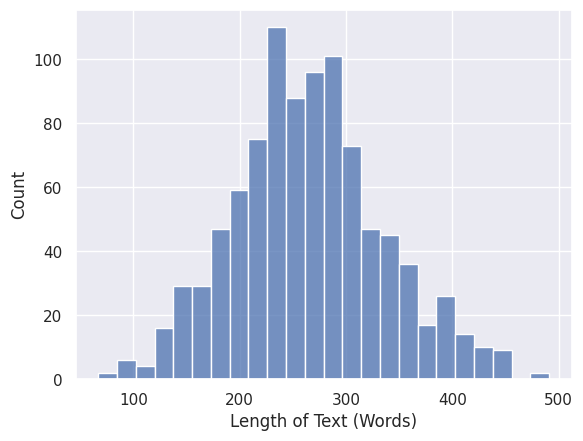

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
sns.histplot(df['formatted_prompt_with_answer'].apply(lambda x: len(x.split())))
plt.xlabel('Length of Text (Words)')
plt.ylabel('Count')

#### Что будет дальше
Прежде чем мы сможем приступить к фактическому обучению, нам необходимо выполнить токенизацию.
Ниже мы реализовали функцию `tokenize_and_mask`, которая принимает пакет промптов с ответами и без них и токенизирует их. Токенизация происходит с помощью применения `[-100]` — это стандартный подход в Hugging Face, позволяющий игнорировать токены во время минимизации целевой функции. Почему мы хотим игнорировать некоторые токены, если проводим полную настройку? Потому что нас не волнуют градиенты, проходящие через промпт. Нас интересуют только градиенты, проходящие через желаемый ответ, поэтому мы просто маскируем все токены, принадлежащие промпту.
Затем эта функция применяется к обоим наборам данных.

In [ ]:
max_length = int(MAX_LEN * BPE_FACTOR) # because of BPE

def tokenize_and_mask(batch):
    full_texts = batch["formatted_prompt_with_answer"]   # list of prompt + answer strings
    prompts    = batch["formatted_prompt_no_answer"]     # list of prompt-only strings

    tok_full = tokenizer(
        full_texts,
        truncation=True,
        max_length=max_length,
        return_attention_mask=True,
    )

    input_ids      = tok_full["input_ids"]
    attention_mask = tok_full["attention_mask"]

    labels = []
    for i, (seq_ids, prompt) in enumerate(zip(input_ids, prompts)):
        p_ids     = tokenizer(
            prompt,
            truncation=True,
            max_length=max_length
        )["input_ids"]
        prompt_len = len(p_ids)

        lab = seq_ids.copy()
        lab[:prompt_len] = [-100] * prompt_len
        labels.append(lab)
        all_100 = True
        for x in lab:
            if x!=-100:
                all_100 = False
                break
        if all_100:
            print(f'All tokens will be ignored for sequence #{i}')
            print(len(seq_ids))
            print('------')

    return {
        "input_ids":      input_ids,
        "attention_mask": attention_mask,
        "labels":         labels
    }

tokenized_datasets = datasets.map(
    tokenize_and_mask,
    batched=True,
)

Map:   0%|          | 0/846 [00:00<?, ? examples/s]

Map:   0%|          | 0/95 [00:00<?, ? examples/s]

Давайте проверим, есть ли у нас одинаковое соответствие между `input_ids` и `labels`

In [ ]:
ex = tokenized_datasets["train"][192]
print("input_ids[:20]:", ex["input_ids"][-20:])
print("labels   [:20]:", ex["labels"]   [-20:])

input_ids[:20]: [23, 18, 60, 2350, 23609, 266, 519, 323, 22008, 258, 4998, 1609, 320, 2828, 953, 8, 374, 1112, 151645, 198]
labels   [:20]: [23, 18, 60, 2350, 23609, 266, 519, 323, 22008, 258, 4998, 1609, 320, 2828, 953, 8, 374, 1112, 151645, 198]


Как мы видим, они совпадают, и это здорово. Однако внимательный читатель может сказать, что для того, чтобы точно настроить модель в контролируемом режиме, мы на самом деле хотим сдвинуть метки на один индекс вперед: предсказать $t_1$ из $t_0$. Это абсолютно правильно, и некоторые люди делают подмену при подготовке набора данных. Однако смену мы сделаем во время тренировки.
Подводя итог:
- Сдвиг вперед на один индекс для меток можно выполнить внутри набора данных на уровне данных (это то, что делают некоторые люди)
- Сдвиг вперед на один индекс для меток можно выполнить в рамках обучения, в этом случае `labels` отражает `input_ids` (это то, что мы делаем)

ПЕРЕД точной настройкой полезно проверить несколько прогнозов:

In [ ]:

sample_prompts = df['formatted_prompt_no_answer'].iloc[:5].tolist()
sample_gt = df['formatted_prompt_with_answer'].iloc[:5].tolist()
pretrain_outputs = []
print("=== Before fine-tuning ===")
for i, (p, gt) in enumerate(zip(sample_prompts, sample_gt)):
    print(f'Reference answer #{i}:')
    print(gt)
    print('-----------------------------------')
    print(f'Prediction #{i}:')
    inputs = tokenizer(p, truncation=True, max_length=max_length, return_attention_mask=True, return_tensors="pt").to(model.device)
    out_ids = model.generate(
        **inputs,
        max_new_tokens=128,
        do_sample=True
    )[0]
    prediction = tokenizer.decode(out_ids, skip_special_tokens=True)
    pretrain_outputs.append(prediction)
    print(prediction)
    print("-----------------------------------\n\n\n")

=== Before fine-tuning ===
Reference answer #0:
<|im_start|>user
Question: Is Alu hypomethylation associated with breast cancer?
Context: Document # 24971511:
The changes in DNA methylation status in cancer cells are characterized by hypermethylation of promoter CpG islands and diffuse genomic hypomethylation. Alu and long interspersed nucleotide element-1 (LINE-1) are non-coding genomic repetitive sequences and methylation of these elements can be used as a surrogate marker for genome-wide methylation status. This study was designed to evaluate the changes of Alu and LINE-1 hypomethylation during breast cancer progression from normal to pre-invasive lesions and invasive breast cancer (IBC), and their relationship with characteristics of IBC. We analyzed the methylation status of Alu and LINE-1 in 145 cases of breast samples including normal breast tissue, atypical ductal hyperplasia/flat epithelial atypia (ADH/FEA), ductal carcinoma in situ (DCIS) and IBC, and another set of 129 cases

In [ ]:
from IPython.display import HTML, display

table_template = """<table style="border:1px solid black; table-layout: fixed; width: 100%;" >
  <tr>
    <th style="text-align: center; border:1px solid black; width: 33%;">PREFIX</th>
    <th style="text-align: center; border:1px solid black; width: 33%;">PRETRAIN</th>
    <th style="text-align: center; border:1px solid black; width: 33%;">SFT</th>
  </tr>
{}
</table>"""

# Modified row_template for text wrapping and better alignment
row_template = '''  <tr>
    <td style="border:1px solid black; vertical-align:top;"><pre style="white-space: pre-wrap; word-wrap: break-word; text-align:left; margin: 0;">`{}`</pre></td>
    <td style="border:1px solid black; vertical-align:top;"><pre style="white-space: pre-wrap; word-wrap: break-word; text-align:left; margin: 0;">{}</pre></td>
    <td style="border:1px solid black; vertical-align:top;"><pre style="white-space: pre-wrap; word-wrap: break-word; text-align:left; margin: 0;">{}</pre></td>
  </tr>'''


rows = []

for i, prefix in enumerate(sample_prompts):
    prefix = prefix[0:512] + '...'
    rows.append(row_template.format(prefix, pretrain_outputs[i], None))

display(HTML(table_template.format('\n'.join(rows))))

PREFIX,PRETRAIN,SFT
`<|im_start|>user Question: Is Alu hypomethylation associated with breast cancer? Context: Document # 24971511: The changes in DNA methylation status in cancer cells are characterized by hypermethylation of promoter CpG islands and diffuse genomic hypomethylation. Alu and long interspersed nucleotide element-1 (LINE-1) are non-coding genomic repetitive sequences and methylation of these elements can be used as a surrogate marker for genome-wide methylation status. This study was designed to evaluate the chan...`,"user Question: Is Alu hypomethylation associated with breast cancer? Context: Document # 24971511: The changes in DNA methylation status in cancer cells are characterized by hypermethylation of promoter CpG islands and diffuse genomic hypomethylation. Alu and long interspersed nucleotide element-1 (LINE-1) are non-coding genomic repetitive sequences and methylation of these elements can be used as a surrogate marker for genome-wide methylation status. This study was designed to evaluate the changes of Alu and LINE-1 hypomethylation during breast cancer progression from normal to pre-invasive lesions and invasive breast cancer (IBC), and their relationship with characteristics of IBC. We analyzed the methylation status of Alu and LINE-1 in 145 cases of breast samples including normal breast tissue, atypical ductal hyperplasia/flat epithelial atypia (ADH/FEA), ductal carcinoma in situ (DCIS) and IBC, and another set of 129 cases of IBC by pyrosequencing. Alu methylation showed no significant changes during multistep progression of breast cancer, although it tended to decrease during the transition from DCIS to IBC. In contrast, LINE-1 methylation significantly decreased from normal to ADH/FEA, while it was similar in ADH/FEA, DCIS and IBC. In IBC, Alu hypomethylation correlated with negative estrogen receptor (ER) status, and LINE-1 hypomethylation was associated with negative ER status, ERBB2 (HER2) amplification and p53 overexpression. Alu and LINE-1 methylation status was significantly different between breast cancer subtypes, and the HER2 enriched subtype had lowest methylation levels. In survival analyses, low Alu methylation status tended to be associated with poor disease-free survival of the patients. Our findings suggest that LINE-1 hypomethylation is an early event and Alu hypomethylation is probably a late event during breast cancer progression, and prominent hypomethylation of Alu and LINE-1 in HER2 enriched subtype may be related to chromosomal instability of this specific subtype. assistant Yes, **Alu hypomethylation is associated with breast cancer**, particularly in subtypes like **HER2-enriched breast cancer (IBC)**. Here's a summary of the findings: - **Alu hypomethylation** was **not significantly different** during the progression of breast cancer, but it **tended to decrease** during the transition from **DCIS to IBC**. - **LINE-1 hypomethylation** **significantly decreased** from normal to ADH/FEA, and was **similar** in ADH/FEA, DCIS, and IBC. - In **",None
"`<|im_start|>user Question: Which factors activate zygotic gene expression during the maternal-to-zygotic transition in zebrafish? Context: Document # 24056933: After fertilization, maternal factors direct development and trigger zygotic genome activation (ZGA) at the maternal-to-zygotic transition (MZT). In zebrafish, ZGA is required for gastrulation and clearance of maternal messenger RNAs, which is in part regulated by the conserved microRNA miR-430. However, the factors that activate the zygotic program ...`","user Question: Which factors activate zygotic gene expression during the maternal-to-zygotic transition in zebrafish? Context: Document # 24056933: After fertilization, maternal factors direct development and trigger zygotic genome activation (ZGA) at the maternal-to-zygotic transition (MZT). In zebrafish, ZGA is required for gastrulation and clearance of maternal messenger RNAs, which is in part regulated by the 

### Последние приготовления
Как мы уже говорили выше, сдвиг вперед между `input_ids` и `labels` произойдет во время функции обучения, а не внутри функции сопоставления. К счастью для нас, HuggingFace реализовал этот сдвиг в Trainer API. Некоторым людям нравится выполнять сдвиг на этапе сопоставления, в этом случае вы можете использовать `DataCollatorForLanguageModeling`, однако мы будем использовать `DataCollatorWithPadding`, который просто выполняет удобное дополнение.
Если вам интересно, зачем нам нужны дополнения в пакете текста: графические процессоры могут работать только с тензорами идеальной формы. Если имеется пакет из 32 строк, каждая строка должна иметь одинаковое количество значений. Если некоторые тексты длиннее других, нам нужно дополнить более короткие тексты или обрезать более длинные.
Кроме того, во время сопоставления мы маскируем токены заполнения с помощью `-100` так же, как мы маскировали токены промпта.

In [ ]:
import torch
from transformers import DataCollatorWithPadding, PreTrainedTokenizerBase
from typing import List, Dict, Any

class SFTDataCollator(DataCollatorWithPadding):
    """
    Extends HF's DataCollatorWithPadding so that it ALSO pads 'labels'
    (which by default would be ignored and left at their original lengths).
    """
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        labels = [f.pop("labels") for f in features]

        batch = super().__call__(features)

        batch_size, seq_len = batch["input_ids"].shape
        padded_labels = torch.full(
            (batch_size, seq_len),
            fill_value=-100,
            dtype=torch.long,
            device=batch["input_ids"].device
        )
        for i, lab in enumerate(labels):
            length = len(lab)
            if length > seq_len:
                lab = lab[:seq_len]
                length = seq_len
            padded_labels[i, :length] = torch.tensor(lab, dtype=torch.long)

        batch["labels"] = padded_labels
        return batch


#### Давайте запустим!
Теперь у нас все готово и мы наконец можем запустить код настройки funetuning.
Если вы захотите позже поэкспериментировать с параметрами для точной настройки основного цикла, вот несколько рекомендаций:
- Learning_rate: самый важный параметр. Обычно устанавливается значение `1e-5`, но на самом деле это зависит от этапа обучения.
- Weight_decay: это коэффициент регуляризации, применяемый к весам. Если вы исходите из классического машинного обучения, подумайте об этом как о коэффициенте регуляризации `l2`.
- fp16 - это означает, что мы используем число с плавающей запятой 16 с 5 битами для экспоненты и 10 для мантиссы.
- bf16 - это значит, что мы используем 8 бит для экспоненты и 7 для мантиссы. **Этот вариант более предпочтителен при глубоком обучении!** Мы вообще не используем половинную точность

In [ ]:
from transformers import DataCollatorWithPadding

training_args = TrainingArguments(
    output_dir="./qwen3-sft",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="steps",
    eval_steps=100,
    logging_steps=100,
    save_steps=100,
    save_total_limit=2,
    fp16=False,
    bf16=False,
    push_to_hub=False
)

data_collator = SFTDataCollator(
    tokenizer,
    padding="longest",
    return_tensors="pt"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer
)

/tmp/ipython-input-48-1171261345.py:26: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Давайте подтвердим, что наш загрузчик данных дает нам действительно правильные результаты, наши `labels` и `input_ids` должны совпадать, потому что мы не делаем никаких сдвигов в части данных.

In [ ]:
# 1. Grab one batch
batch = next(iter(trainer.get_eval_dataloader()))

# 2. For the first example in that batch, find all positions not masked
labels = batch["labels"][0]
valid_idxs = (labels != -100).nonzero(as_tuple=True)[0].tolist()

print("Batch seq_len:", labels.shape[0])
print("Valid token count:", len(valid_idxs))
print("First valid index:", valid_idxs[0])
print("Last  valid index:", valid_idxs[-1])

# 3. Show a little window around the start and end of your answer
start = valid_idxs[0]
end   = valid_idxs[-1]
print("→ input_ids around start:",
      batch["input_ids"][0, start : start+10].tolist())
print("→ labels    around start:",
      labels[start : start+10].tolist())
print("→ input_ids around end:",
      batch["input_ids"][0, end-9 : end+1].tolist())
print("→ labels    around end:",
      labels[end-9 : end+1].tolist())


Batch seq_len: 619
Valid token count: 137
First valid index: 482
Last  valid index: 618
→ input_ids around start: [2740, 41410, 33865, 374, 264, 6733, 369, 32359, 92759, 2805]
→ labels    around start: [2740, 41410, 33865, 374, 264, 6733, 369, 32359, 92759, 2805]
→ input_ids around end: [25, 362, 6884, 8045, 315, 2805, 28806, 1112, 151645, 198]
→ labels    around end: [25, 362, 6884, 8045, 315, 2805, 28806, 1112, 151645, 198]


In [ ]:
tokenizer.decode([151643, 151645])

'<|endoftext|><|im_end|>'

Text(0, 0.5, 'Count')

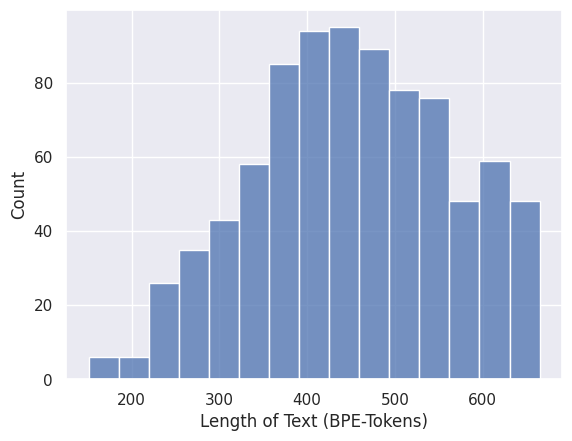

In [ ]:
sns.histplot([len(x['labels']) for x in tokenized_datasets['train']])
plt.xlabel('Length of Text (BPE-Tokens)')
plt.ylabel('Count')

Давайте проведем предварительную оценку SFT, чтобы убедиться, что потеря не NAN и все работает сквозно:

In [ ]:
metrics = trainer.evaluate()
print(metrics)

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mishacamry to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


{'eval_loss': 1.5665117502212524, 'eval_model_preparation_time': 0.0081, 'eval_runtime': 19.0762, 'eval_samples_per_second': 4.98, 'eval_steps_per_second': 4.98}


# Тонкая настройка и последствия
Цикл обучения:

In [ ]:
trainer.train()

Step,Training Loss,Validation Loss,Model Preparation Time
100,0.676500,0.523372,0.008100
200,0.538000,0.516137,0.008100
300,0.543300,0.492658,0.008100
400,0.779400,0.474537,0.008100
500,0.487500,0.473438,0.008100
600,0.483800,0.455958,0.008100
700,0.525600,0.444625,0.008100
800,0.553700,0.435374,0.008100


TrainOutput(global_step=846, training_loss=0.569864933654208, metrics={'train_runtime': 2440.8672, 'train_samples_per_second': 0.347, 'train_steps_per_second': 0.347, 'total_flos': 1009865902915584.0, 'train_loss': 0.569864933654208, 'epoch': 1.0})

Давайте проверим метрики после SFT, чтобы убедиться, что потери уменьшились.
Однако фактическая оценка должна происходить вручную, когда мы смотрим на результаты и подтверждаем, что модель действительно генерирует цитирования.

In [ ]:
metrics = trainer.evaluate()
print(metrics)

{'eval_loss': 0.43468138575553894, 'eval_model_preparation_time': 0.0081, 'eval_runtime': 20.1315, 'eval_samples_per_second': 4.719, 'eval_steps_per_second': 4.719, 'epoch': 1.0}


Показатель глазного яблока здесь:

In [ ]:
# Show a few predictions AFTER fine-tuning
posttrain_outputs = []
print("=== After fine-tuning ===")
for i, (p, gt) in enumerate(zip(sample_prompts, sample_gt)):
    print(f'Reference answer #{i}:')
    print(gt)
    print('-----------------------------------')
    print(f'Prediction #{i}:')
    inputs = tokenizer(p, truncation=True, max_length=max_length, return_attention_mask=True, return_tensors="pt").to(model.device)
    out_ids = model.generate(
        **inputs,
        max_new_tokens=128,
        do_sample=True
    )[0]
    prediction = tokenizer.decode(out_ids, skip_special_tokens=True)
    posttrain_outputs.append(prediction)
    print(prediction)
    print("-----------------------------------\n\n\n")

=== After fine-tuning ===
Reference answer #0:
<|im_start|>user
Question: Is Alu hypomethylation associated with breast cancer?
Context: Document # 24971511:
The changes in DNA methylation status in cancer cells are characterized by hypermethylation of promoter CpG islands and diffuse genomic hypomethylation. Alu and long interspersed nucleotide element-1 (LINE-1) are non-coding genomic repetitive sequences and methylation of these elements can be used as a surrogate marker for genome-wide methylation status. This study was designed to evaluate the changes of Alu and LINE-1 hypomethylation during breast cancer progression from normal to pre-invasive lesions and invasive breast cancer (IBC), and their relationship with characteristics of IBC. We analyzed the methylation status of Alu and LINE-1 in 145 cases of breast samples including normal breast tissue, atypical ductal hyperplasia/flat epithelial atypia (ADH/FEA), ductal carcinoma in situ (DCIS) and IBC, and another set of 129 cases 

In [ ]:
rows = []

for i, prefix in enumerate(sample_prompts):
    prefix = prefix[0:512] + '...'
    rows.append(row_template.format(prefix, pretrain_outputs[i], posttrain_outputs[i]))

display(HTML(table_template.format('\n'.join(rows))))

PREFIX,PRETRAIN,SFT
`<|im_start|>user Question: Is Alu hypomethylation associated with breast cancer? Context: Document # 24971511: The changes in DNA methylation status in cancer cells are characterized by hypermethylation of promoter CpG islands and diffuse genomic hypomethylation. Alu and long interspersed nucleotide element-1 (LINE-1) are non-coding genomic repetitive sequences and methylation of these elements can be used as a surrogate marker for genome-wide methylation status. This study was designed to evaluate the chan...`,"user Question: Is Alu hypomethylation associated with breast cancer? Context: Document # 24971511: The changes in DNA methylation status in cancer cells are characterized by hypermethylation of promoter CpG islands and diffuse genomic hypomethylation. Alu and long interspersed nucleotide element-1 (LINE-1) are non-coding genomic repetitive sequences and methylation of these elements can be used as a surrogate marker for genome-wide methylation status. This study was designed to evaluate the changes of Alu and LINE-1 hypomethylation during breast cancer progression from normal to pre-invasive lesions and invasive breast cancer (IBC), and their relationship with characteristics of IBC. We analyzed the methylation status of Alu and LINE-1 in 145 cases of breast samples including normal breast tissue, atypical ductal hyperplasia/flat epithelial atypia (ADH/FEA), ductal carcinoma in situ (DCIS) and IBC, and another set of 129 cases of IBC by pyrosequencing. Alu methylation showed no significant changes during multistep progression of breast cancer, although it tended to decrease during the transition from DCIS to IBC. In contrast, LINE-1 methylation significantly decreased from normal to ADH/FEA, while it was similar in ADH/FEA, DCIS and IBC. In IBC, Alu hypomethylation correlated with negative estrogen receptor (ER) status, and LINE-1 hypomethylation was associated with negative ER status, ERBB2 (HER2) amplification and p53 overexpression. Alu and LINE-1 methylation status was significantly different between breast cancer subtypes, and the HER2 enriched subtype had lowest methylation levels. In survival analyses, low Alu methylation status tended to be associated with poor disease-free survival of the patients. Our findings suggest that LINE-1 hypomethylation is an early event and Alu hypomethylation is probably a late event during breast cancer progression, and prominent hypomethylation of Alu and LINE-1 in HER2 enriched subtype may be related to chromosomal instability of this specific subtype. assistant Yes, **Alu hypomethylation is associated with breast cancer**, particularly in subtypes like **HER2-enriched breast cancer (IBC)**. Here's a summary of the findings: - **Alu hypomethylation** was **not significantly different** during the progression of breast cancer, but it **tended to decrease** during the transition from **DCIS to IBC**. - **LINE-1 hypomethylation** **significantly decreased** from normal to ADH/FEA, and was **similar** in ADH/FEA, DCIS, and IBC. - In **","user Question: Is Alu hypomethylation associated with breast cancer? Context: Document # 24971511: The changes in DNA methylation status in cancer cells are characterized by hypermethylation of promoter CpG islands and diffuse genomic hypomethylation. Alu and long interspersed nucleotide element-1 (LINE-1) are non-coding genomic repetitive sequences and methylation of these elements can be used as a surrogate marker for genome-wide methylation status. This study was designed to evaluate the changes of Alu and LINE-1 hypomethylation during breast cancer progression from normal to pre-invasive lesions and invasive breast cancer (IBC), and their relationship with characteristics of IBC. We analyzed the methylation status of Alu and LINE-1 in 145 cases of breast samples including normal breast tissue, atypical ductal hyperplasia/flat epithelial atypia (ADH/FEA), ductal carcinoma in situ (DCIS) and IBC, and another set of 129 cases o

И действительно, теперь у нас есть ссылки в ответах!

### Заключение
Мы видим, что выходные данные SFT действительно содержат цитаты, и наша модель научилась всегда выводить раздел `References` в конце и предоставлять соответствующую информацию, которая использовалась для вопросов-ответов.
Напоминаем: здесь мы использовали **полную точную настройку**.
Дополнительные методы смотрите в следующих блокнотах!